In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import glob
import pickle
from collections import defaultdict
from pprint import pprint

## Spaceinvaders

In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import glob
import pickle

from pprint import pprint

def collect_npz_files(base_dir, sub_num, game_num):
    # 예: base_dir = 'behavioral_data_4kframe_legacy'
    target_dir = os.path.join(base_dir, f"sub_{sub_num}", f"game_{game_num}")
    npz_files = []
    # day_*, block_* 하위의 모든 npz 파일 찾기
    for day in os.listdir(target_dir):
        day_path = os.path.join(target_dir, day)
        if os.path.isdir(day_path) and day.startswith("day_"):
            for block in os.listdir(day_path):
                block_path = os.path.join(day_path, block)
                if os.path.isdir(block_path) and block.startswith("block_"):
                    npz_files.extend(glob.glob(os.path.join(block_path, "*.npz")))
    return npz_files

# 사용 예시
base_dir = "behavioral_data_4kframe_legacy"
sub_num = 1
game_num = 1
npz_list = collect_npz_files(base_dir, sub_num, game_num)
all_data = []
for npz_path in npz_list:
    data = np.load(npz_path)
    all_data.append({key: data[key] for key in data.files})

In [ ]:
action_mapping = {
    'NOOP': 0,
    'FIRE': 1,
    'RIGHT': 2,
    'LEFT': 3,
    'RIGHTFIRE': 4,
    'LEFTFIRE': 5,
}
all_possible_actions = np.arange(len(action_mapping))  # [0, 1, 2, 3, 4, 5]

def plot_action_distribution(npz_list, num_splits=5):
    # 1. Find the maximum length among all npz files
    max_length = 0
    all_actions = []
    for npz_path in npz_list:
        data = np.load(npz_path)
        actions = data['action']  # shape: (T, num_actions)
        all_actions.append(actions)
        if len(actions) > max_length:
            max_length = len(actions)

    # 2. Define global split indices based on the maximum length
    split_indices = np.linspace(0, max_length, num_splits+1, dtype=int)

    # 3. For each segment, gather all actions from all files, then compute proportion
    segment_ratios = []
    for i in range(num_splits):
        start, end = split_indices[i], split_indices[i+1]
        segment_actions = []
        for actions in all_actions:
            if len(actions) > start:
                seg = actions[start:min(end, len(actions))]
                if len(seg) > 0:
                    segment_actions.append(seg)
        if segment_actions:
            segment_actions = np.concatenate(segment_actions, axis=0)  # shape: (total_steps, num_actions)
            action_counts = segment_actions.sum(axis=0)
            if action_counts.sum() > 0:
                ratio = action_counts / action_counts.sum()
            else:
                ratio = np.zeros(len(action_mapping))
        else:
            ratio = np.zeros(len(action_mapping))
        segment_ratios.append(ratio)

    segment_ratios = np.array(segment_ratios)  # (num_splits, num_actions)

    # Plot: segment별 subplot
    plt.figure(figsize=(4 * num_splits, 5))
    for i in range(num_splits):
        plt.subplot(1, num_splits, i+1)
        plt.bar(
            all_possible_actions,
            segment_ratios[i],
            color='blue',
            width=0.3,
            edgecolor='black'
        )
        plt.title(f"Segment {i+1}")
        plt.xlabel("Action")
        plt.ylabel("Proportion")
        plt.ylim(0, 1)
        plt.xticks(all_possible_actions, list(action_mapping.keys()), rotation=45)
    plt.tight_layout()
    plt.suptitle("Action Proportion per Time Segment", y=1.02, fontsize=16)
    plt.show()
plot_action_distribution(npz_list, num_splits=5)

In [2]:
file_dir = 'spaceinvaderscheckpoint/spaceinvaders_10e6_2.npy'
file_dir = 'thinker-20250806-002733-4000032-0/video_stat.npy'
#file_dir = 'thinker-20251023-165530-327280-0/video_stat.npy'
#file_dir = 'test/spaceinvaders_4e6_1.npy'
data_dir = os.path.join('./test', file_dir)
data = (np.load(data_dir, allow_pickle=True)).item()
print('data.keys():', data.keys())
print('real image data length:', len(data['real_imgs']))
print('imagination image data length:', len(data['im_imgs']))

data.keys(): dict_keys(['real_imgs', 'im_imgs', 'status', 'tree_reps', 'cur_rewards', 'step_times', 'real_vectors', 'im_vectors', 'im_vp_vectors'])
real image data length: 42380
imagination image data length: 42380


computation time 확인용

In [7]:
print(data['step_times'])

None


score 확인용 코드

In [10]:
status = np.asarray(data['status'])                     # 리스트 → ndarray
imgs   = np.asarray(data['real_imgs'])     # 이미지 배열
idx0 = np.where(status == 0)[0]
last_idx = idx0[-150]

마지막 status==0 index: 48256


/home/jmme425/miniconda3/envs/thinker/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jmme425/miniconda3/envs/thinker/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jmme425/miniconda3/envs/thinker/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


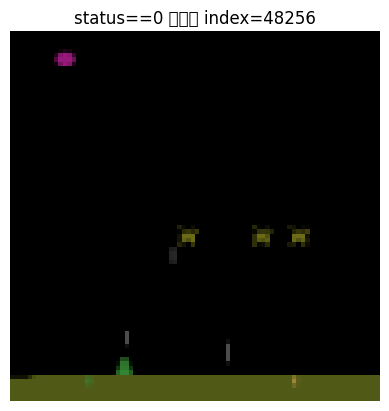

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1) status == 0인 인덱스 모두 찾기

if idx0.size > 0:  # 가장 마지막 index
    print("마지막 status==0 index:", last_idx)

    # 2) 이미지 가져오기
    img = imgs[last_idx]

    # 3) 출력 (채널 차원 여부 확인)
    if img.ndim == 3 and img.shape[0] in (1,3):  # (C,H,W) 형식일 가능성
        img = np.transpose(img, (1,2,0))         # → (H,W,C)
    elif img.ndim == 3 and img.shape[-1] in (1,3):
        pass  # 이미 (H,W,C) 형식일 수도 있음

    plt.imshow(img.squeeze(), cmap="gray" if img.ndim==2 or img.shape[-1]==1 else None)
    plt.title(f"status==0 마지막 index={last_idx}")
    plt.axis("off")
    plt.show()

else:
    print("status==0인 항목이 없습니다.")

In [18]:
# data['status']에서 각 값의 개수 계산
status_values = [0, 1, 2, 3]  # 계산하려는 status 값들
status_counts = {}

for value in status_values:
    # 해당 값을 가진 인덱스의 개수 계산
    count = np.sum(np.array(data['status']) == value)
    status_counts[value] = count

# 결과 출력
for value, count in status_counts.items():
    status_name = {
        0: "실제 스텝(real step)",
        1: "리셋(reset)",
        2: "상상 스텝(imaginary step)",
        3: "강제 리셋(force reset)"
    }.get(value, "알 수 없음")
    
    print(f"Status {value} ({status_name}): {count}개")

# 특정 값(예: 0)을 가진 인덱스 목록 구하기
indices_with_value_1 = np.where(np.array(data['status']) == 1)[0]
print(f"\nStatus 1을 가진 인덱스의 개수: {len(indices_with_value_1)}")

Status 0 (실제 스텝(real step)): 987개
Status 1 (리셋(reset)): 4217개
Status 2 (상상 스텝(imaginary step)): 38454개
Status 3 (강제 리셋(force reset)): 912개

Status 1을 가진 인덱스의 개수: 4217


In [32]:
def analyze_status_data(status_data):
    """
    status 데이터를 분석하여 real step과 imaginary step을 구분하고
    각 real step마다의 planning depth를 계산합니다.
    
    새로운 방식: 0부터 다음 0까지를 하나의 stage로 간주하되,
    그 사이에 1,3이 있으면 끊어서 계산하고, 각 구간의 길이들의 평균을 planning depth로 사용합니다.
    
    Args:
        status_data: status 값들의 배열 (0, 1, 2, 3 중 하나의 값)
    
    Returns:
        real_indices: real step의 인덱스들
        planning_depths: 각 real step마다의 planning depth 값 (평균값)
        reset_info: 리셋 정보 (각 imagination 구간에서 리셋이 발생한 위치)
    """
    real_indices = []
    planning_depths = []  # 각 real step마다의 planning depth 값 (평균값)
    reset_info = []
    
    i = 0
    while i < len(status_data):
        # status가 0인 real step 찾기
        if status_data[i] == 0:
            real_indices.append(i)
            
            # 다음 real step(status=0)까지의 imagination 구간 찾기
            imagination_start = i + 1
            imagination_end = len(status_data)  # 기본값: 끝까지
            
            # 다음 real step 찾기
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break
            
            # imagination 구간에서의 planning depth 계산 (새로운 방식)
            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                
                # 1과 3을 만나면 끊어서 각 구간의 길이 계산
                segment_lengths = []
                current_length = 0
                reset_positions = []
                
                for k, status_val in enumerate(imagination_segment):
                    if status_val in [1, 3]:  # 리셋 발생 (1 또는 3)
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:  # 상상 스텝 (2)
                        current_length += 1
                    # status_val == 0인 경우는 이미 처리됨
                
                # 마지막 구간 추가
                if current_length > 0:
                    segment_lengths.append(current_length)
                
                # planning depth는 각 구간의 길이들의 평균
                if segment_lengths:
                    avg_planning_depth = np.mean(segment_lengths)
                else:
                    avg_planning_depth = 0.0
                
                planning_depths.append(avg_planning_depth)
                
                reset_info.append({
                    'reset_positions': reset_positions,
                    'segment_lengths': segment_lengths,
                    'total_length': sum(segment_lengths),
                    'avg_planning_depth': avg_planning_depth
                })
            else:
                planning_depths.append(0.0)
                reset_info.append({
                    'reset_positions': [],
                    'segment_lengths': [],
                    'total_length': 0,
                    'avg_planning_depth': 0.0
                })
            
            i = imagination_end
        else:
            i += 1
    
    return real_indices, planning_depths, reset_info

# 데이터 로드 및 분석
status_data = data['status']
real_indices, imagination_lengths, reset_info = analyze_status_data(status_data)

In [33]:
def analyze_noop_planning_relationship(data, window_size=10, stride=2):
    """
    Sliding window를 사용하여 NOOP action 빈도와 planning depth의 관계를 분석합니다.
    status가 0인 real step 데이터만 분석 대상으로 합니다.
    
    Args:
        data: 로드된 데이터 딕셔너리
        window_size: sliding window 크기 (real step 기준)
        stride: sliding 간격 (real step 기준)
    
    Returns:
        window_results: 각 윈도우별 분석 결과
    """
    status_data = data['status']
    total_length = len(status_data)
    
    # status 데이터 분석 (planning depth 계산용) - 새로운 방식 사용
    real_indices, planning_depths, reset_info = analyze_status_data(status_data)
    
    # NOOP action 추출 (one-hot encoding 처리)
    noop_actions = []
    for idx in range(total_length):
        if idx < len(data['tree_reps']['cur_action']):
            action_onehot = data['tree_reps']['cur_action'][idx]
            action_idx = np.argmax(action_onehot)
            noop_actions.append(action_idx)
        else:
            noop_actions.append(-1)  # 데이터가 없는 경우
    
    noop_actions = np.array(noop_actions)
    
    # status가 0인 real step에서만 NOOP action 추출
    real_step_noop_actions = []
    for idx in real_indices:
        if idx < len(noop_actions):
            real_step_noop_actions.append(noop_actions[idx])
        else:
            real_step_noop_actions.append(-1)
    
    real_step_noop_actions = np.array(real_step_noop_actions)
    
    window_results = []
    
    # Real step 기준으로 sliding window 분석
    for start_idx in range(0, len(real_indices) - window_size + 1, stride):
        end_idx = start_idx + window_size
        
        # 현재 윈도우의 real step 인덱스들
        window_real_indices = real_indices[start_idx:end_idx]
        window_noop_actions = real_step_noop_actions[start_idx:end_idx]
        window_planning_depths = planning_depths[start_idx:end_idx]
        
        # 1. NOOP action 분석 (real step에서만)
        noop_count = np.sum(window_noop_actions == 0)  # NOOP = 0
        noop_frequency = noop_count / window_size
        
        # 2. Planning depth 분석 - 윈도우 내 모든 real step의 planning depth 평균
        avg_planning_depth = np.mean(window_planning_depths)
        
        # 3. 결과 저장
        window_result = {
            'window_start': start_idx,
            'window_end': end_idx,
            'real_step_indices': window_real_indices,
            'noop_count': noop_count,
            'noop_frequency': noop_frequency,
            'avg_planning_depth': avg_planning_depth,
            'planning_depths': window_planning_depths,
            'noop_actions': window_noop_actions
        }
        
        window_results.append(window_result)
    
    return window_results

# 데이터 로드 및 분석
status_data = data['status']
real_indices, planning_depths, reset_info = analyze_status_data(status_data)

print(f"총 데이터 길이: {len(status_data)}")
print(f"Real step 개수: {len(real_indices)}")

if planning_depths:
    print(f"Planning Depth 통계 (각 real step별 평균값):")
    print(f"  - 평균: {np.mean(planning_depths):.2f}")
    print(f"  - 중앙값: {np.median(planning_depths):.2f}")
    print(f"  - 최대값: {np.max(planning_depths):.2f}")
    print(f"  - 최소값: {np.min(planning_depths):.2f}")
    print(f"  - 표준편차: {np.std(planning_depths):.2f}")
else:
    print("Planning depth 데이터가 없습니다.")

# 각 real step마다의 구간 수 통계
segment_counts = [len(info['segment_lengths']) for info in reset_info]
print(f"\n각 real step마다의 구간 수 통계:")
print(f"  - 평균: {np.mean(segment_counts):.2f}")
print(f"  - 중앙값: {np.median(segment_counts):.2f}")
print(f"  - 최대값: {np.max(segment_counts)}")
print(f"  - 최소값: {np.min(segment_counts)}")
print(f"  - 표준편차: {np.std(segment_counts):.2f}")

# 예시 출력 (처음 몇 개 real step의 planning depth)
print(f"\n=== 예시: 처음 5개 real step의 planning depth ===")
for i in range(min(5, len(planning_depths))):
    print(f"Real step {i+1} (인덱스 {real_indices[i]}): "
          f"Planning Depth = {planning_depths[i]:.2f}, "
          f"구간들 = {reset_info[i]['segment_lengths']}")

총 데이터 길이: 35057
Real step 개수: 742
Planning Depth 통계 (각 real step별 평균값):
  - 평균: 11.70
  - 중앙값: 6.50
  - 최대값: 39.00
  - 최소값: 0.00
  - 표준편차: 11.68

각 real step마다의 구간 수 통계:
  - 평균: 6.91
  - 중앙값: 6.00
  - 최대값: 35
  - 최소값: 0
  - 표준편차: 5.27

=== 예시: 처음 5개 real step의 planning depth ===
Real step 1 (인덱스 0): Planning Depth = 3.90, 구간들 = [10, 11, 1, 9, 1, 1, 1, 2, 2, 1]
Real step 2 (인덱스 50): Planning Depth = 3.25, 구간들 = [10, 5, 1, 6, 5, 1, 1, 5, 1, 1, 2, 1]
Real step 3 (인덱스 103): Planning Depth = 4.33, 구간들 = [8, 9, 8, 1, 4, 3, 4, 1, 1]
Real step 4 (인덱스 153): Planning Depth = 5.57, 구간들 = [14, 6, 6, 1, 9, 1, 2]
Real step 5 (인덱스 201): Planning Depth = 4.33, 구간들 = [10, 11, 3, 9, 1, 2, 1, 1, 1]


Sliding window 분석 시작... (Real Steps Only)
Window size: 160 real steps, Stride: 2 real steps


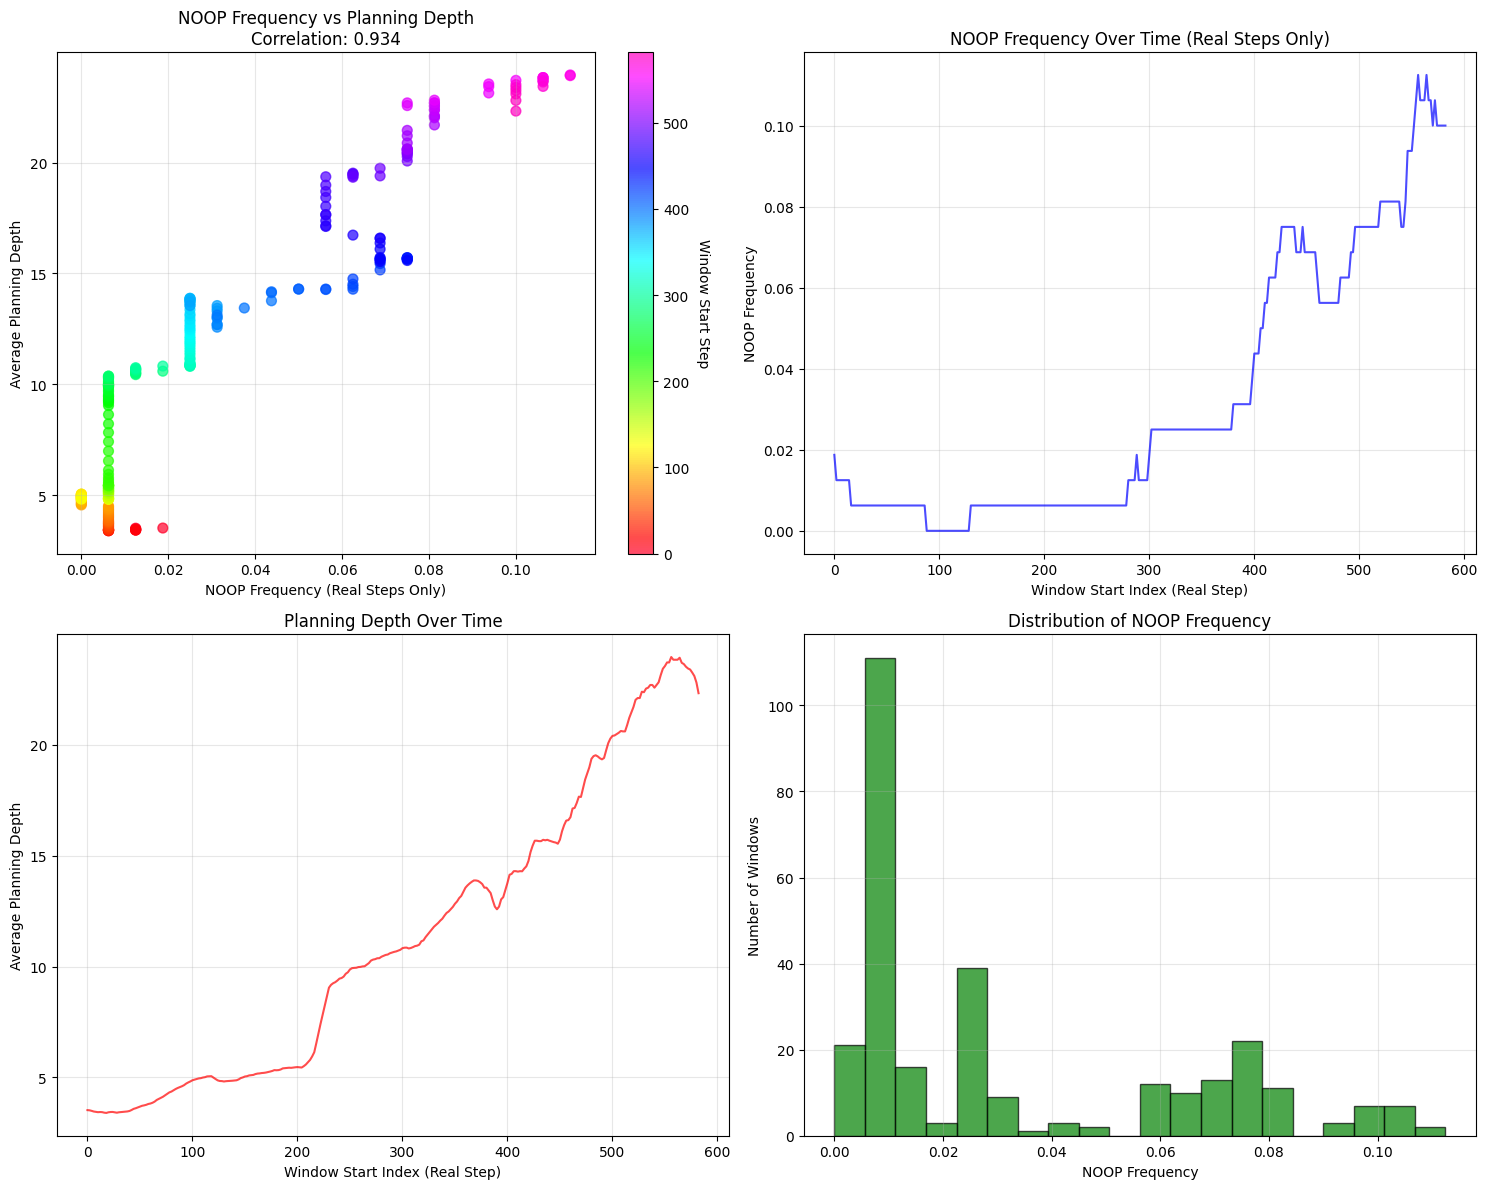

=== NOOP-Planning Depth Relationship Analysis (Real Steps Only) ===
Total windows analyzed: 292
Correlation coefficient: 0.934
Average NOOP frequency: 0.031
Average planning depth: 11.276
Standard deviation of NOOP frequency: 0.032
Standard deviation of planning depth: 6.457
Relationship strength: 매우 강함
Positive correlation: NOOP 빈도가 높을수록 planning depth도 높음


In [34]:
def plot_noop_planning_relationship(window_results):
    """
    NOOP 빈도와 planning depth의 관계를 시각화합니다.
    """
    # 데이터 추출
    noop_frequencies = [result['noop_frequency'] for result in window_results]
    planning_depths = [result['avg_planning_depth'] for result in window_results]
    window_starts = [result['window_start'] for result in window_results]
    
    # 상관관계 계산
    correlation = np.corrcoef(noop_frequencies, planning_depths)[0, 1]
    
    # 그래프 그리기
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Scatter plot: NOOP 빈도 vs Planning Depth (스텝 수에 따른 색상)
    scatter = axes[0, 0].scatter(noop_frequencies, planning_depths, c=window_starts, 
                                cmap='gist_rainbow', alpha=0.7, s=50)
    axes[0, 0].set_xlabel('NOOP Frequency (Real Steps Only)')
    axes[0, 0].set_ylabel('Average Planning Depth')
    axes[0, 0].set_title(f'NOOP Frequency vs Planning Depth\nCorrelation: {correlation:.3f}')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Colorbar 추가
    cbar = plt.colorbar(scatter, ax=axes[0, 0])
    cbar.set_label('Window Start Step', rotation=270, labelpad=15)
    
    # 2. Time series: NOOP 빈도 변화
    axes[0, 1].plot(window_starts, noop_frequencies, 'b-', alpha=0.7)
    axes[0, 1].set_xlabel('Window Start Index (Real Step)')
    axes[0, 1].set_ylabel('NOOP Frequency')
    axes[0, 1].set_title('NOOP Frequency Over Time (Real Steps Only)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Time series: Planning Depth 변화
    axes[1, 0].plot(window_starts, planning_depths, 'r-', alpha=0.7)
    axes[1, 0].set_xlabel('Window Start Index (Real Step)')
    axes[1, 0].set_ylabel('Average Planning Depth')
    axes[1, 0].set_title('Planning Depth Over Time')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. NOOP 빈도 분포
    axes[1, 1].hist(noop_frequencies, bins=20, alpha=0.7, color='green', edgecolor='black')
    axes[1, 1].set_xlabel('NOOP Frequency')
    axes[1, 1].set_ylabel('Number of Windows')
    axes[1, 1].set_title('Distribution of NOOP Frequency')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 통계 정보 출력
    print(f"=== NOOP-Planning Depth Relationship Analysis (Real Steps Only) ===")
    print(f"Total windows analyzed: {len(window_results)}")
    print(f"Correlation coefficient: {correlation:.3f}")
    print(f"Average NOOP frequency: {np.mean(noop_frequencies):.3f}")
    print(f"Average planning depth: {np.mean(planning_depths):.3f}")
    print(f"Standard deviation of NOOP frequency: {np.std(noop_frequencies):.3f}")
    print(f"Standard deviation of planning depth: {np.std(planning_depths):.3f}")
    
    # 상관관계 해석
    if abs(correlation) < 0.1:
        relationship = "거의 없음"
    elif abs(correlation) < 0.3:
        relationship = "약함"
    elif abs(correlation) < 0.5:
        relationship = "보통"
    elif abs(correlation) < 0.7:
        relationship = "강함"
    else:
        relationship = "매우 강함"
    
    print(f"Relationship strength: {relationship}")
    
    if correlation > 0:
        print("Positive correlation: NOOP 빈도가 높을수록 planning depth도 높음")
    elif correlation < 0:
        print("Negative correlation: NOOP 빈도가 높을수록 planning depth는 낮음")
    else:
        print("No correlation: NOOP 빈도와 planning depth 간 관계 없음")

# 분석 실행
window_size = 160
stride = 2

print(f"Sliding window 분석 시작... (Real Steps Only)")
print(f"Window size: {window_size} real steps, Stride: {stride} real steps")

window_results = analyze_noop_planning_relationship(data, window_size, stride)
plot_noop_planning_relationship(window_results)

=== Planning Depth 비교 분석 ===
총 real step 개수: 1119
NOOP action 개수: 2 (0.2%)
Non-NOOP action 개수: 1117 (99.8%)

=== Planning Depth 통계 ===
NOOP 평균: 4.88 ± 4.88
Non-NOOP 평균: 5.47 ± 3.61
차이: -0.60

=== 정규성 검정 (Shapiro-Wilk) ===
NOOP p-value: nan (정규분포 아님)
Non-NOOP p-value: 0.0000 (정규분포 아님)
등분산성 검정 (Levene) p-value: 0.1584 (등분산)

=== 유의성 검정 결과 ===
Parametric test 조건 불만족 (정규분포 아님 또는 이분산)
Mann-Whitney U test: p = 0.921753
Kolmogorov-Smirnov test: p = 0.502233
Permutation test 계산 중... (시간이 걸릴 수 있습니다)


/tmp/ipykernel_2149828/4244374977.py:67: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, noop_p_norm = stats.shapiro(noop_planning_depths)


Permutation test: p = 0.657600

=== 최종 결과 ===
선택된 검정: Permutation test
p-value: 0.657600
유의수준: p >= 0.05
결과: 유의한 차이 없음
Cohen's d: -0.165
효과 크기: 작음


/tmp/ipykernel_2149828/4244374977.py:187: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax2.boxplot(box_data, labels=categories, patch_artist=True)


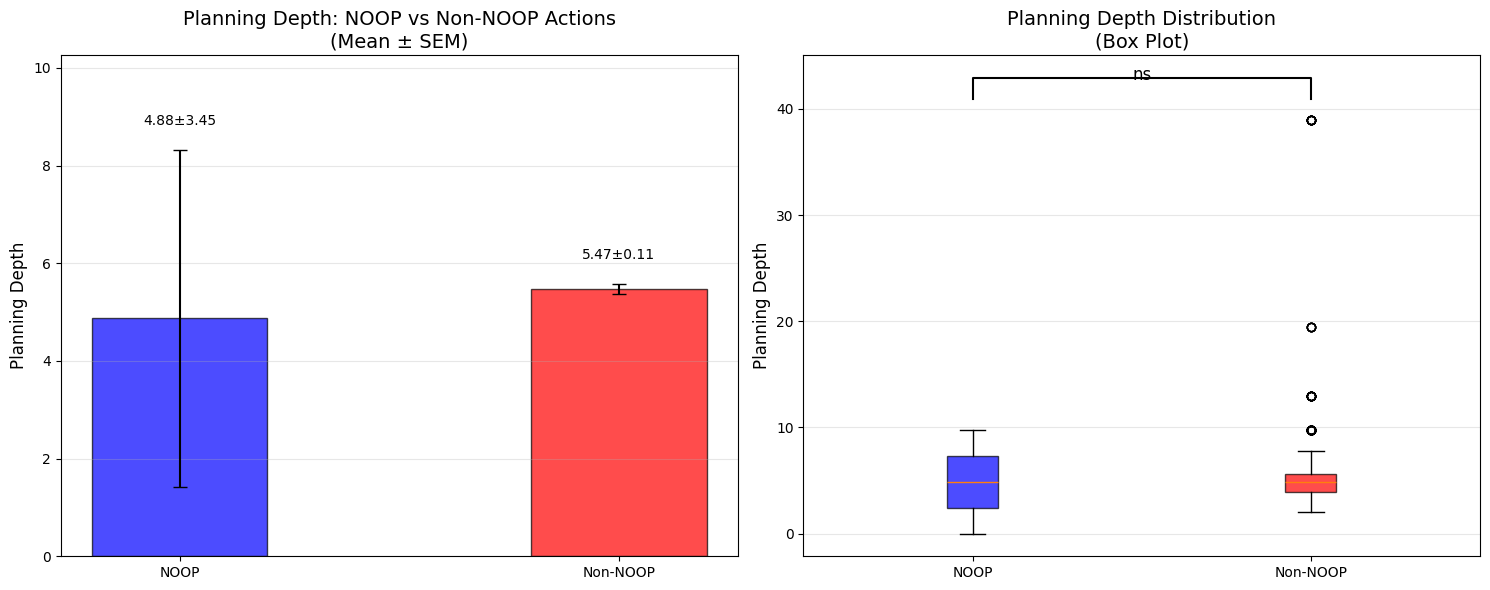


=== 상세 통계 ===
NOOP - 중앙값: 4.88, Q1: 2.44, Q3: 7.31
Non-NOOP - 중앙값: 4.88, Q1: 3.90, Q3: 5.57


In [7]:
def compare_planning_depth_noop_vs_nonnoop(data):
    """
    Real step에서 NOOP action과 Non-NOOP action의 planning depth를 비교합니다.
    Sliding window 없이 개별 real step 데이터를 사용합니다.
    
    Args:
        data: 로드된 데이터 딕셔너리
    """
    from scipy import stats
    import matplotlib.pyplot as plt
    
    def permutation_test(data1, data2, n_permutations=10000):
        """Permutation test for two independent samples"""
        def test_statistic(x, y):
            return np.mean(x) - np.mean(y)
        
        observed_diff = test_statistic(data1, data2)
        
        # Permutation samples
        combined_data = np.concatenate([data1, data2])
        permutation_diffs = []
        
        for _ in range(n_permutations):
            # Shuffle the combined data
            shuffled = np.random.permutation(combined_data)
            sample1 = shuffled[:len(data1)]
            sample2 = shuffled[len(data1):]
            permutation_diffs.append(test_statistic(sample1, sample2))
        
        # Calculate p-value
        p_value = np.mean(np.abs(permutation_diffs) >= np.abs(observed_diff))
        
        return observed_diff, p_value
    
    # status 데이터 분석 (planning depth 계산)
    status_data = data['status']
    real_indices, planning_depths, reset_info = analyze_status_data(status_data)
    
    # 각 real step의 action 추출
    real_step_actions = []
    for idx in real_indices:
        action_onehot = data['tree_reps']['cur_action'][idx]
        action_idx = np.argmax(action_onehot)
        real_step_actions.append(action_idx)
    
    real_step_actions = np.array(real_step_actions)
    
    # NOOP (action=0) vs Non-NOOP 분리
    noop_mask = real_step_actions == 0
    nonnoop_mask = real_step_actions != 0
    
    noop_planning_depths = np.array(planning_depths)[noop_mask]
    nonnoop_planning_depths = np.array(planning_depths)[nonnoop_mask]
    
    print(f"=== Planning Depth 비교 분석 ===")
    print(f"총 real step 개수: {len(real_step_actions)}")
    print(f"NOOP action 개수: {np.sum(noop_mask)} ({np.sum(noop_mask)/len(real_step_actions)*100:.1f}%)")
    print(f"Non-NOOP action 개수: {np.sum(nonnoop_mask)} ({np.sum(nonnoop_mask)/len(real_step_actions)*100:.1f}%)")
    
    # 통계 분석
    print(f"\n=== Planning Depth 통계 ===")
    print(f"NOOP 평균: {np.mean(noop_planning_depths):.2f} ± {np.std(noop_planning_depths):.2f}")
    print(f"Non-NOOP 평균: {np.mean(nonnoop_planning_depths):.2f} ± {np.std(nonnoop_planning_depths):.2f}")
    print(f"차이: {np.mean(noop_planning_depths) - np.mean(nonnoop_planning_depths):.2f}")
    
    # 정규성 검정 (Shapiro-Wilk test)
    _, noop_p_norm = stats.shapiro(noop_planning_depths)
    _, nonnoop_p_norm = stats.shapiro(nonnoop_planning_depths)
    
    print(f"\n=== 정규성 검정 (Shapiro-Wilk) ===")
    print(f"NOOP p-value: {noop_p_norm:.4f} {'(정규분포)' if noop_p_norm > 0.05 else '(정규분포 아님)'}")
    print(f"Non-NOOP p-value: {nonnoop_p_norm:.4f} {'(정규분포)' if nonnoop_p_norm > 0.05 else '(정규분포 아님)'}")
    
    # 등분산성 검정 (Levene's test)
    _, levene_p = stats.levene(noop_planning_depths, nonnoop_planning_depths)
    print(f"등분산성 검정 (Levene) p-value: {levene_p:.4f} {'(등분산)' if levene_p > 0.05 else '(이분산)'}")
    
    # 다양한 유의성 검정
    print(f"\n=== 유의성 검정 결과 ===")
    
    # 1. Parametric test (정규분포이고 등분산일 때)
    if noop_p_norm > 0.05 and nonnoop_p_norm > 0.05 and levene_p > 0.05:
        t_stat, t_p_value = stats.ttest_ind(noop_planning_depths, nonnoop_planning_depths)
        print(f"Independent t-test: p = {t_p_value:.6f}")
        parametric_test = "Independent t-test"
        parametric_p = t_p_value
    else:
        print("Parametric test 조건 불만족 (정규분포 아님 또는 이분산)")
        parametric_test = "N/A"
        parametric_p = None
    
    # 2. Mann-Whitney U test
    mw_stat, mw_p_value = stats.mannwhitneyu(noop_planning_depths, nonnoop_planning_depths, alternative='two-sided')
    print(f"Mann-Whitney U test: p = {mw_p_value:.6f}")
    
    # 3. Kolmogorov-Smirnov test
    ks_stat, ks_p_value = stats.ks_2samp(noop_planning_depths, nonnoop_planning_depths)
    print(f"Kolmogorov-Smirnov test: p = {ks_p_value:.6f}")
    
    # 4. Permutation test
    print("Permutation test 계산 중... (시간이 걸릴 수 있습니다)")
    perm_diff, perm_p_value = permutation_test(noop_planning_depths, nonnoop_planning_depths, n_permutations=10000)
    print(f"Permutation test: p = {perm_p_value:.6f}")
    
    # 가장 엄밀한 검정 결과 선택 (Permutation test 우선)
    if perm_p_value < 0.05:
        final_test = "Permutation test"
        final_p_value = perm_p_value
        significant = True
    elif ks_p_value < 0.05:
        final_test = "Kolmogorov-Smirnov test"
        final_p_value = ks_p_value
        significant = True
    elif mw_p_value < 0.05:
        final_test = "Mann-Whitney U test"
        final_p_value = mw_p_value
        significant = True
    else:
        final_test = "Permutation test"
        final_p_value = perm_p_value
        significant = False
    
    print(f"\n=== 최종 결과 ===")
    print(f"선택된 검정: {final_test}")
    print(f"p-value: {final_p_value:.6f}")
    print(f"유의수준: {'p < 0.001' if final_p_value < 0.001 else 'p < 0.01' if final_p_value < 0.01 else 'p < 0.05' if final_p_value < 0.05 else 'p >= 0.05'}")
    print(f"결과: {'유의한 차이 있음' if significant else '유의한 차이 없음'}")
    
    # 효과 크기 계산 (Cohen's d)
    pooled_std = np.sqrt(((len(noop_planning_depths) - 1) * np.var(noop_planning_depths, ddof=1) + 
                         (len(nonnoop_planning_depths) - 1) * np.var(nonnoop_planning_depths, ddof=1)) / 
                        (len(noop_planning_depths) + len(nonnoop_planning_depths) - 2))
    cohens_d = (np.mean(noop_planning_depths) - np.mean(nonnoop_planning_depths)) / pooled_std
    
    print(f"Cohen's d: {cohens_d:.3f}")
    if abs(cohens_d) < 0.2:
        effect_size = "작음"
    elif abs(cohens_d) < 0.5:
        effect_size = "중간"
    elif abs(cohens_d) < 0.8:
        effect_size = "큼"
    else:
        effect_size = "매우 큼"
    print(f"효과 크기: {effect_size}")
    
    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Bar plot with error bars
    categories = ['NOOP', 'Non-NOOP']
    means = [np.mean(noop_planning_depths), np.mean(nonnoop_planning_depths)]
    stds = [np.std(noop_planning_depths), np.std(nonnoop_planning_depths)]
    sems = [np.std(noop_planning_depths)/np.sqrt(len(noop_planning_depths)), 
            np.std(nonnoop_planning_depths)/np.sqrt(len(nonnoop_planning_depths))]
    
    # bar width를 0.4로 줄여서 얇게 만들기
    bars = ax1.bar(categories, means, yerr=sems, capsize=5, width=0.4,
                   color=['blue', 'red'], alpha=0.7, edgecolor='black')
    
    # 값 표시 위치 조정
    max_height = max(means) + max(sems)
    text_offset = max_height * 0.05
    
    for i, (bar, mean, sem) in enumerate(zip(bars, means, sems)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sem + text_offset,
                f'{mean:.2f}±{sem:.2f}', ha='center', va='bottom')
    
    # y축 범위 조정
    ax1.set_ylim(0, max_height + text_offset * 3)
    
    ax1.set_ylabel('Planning Depth', fontsize=12)
    ax1.set_title('Planning Depth: NOOP vs Non-NOOP Actions\n(Mean ± SEM)', fontsize=14)
    ax1.grid(axis='y', alpha=0.3)
    
    # 유의성 표시
    if final_p_value < 0.001:
        significance = '***'
    elif final_p_value < 0.01:
        significance = '**'
    elif final_p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'
    
    # 2. Box plot
    box_data = [noop_planning_depths, nonnoop_planning_depths]
    box_plot = ax2.boxplot(box_data, labels=categories, patch_artist=True)
    
    # 박스 색상 설정
    colors = ['blue', 'red']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Mann-Whitney test 유의성 표시 (*, **, ***)
    y_max = max(np.max(noop_planning_depths), np.max(nonnoop_planning_depths))
    y_offset = y_max * 0.05
    line_y = y_max + y_offset
    text_y = y_max + y_offset * 1.7
    x1, x2 = 1, 2  # NOOP and Non-NOOP positions

    if mw_p_value < 0.001:
        sig_label = '***'
    elif mw_p_value < 0.01:
        sig_label = '**'
    elif mw_p_value < 0.05:
        sig_label = '*'
    else:
        sig_label = 'ns'

    # 유의성 라인과 텍스트 추가
    ax2.plot([x1, x1, x2, x2], [line_y, line_y + y_offset, line_y + y_offset, line_y], lw=1.5, c='black')
    ax2.text((x1 + x2) * 0.5, text_y, sig_label, ha='center', va='bottom', fontsize=12)


    ax2.set_ylabel('Planning Depth', fontsize=12)
    ax2.set_title('Planning Depth Distribution\n(Box Plot)', fontsize=14)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 추가 통계 정보 출력
    print(f"\n=== 상세 통계 ===")
    print(f"NOOP - 중앙값: {np.median(noop_planning_depths):.2f}, Q1: {np.percentile(noop_planning_depths, 25):.2f}, Q3: {np.percentile(noop_planning_depths, 75):.2f}")
    print(f"Non-NOOP - 중앙값: {np.median(nonnoop_planning_depths):.2f}, Q1: {np.percentile(nonnoop_planning_depths, 25):.2f}, Q3: {np.percentile(nonnoop_planning_depths, 75):.2f}")
    
    return {
        'noop_planning_depths': noop_planning_depths,
        'nonnoop_planning_depths': nonnoop_planning_depths,
        'parametric_p': parametric_p,
        'mannwhitney_p': mw_p_value,
        'ks_p': ks_p_value,
        'permutation_p': perm_p_value,
        'final_test': final_test,
        'final_p_value': final_p_value,
        'cohens_d': cohens_d,
        'effect_size': effect_size
    }
# 함수 실행
results = compare_planning_depth_noop_vs_nonnoop(data)

### compare image similarity

CLIP loss

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lpips
import seaborn as sns
import clip
import torch
from PIL import Image
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from skimage.metrics import structural_similarity as ssim
from scipy import stats  # 분산/상관 검정용 (상단으로 이동)

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

# =========================
# Utilities
# =========================

def format_p_value(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def compute_offsets(y_max, i, base_scale=0.08):
    base_offset = y_max * base_scale
    line_y = y_max + base_offset * (i + 1.5)
    text_y = line_y + base_offset * 0.6
    return line_y, text_y

def normalize_image_dimensions(img_data):
    """
    입력 이미지를 (H, W, C) uint8로 통일.
    (기존 함수와 동일 동작; 디버깅 프린트 유지)
    """
    img_array = np.array(img_data)
    print(f"Original shape: {img_array.shape}, dtype: {img_array.dtype}")

    # (C,H,W) -> (H,W,C)
    if img_array.ndim == 3:
        c, h, w = img_array.shape
        if c == 3 and h > 1 and w > 1:
            img_array = np.transpose(img_array, (1, 2, 0))
        elif h == 3 and w > 1:
            img_array = np.transpose(img_array, (0, 2, 1))

    # 4D -> squeeze
    if img_array.ndim == 4:
        if img_array.shape[0] == 1:
            img_array = img_array.squeeze(0)
        if img_array.ndim == 4 and img_array.shape[1] == 1:
            img_array = img_array.squeeze(1)

    # 3D 정상 케이스
    if img_array.ndim == 3:
        h, w, c = img_array.shape
        if h > 1 and w > 1 and c in [1, 3]:
            if img_array.dtype != np.uint8:
                if img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                else:
                    img_array = img_array.astype(np.uint8)
            if c == 1:
                img_array = np.repeat(img_array, 3, axis=-1)
            return img_array

    # 2D grayscale -> 3채널
    if img_array.ndim == 2:
        h, w = img_array.shape
        if h > 1 and w > 1:
            if img_array.dtype != np.uint8:
                if img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                else:
                    img_array = img_array.astype(np.uint8)
            return np.stack([img_array, img_array, img_array], axis=-1)

    raise ValueError(f"Cannot normalize image with shape {img_array.shape} and dtype {img_array.dtype}")

# =========================
# Similarity backends
# =========================

def _cosine_similarity_images(imaginary_imgs, real_imgs):
    """픽셀 평탄화 코사인(기존 기능 유지)."""
    if not imaginary_imgs or not real_imgs:
        return 0.0
    L = min(len(imaginary_imgs), len(real_imgs))
    sims = []
    for i in range(L):
        sim_matrix = cosine_similarity(
            [np.array(imaginary_imgs[i]).reshape(-1)],
            [np.array(real_imgs[i]).reshape(-1)]
        )
        sims.append(float(sim_matrix[0, 0]))
    return float(np.mean(sims)) if sims else 0.0

def _ssim_similarity_images(imaginary_imgs, real_imgs):
    """각 채널 SSIM 평균(기존 기능 유지)."""
    if not imaginary_imgs or not real_imgs:
        return 0.0
    L = min(len(imaginary_imgs), len(real_imgs))
    sims = []
    for i in range(L):
        img1 = normalize_image_dimensions(imaginary_imgs[i])
        img2 = normalize_image_dimensions(real_imgs[i])
        ch_scores = [ssim(img1[:, :, c], img2[:, :, c], data_range=255) for c in range(3)]
        sims.append(float(np.mean(ch_scores)))
    return float(np.mean(sims)) if sims else 0.0

@torch.no_grad()
def _clip_similarity_images(imaginary_imgs, real_imgs, batch_size=32):
    """CLIP 임베딩 코사인(배치 인코딩) – 기존 기능 유지 + 가속."""
    if not imaginary_imgs or not real_imgs:
        return 0.0
    L = min(len(imaginary_imgs), len(real_imgs))

    def to_tensor_list(img_list):
        tensors = []
        for img in img_list:
            arr = normalize_image_dimensions(img)
            pil = Image.fromarray(arr)
            tensors.append(clip_preprocess(pil))
        return torch.stack(tensors, dim=0).to(device)

    tens_im = to_tensor_list(imaginary_imgs[:L])
    tens_re = to_tensor_list(real_imgs[:L])

    # 배치별 인코딩
    feats_im = []
    feats_re = []
    for start in range(0, L, batch_size):
        end = min(L, start + batch_size)
        feats_im.append(clip_model.encode_image(tens_im[start:end]))
        feats_re.append(clip_model.encode_image(tens_re[start:end]))
    feat_im = torch.cat(feats_im, dim=0)
    feat_re = torch.cat(feats_re, dim=0)
    feat_im = feat_im / feat_im.norm(dim=-1, keepdim=True)
    feat_re = feat_re / feat_re.norm(dim=-1, keepdim=True)
    sims = (feat_im * feat_re).sum(dim=-1).tolist()
    return float(np.mean(sims)) if sims else 0.0

@torch.no_grad()
def _clip_loss_similarity_images(imaginary_imgs, real_imgs, batch_size=32):
    """CLIP loss를 사용한 이미지 유사도 계산 (낮을수록 유사)."""
    if not imaginary_imgs or not real_imgs:
        return 1.0  # 최대 loss (최소 유사도)
    L = min(len(imaginary_imgs), len(real_imgs))

    def to_tensor_list(img_list):
        tensors = []
        for img in img_list:
            arr = normalize_image_dimensions(img)
            pil = Image.fromarray(arr)
            tensors.append(clip_preprocess(pil))
        return torch.stack(tensors, dim=0).to(device)

    tens_im = to_tensor_list(imaginary_imgs[:L])
    tens_re = to_tensor_list(real_imgs[:L])

    # 배치별 인코딩
    feats_im = []
    feats_re = []
    for start in range(0, L, batch_size):
        end = min(L, start + batch_size)
        feats_im.append(clip_model.encode_image(tens_im[start:end]))
        feats_re.append(clip_model.encode_image(tens_re[start:end]))
    feat_im = torch.cat(feats_im, dim=0)
    feat_re = torch.cat(feats_re, dim=0)
    
    # CLIP loss 계산 (1 - cosine similarity)
    feat_im = feat_im / feat_im.norm(dim=-1, keepdim=True)
    feat_re = feat_re / feat_re.norm(dim=-1, keepdim=True)
    losses = 1 - (feat_im * feat_re).sum(dim=-1)
    return float(torch.mean(losses).item()) if len(losses) > 0 else 1.0

SIM_BACKENDS = {
    "cosine": _cosine_similarity_images,
    "ssim": _ssim_similarity_images,
    "clip": _clip_similarity_images,
    "clip_loss": _clip_loss_similarity_images,  # 새로운 CLIP loss 백엔드
}

# =========================
# Extraction helpers
# =========================

def _get_real_indices(status):
    return [i for i, s in enumerate(status) if s == 0]

def _extract_imag_fragments_with_source(data, real_indices):
    """(fragment_imgs, source_real_idx) 리스트 반환."""
    status = data['status']
    im_imgs = data['im_imgs']  # im_vectors -> im_img로 변경
    out = []
    for pos, r_idx in enumerate(real_indices):
        start = r_idx + 1
        end = real_indices[pos + 1] if pos + 1 < len(real_indices) else len(status)
        cur = []
        for t in range(start, end):
            st = status[t]
            if st == 2 and t < len(im_imgs):
                cur.append(im_imgs[t])
            elif st in (1, 3):
                if cur:
                    out.append((cur, r_idx))
                    cur = []
        if cur:
            out.append((cur, r_idx))
    return out

def _extract_future_real_images(data, real_indices, start_real_order, max_length):
    """해당 real order 이후의 real 프레임들 max_length만큼 추출."""
    real_imgs = data['real_imgs']  # real_vectors -> real_img로 변경
    out = []
    for k in range(max_length):
        order = start_real_order + k
        if order < len(real_indices):
            r_idx = real_indices[order]
            if r_idx < len(real_imgs):
                out.append(real_imgs[r_idx])
    return out

def _get_next_real_action(data, real_indices, source_order):
    """다음 real step의 action index (없으면 -1)."""
    if source_order + 1 >= len(real_indices):
        return -1
    next_r = real_indices[source_order + 1]
    if next_r >= len(data['tree_reps']['cur_action']):
        return -1
    return int(np.argmax(data['tree_reps']['cur_action'][next_r]))

# =========================
# Main analysis
# =========================

def analyze_imaginary_image_similarity(data, similarity_mode="clip_loss"):
    """
    각 real step 근처 imagination fragment가 미래 real 이미지들과 얼마나 유사한지 계산.
    similarity_mode: {"cosine","ssim","clip","clip_loss"} (기본: clip_loss)
    """
    status = data['status']
    real_indices = _get_real_indices(status)
    fragments_with_source = _extract_imag_fragments_with_source(data, real_indices)

    sim_fn = SIM_BACKENDS.get(similarity_mode, SIM_BACKENDS["clip_loss"])
    fragment_results = []

    # 미리 dict로 real_idx -> order 매핑(중복 탐색 제거)
    real_idx_to_order = {idx: o for o, idx in enumerate(real_indices)}

    for frag_imgs, src_ridx in fragments_with_source:
        if not frag_imgs:
            continue

        src_order = real_idx_to_order[src_ridx]
        label_action = _get_next_real_action(data, real_indices, src_order)

        # fragment 길이만큼 미래 real 이미지 수집
        real_images = _extract_future_real_images(
            data, real_indices, start_real_order=src_order + 1, max_length=len(frag_imgs)
        )

        if not real_images:
            fragment_results.append({
                'fragment_imgs': frag_imgs,
                'source_real_idx': src_ridx,
                'source_real_order': src_order,
                'label_action': label_action,
                'real_images': [],
                'predicted_real_steps': [],
                'similarity': np.nan,
                'fragment_length': len(frag_imgs),
                'real_length': 0
            })
            continue

        similarity = sim_fn(frag_imgs, real_images)

        # 예측 real step 인덱스 기록
        pred_steps = []
        for k in range(len(real_images)):
            if src_order + 1 + k < len(real_indices):
                pred_steps.append(real_indices[src_order + 1 + k])

        fragment_results.append({
            'fragment_imgs': frag_imgs,
            'source_real_idx': src_ridx,
            'source_real_order': src_order,
            'label_action': label_action,
            'real_images': real_images,
            'predicted_real_steps': pred_steps,
            'similarity': similarity,
            'fragment_length': len(frag_imgs),
            'real_length': len(real_images)
        })

    return fragment_results

# =========================
# Visualization
# =========================

def visualize_imaginary_image_similarity_analysis(fragment_results):
    if not fragment_results:
        print("분석할 데이터가 없습니다.")
        return

    # ---------- 배열/집계 사전 계산 ----------
    frag_sims = np.array([r['similarity'] for r in fragment_results], dtype=float)
    frag_actions = np.array([r.get('label_action', -1) for r in fragment_results], dtype=int)
    frag_lengths = np.array([r['fragment_length'] for r in fragment_results], dtype=int)
    src_orders = np.array([r['source_real_order'] for r in fragment_results], dtype=int)
    src_real_indices = np.array([r['source_real_idx'] for r in fragment_results], dtype=int)

    valid_mask = np.isfinite(frag_sims) & (frag_actions >= 0)
    valid_sims = frag_sims[valid_mask]
    valid_actions = frag_actions[valid_mask]
    valid_lengths = frag_lengths[valid_mask]
    valid_src_orders = src_orders[valid_mask]
    valid_src_real_indices = src_real_indices[valid_mask]

    # real step 기준 평균(sim, depth=fragment len)
    real_step_results = defaultdict(list)
    real_step_depths = defaultdict(list)
    for sim, flen, ridx in zip(valid_sims, valid_lengths, valid_src_real_indices):
        real_step_results[ridx].append(sim)
        real_step_depths[ridx].append(flen)

    ordered_keys = list(real_step_results.keys())
    avg_similarities = [np.mean(real_step_results[k]) for k in ordered_keys]
    avg_planning_depths = [np.mean(real_step_depths[k]) for k in ordered_keys]
    real_step_orders = list(range(len(ordered_keys)))

    # NOOP vs Non-NOOP
    noop_mask = valid_actions == 0
    nonnoop_mask = ~noop_mask
    noop_sims = valid_sims[noop_mask]
    nonnoop_sims = valid_sims[nonnoop_mask]

    # ---------- Plot ----------
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))

    # 1) 평균 유사도 분포(Real step)
    if len(avg_similarities):
        axes[0, 0].hist(avg_similarities, bins=20, alpha=0.7, color='blue', edgecolor='black')
        axes[0, 0].set_xlabel('Average Image Similarity')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Average Image Similarity (Real Step)')
        axes[0, 0].axvline(np.mean(avg_similarities), color='red', linestyle='--',
                           label=f'Mean: {np.mean(avg_similarities):.3f}')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    else:
        axes[0, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].set_title('Distribution of Average Image Similarity (Real Step)')

    # 2) NOOP vs Non-NOOP 분포
    if len(noop_sims) > 0 and len(nonnop_sims := nonnoop_sims) > 0:
        all_data = np.concatenate([noop_sims, nonnop_sims])
        bins = np.linspace(all_data.min(), all_data.max(), 16)
        axes[0, 1].hist(noop_sims, bins=bins, alpha=0.7, label='NOOP', color='orange', edgecolor='black')
        axes[0, 1].hist(nonnop_sims, bins=bins, alpha=0.7, label='Non-NOOP', color='blue', edgecolor='black')
        axes[0, 1].set_xlabel('Image Similarity')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Image Similarity Distribution: NOOP vs Non-NOOP (Fragment)')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'No NOOP data available', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Image Similarity Distribution: NOOP vs Non-NOOP (Fragment)')

    # 3) Real step: avg depth vs avg sim (상관)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        r, p = stats.pearsonr(avg_planning_depths, avg_similarities)
        axes[0, 2].scatter(avg_planning_depths, avg_similarities, alpha=0.6, color='purple')
        axes[0, 2].set_xlabel('Average Planning Depth')
        axes[0, 2].set_ylabel('Average Image Similarity')
        axes[0, 2].set_title(f'Real Step: Image Similarity vs Planning Depth\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 2].grid(True, alpha=0.3)
        if len(avg_similarities) > 1:
            z = np.polyfit(avg_planning_depths, avg_similarities, 1)
            pfit = np.poly1d(z)
            axes[0, 2].plot(avg_planning_depths, pfit(avg_planning_depths), "r--", alpha=0.8)
    else:
        axes[0, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('Real Step: Image Similarity vs Planning Depth')

    # 4) Fragment: length vs sim (상관)
    if len(valid_lengths) and len(valid_lengths) == len(valid_sims):
        r, p = stats.pearsonr(valid_lengths, valid_sims)
        axes[0, 3].scatter(valid_lengths, valid_sims, alpha=0.6, color='green')
        axes[0, 3].set_xlabel('Planning Depth')
        axes[0, 3].set_ylabel('Image Similarity')
        axes[0, 3].set_title(f'Fragment: Image Similarity vs Planning Depth\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 3].grid(True, alpha=0.3)
        if len(valid_sims) > 1:
            z = np.polyfit(valid_lengths, valid_sims, 1)
            pfit = np.poly1d(z)
            axes[0, 3].plot(valid_lengths, pfit(valid_lengths), "r--", alpha=0.8)
    else:
        axes[0, 3].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 3].transAxes)
        axes[0, 3].set_title('Fragment: Image Similarity vs Planning Depth')

    # 5) 평균 유사도 vs 시간(Real step 순서)
    if len(avg_similarities) and len(real_step_orders):
        axes[1, 0].scatter(real_step_orders, avg_similarities, alpha=0.6, color='purple')
        axes[1, 0].set_xlabel('Real Step Order')
        axes[1, 0].set_ylabel('Average Image Similarity')
        axes[1, 0].set_title('Average Image Similarity Over Time (Real Step)')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Average Image Similarity Over Time (Real Step)')

    # 6) NOOP freq vs avg depth (슬라이딩 윈도우, 색=avg sim)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        window_size, stride = 160, 2

        real_step_actions = []
        for ridx in ordered_keys:
            # 해당 real step의 action 찾기
            if ridx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][ridx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
        # real_idx -> (sims, action) 테이블로 바꿔두면 아래 반복이 단순해짐
        # real_idx_to_sims = real_step_results
        # real_idx_to_actions = defaultdict(list)
        #for a, s, ridx in zip(valid_actions, valid_sims, valid_src_real_indices):
        #     real_idx_to_actions[ridx].append(a)

        keys_in_order = ordered_keys  # dict 순서 의존 대신 위에서 만든 순서 사용
        window_noop_freq = []
        window_avg_depth = []
        window_avg_sim = []

        for i in range(0, len(keys_in_order) - window_size + 1, stride):
            w_keys = keys_in_order[i:i+window_size]
            window_actions = [real_step_actions[j] for j in range(i, i+window_size)]
            noop_count = np.sum(np.array(window_actions) == 0)
            noop_frequency = noop_count / window_size
            # fragment 기반 NOOP 비율(기존 로직 유지)
            # tot = 0
            # noop_cnt = 0
            # for k in w_keys:
            #     actions = real_idx_to_actions.get(k, [])
            #     sims_here = real_idx_to_sims.get(k, [])
            #     for a, s in zip(actions, sims_here):
            #         tot += 1  # 모든 fragment 포함
            #         if a == 0:
            #             noop_cnt += 1
            # if tot == 0:
            #     continue
            # window_noop_freq.append(noop_cnt / tot)
            window_noop_freq.append(noop_frequency)
            depth_vals = [np.mean(real_step_depths[k]) for k in w_keys if len(real_step_depths[k])]
            sim_vals = [np.mean(real_step_results[k]) for k in w_keys if len(real_step_results[k])]
            window_avg_depth.append(np.mean(depth_vals) if depth_vals else np.nan)
            window_avg_sim.append(np.mean(sim_vals) if sim_vals else np.nan)

        if window_noop_freq:
            # Real step 단위로 correlation 계산
            r, p = stats.pearsonr(window_noop_freq, window_avg_depth)
            scatter = axes[1, 1].scatter(window_noop_freq, window_avg_depth,
                                        c=window_avg_sim, cmap='viridis',
                                        s=100, alpha=0.7, edgecolors='none')
            axes[1, 1].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 1].set_ylabel('Average Planning Depth (Sliding Window)')
            axes[1, 1].set_title(f'NOOP Frequency vs Planning Depth (Sliding Window)\n'
                                f'(Color: Image Similarity, r = {r:.3f}, {format_p_value(p)})')
            axes[1, 1].grid(True, alpha=0.3)
            cbar = plt.colorbar(scatter, ax=axes[1, 1]); cbar.set_label('Image Similarity')

            if len(window_noop_freq) > 1:
                z = np.polyfit(window_noop_freq, window_avg_depth, 1)
                pfit = np.poly1d(z)
                axes[1, 1].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('NOOP Frequency vs Planning Depth (Sliding Window)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('NOOP Frequency vs Planning Depth (Sliding Window)')

    # 7) NOOP freq vs avg sim (슬라이딩 윈도우)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_sim2 = []
        
        # real step별 action 정보 준비 (6번 그래프에서 이미 준비했다면 재사용)
        real_step_actions = []
        for ridx in ordered_keys:
            if ridx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][ridx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
        
        for i in range(0, len(keys_in_order) - window_size + 1, stride):
            w_keys = keys_in_order[i:i+window_size]
            
            # real step 기반 NOOP 빈도 계산
            window_actions = [real_step_actions[j] for j in range(i, i+window_size)]
            noop_count = np.sum(np.array(window_actions) == 0)
            noop_frequency = noop_count / window_size
            
            # real step 단위 평균 similarity 계산
            sim_vals = [avg_similarities[j] for j in range(i, i+window_size)]
            window_avg_sim = np.mean(sim_vals)
            
            window_noop_freq.append(noop_frequency)
            window_avg_sim2.append(window_avg_sim)

        if window_noop_freq:
            # Real step 단위로 correlation 계산
            r, p = stats.pearsonr(window_noop_freq, window_avg_sim2)
            axes[1, 2].scatter(window_noop_freq, window_avg_sim2, alpha=0.7, color='purple', s=100)
            axes[1, 2].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 2].set_ylabel('Image Similarity (Sliding Window)')
            axes[1, 2].set_title(f'NOOP Frequency vs Image Similarity (Sliding Window)\n'
                                f'r = {r:.3f}, {format_p_value(p)}')
            axes[1, 2].grid(True, alpha=0.3)
            if len(window_noop_freq) > 1:
                z = np.polyfit(window_noop_freq, window_avg_sim2, 1)
                pfit = np.poly1d(z)
                axes[1, 2].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('NOOP Frequency vs Image Similarity (Sliding Window)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('NOOP Frequency vs Image Similarity (Sliding Window)')

    # 8) NOOP vs Non-NOOP Box-plot (Real step 단위로 수정)
    if len(avg_similarities) > 0:
        # real step별 action 정보 준비
        real_step_actions = []
        for ridx in ordered_keys:
            if ridx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][ridx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
        
        # real step 단위로 NOOP/Non-NOOP 분류
        noop_mask = np.array(real_step_actions) == 0
        nonnoop_mask = ~noop_mask
        
        noop_sims_real = [avg_similarities[i] for i in range(len(avg_similarities)) if noop_mask[i]]
        nonnoop_sims_real = [avg_similarities[i] for i in range(len(avg_similarities)) if nonnoop_mask[i]]
        
        if len(noop_sims_real) > 0 and len(nonnoop_sims_real) > 0:
            _, p_norm1 = stats.shapiro(noop_sims_real)
            _, p_norm2 = stats.shapiro(nonnoop_sims_real)
            _, p_lev = stats.levene(noop_sims_real, nonnoop_sims_real)
            if p_norm1 > 0.05 and p_norm2 > 0.05 and p_lev > 0.05:
                _, p_val = stats.ttest_ind(noop_sims_real, nonnoop_sims_real)
                test_name = "t-test"
            else:
                _, p_val = stats.mannwhitneyu(noop_sims_real, nonnoop_sims_real, alternative='two-sided')
                test_name = "Mann-Whitney U"

            signif = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            bp = axes[1, 3].boxplot([noop_sims_real, nonnoop_sims_real], labels=['NOOP', 'Non-NOOP'], patch_artist=True)
            for patch, col in zip(bp['boxes'], ['orange', 'blue']):
                patch.set_facecolor(col); patch.set_alpha(0.7)
            axes[1, 3].set_ylabel('Image Similarity')
            axes[1, 3].set_title(f'Image Similarity: NOOP vs Non-NOOP (Real Step)\n{test_name}: {format_p_value(p_val)} {signif}')
            axes[1, 3].grid(True, alpha=0.3)

            y_max = max(np.max(noop_sims_real), np.max(nonnoop_sims_real))
            y_off = y_max * 0.05
            line_y, text_y = y_max + y_off, y_max + y_off * 2.1
            axes[1, 3].plot([1, 1, 2, 2], [line_y, line_y + y_off, line_y + y_off, line_y], lw=1.5, c='black')
            axes[1, 3].text(1.5, text_y, signif, ha='center', va='bottom', fontsize=12)
        else:
            axes[1, 3].text(0.5, 0.5, 'No NOOP data available', ha='center', va='center', transform=axes[1, 3].transAxes)
            axes[1, 3].set_title('Image Similarity: NOOP vs Non-NOOP (Real Step)')
    else:
        axes[1, 3].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 3].transAxes)
        axes[1, 3].set_title('Image Similarity: NOOP vs Non-NOOP (Real Step)')

    plt.tight_layout()
    plt.show()

    # ---------- 텍스트 요약 ----------
    print("=== Imaginary Image Similarity Analysis ===")
    print(f"총 real step: {len(ordered_keys)}")
    print(f"총 imagination fragment: {len(fragment_results)}")
    print(f"유효한 fragment (유사도 계산 가능): {len(valid_sims)}")
    if len(avg_similarities):
        print(f"평균 이미지 유사도 (Real step): {np.mean(avg_similarities):.3f} ± {np.std(avg_similarities):.3f}")
    print(f"평균 이미지 유사도 (Fragment): {np.nanmean(frag_sims):.3f} ± {np.nanstd(frag_sims):.3f}")
    print(f"평균 fragment 길이: {np.mean(frag_lengths):.2f} ± {np.std(frag_lengths):.2f}")

    if len(noop_sims) > 0 and len(nonnop_sims) > 0:
        print("\n=== NOOP vs Non-NOOP Image Similarity (Fragment) ===")
        print(f"NOOP (n={len(noop_sims)}): {np.mean(noop_sims):.3f} ± {np.std(noop_sims):.3f}")
        print(f"Non-NOOP (n={len(nonnop_sims)}): {np.mean(nonnop_sims):.3f} ± {np.std(nonnop_sims):.3f}")
        print(f"{test_name}: {format_p_value(p_val)}")

    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        r, p = stats.pearsonr(avg_similarities, avg_planning_depths)
        print(f"\n=== Real Step: Image Similarity vs Planning Depth ===")
        print(f"Pearson correlation: r = {r:.3f}, {format_p_value(p)}")

    if len(valid_lengths) and len(valid_lengths) == len(valid_sims):
        r, p = stats.pearsonr(valid_lengths, valid_sims)
        print(f"\n=== Fragment: Image Similarity vs Planning Depth ===")
        print(f"Pearson correlation: r = {r:.3f}, {format_p_value(p)}")


# 사용 예시:
fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="clip_loss")
if fragment_results:
    visualize_imaginary_image_similarity_analysis(fragment_results)

compare encoded vector

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lpips
import seaborn as sns
import clip
import torch
from PIL import Image
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from skimage.metrics import structural_similarity as ssim
from scipy import stats  # 분산/상관 검정용 (상단으로 이동)

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

# =========================
# Utilities
# =========================

def format_p_value(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def compute_offsets(y_max, i, base_scale=0.08):
    base_offset = y_max * base_scale
    line_y = y_max + base_offset * (i + 1.5)
    text_y = line_y + base_offset * 0.6
    return line_y, text_y

def normalize_image_dimensions(img_data):
    """
    입력 이미지를 (H, W, C) uint8로 통일.
    (기존 함수와 동일 동작; 디버깅 프린트 유지)
    """
    img_array = np.array(img_data)
    print(f"Original shape: {img_array.shape}, dtype: {img_array.dtype}")

    # (C,H,W) -> (H,W,C)
    if img_array.ndim == 3:
        c, h, w = img_array.shape
        if c == 3 and h > 1 and w > 1:
            img_array = np.transpose(img_array, (1, 2, 0))
        elif h == 3 and w > 1:
            img_array = np.transpose(img_array, (0, 2, 1))

    # 4D -> squeeze
    if img_array.ndim == 4:
        if img_array.shape[0] == 1:
            img_array = img_array.squeeze(0)
        if img_array.ndim == 4 and img_array.shape[1] == 1:
            img_array = img_array.squeeze(1)

    # 3D 정상 케이스
    if img_array.ndim == 3:
        h, w, c = img_array.shape
        if h > 1 and w > 1 and c in [1, 3]:
            if img_array.dtype != np.uint8:
                if img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                else:
                    img_array = img_array.astype(np.uint8)
            if c == 1:
                img_array = np.repeat(img_array, 3, axis=-1)
            return img_array

    # 2D grayscale -> 3채널
    if img_array.ndim == 2:
        h, w = img_array.shape
        if h > 1 and w > 1:
            if img_array.dtype != np.uint8:
                if img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                else:
                    img_array = img_array.astype(np.uint8)
            return np.stack([img_array, img_array, img_array], axis=-1)

    raise ValueError(f"Cannot normalize image with shape {img_array.shape} and dtype {img_array.dtype}")

# =========================
# Similarity backends
# =========================

def _cosine_similarity_images(imaginary_imgs, real_imgs):
    """픽셀 평탄화 코사인(기존 기능 유지)."""
    if not imaginary_imgs or not real_imgs:
        return 0.0
    L = min(len(imaginary_imgs), len(real_imgs))
    sims = []
    for i in range(L):
        sim_matrix = cosine_similarity(
            [np.array(imaginary_imgs[i]).reshape(-1)],
            [np.array(real_imgs[i]).reshape(-1)]
        )
        sims.append(float(sim_matrix[0, 0]))
    return float(np.mean(sims)) if sims else 0.0

def _ssim_similarity_images(imaginary_imgs, real_imgs):
    """각 채널 SSIM 평균(기존 기능 유지)."""
    if not imaginary_imgs or not real_imgs:
        return 0.0
    L = min(len(imaginary_imgs), len(real_imgs))
    sims = []
    for i in range(L):
        img1 = normalize_image_dimensions(imaginary_imgs[i])
        img2 = normalize_image_dimensions(real_imgs[i])
        ch_scores = [ssim(img1[:, :, c], img2[:, :, c], data_range=255) for c in range(3)]
        sims.append(float(np.mean(ch_scores)))
    return float(np.mean(sims)) if sims else 0.0

@torch.no_grad()
def _clip_similarity_images(imaginary_imgs, real_imgs, batch_size=32):
    """CLIP 임베딩 코사인(배치 인코딩) – 기존 기능 유지 + 가속."""
    if not imaginary_imgs or not real_imgs:
        return 0.0
    L = min(len(imaginary_imgs), len(real_imgs))

    def to_tensor_list(img_list):
        tensors = []
        for img in img_list:
            arr = normalize_image_dimensions(img)
            pil = Image.fromarray(arr)
            tensors.append(clip_preprocess(pil))
        return torch.stack(tensors, dim=0).to(device)

    tens_im = to_tensor_list(imaginary_imgs[:L])
    tens_re = to_tensor_list(real_imgs[:L])

    # 배치별 인코딩
    feats_im = []
    feats_re = []
    for start in range(0, L, batch_size):
        end = min(L, start + batch_size)
        feats_im.append(clip_model.encode_image(tens_im[start:end]))
        feats_re.append(clip_model.encode_image(tens_re[start:end]))
    feat_im = torch.cat(feats_im, dim=0)
    feat_re = torch.cat(feats_re, dim=0)
    feat_im = feat_im / feat_im.norm(dim=-1, keepdim=True)
    feat_re = feat_re / feat_re.norm(dim=-1, keepdim=True)
    sims = (feat_im * feat_re).sum(dim=-1).tolist()
    return float(np.mean(sims)) if sims else 0.0

SIM_BACKENDS = {
    "cosine": _cosine_similarity_images,
    "ssim": _ssim_similarity_images,
    "clip": _clip_similarity_images,
}

# =========================
# Extraction helpers
# =========================

def _get_real_indices(status):
    return [i for i, s in enumerate(status) if s == 0]

def _extract_imag_fragments_with_source(data, real_indices):
    """(fragment_imgs, source_real_idx) 리스트 반환."""
    status = data['status']
    im_imgs = data['im_vectors']
    out = []
    for pos, r_idx in enumerate(real_indices):
        start = r_idx + 1
        end = real_indices[pos + 1] if pos + 1 < len(real_indices) else len(status)
        cur = []
        for t in range(start, end):
            st = status[t]
            if st == 2 and t < len(im_imgs):
                cur.append(im_imgs[t])
            elif st in (1, 3):
                if cur:
                    out.append((cur, r_idx))
                    cur = []
        if cur:
            out.append((cur, r_idx))
    return out

def _extract_future_real_images(data, real_indices, start_real_order, max_length):
    """해당 real order 이후의 real 프레임들 max_length만큼 추출."""
    real_imgs = data['real_vectors']
    out = []
    for k in range(max_length):
        order = start_real_order + k
        if order < len(real_indices):
            r_idx = real_indices[order]
            if r_idx < len(real_imgs):
                out.append(real_imgs[r_idx])
    return out

def _get_next_real_action(data, real_indices, source_order):
    """다음 real step의 action index (없으면 -1)."""
    if source_order + 1 >= len(real_indices):
        return -1
    next_r = real_indices[source_order + 1]
    if next_r >= len(data['tree_reps']['cur_action']):
        return -1
    return int(np.argmax(data['tree_reps']['cur_action'][next_r]))

# =========================
# Main analysis
# =========================

def analyze_imaginary_image_similarity(data, similarity_mode="cosine"):
    """
    각 real step 근처 imagination fragment가 미래 real 이미지들과 얼마나 유사한지 계산.
    similarity_mode: {"cosine","ssim","clip"} (기본: 기존과 동일한 cosine)
    """
    status = data['status']
    real_indices = _get_real_indices(status)
    fragments_with_source = _extract_imag_fragments_with_source(data, real_indices)

    sim_fn = SIM_BACKENDS.get(similarity_mode, SIM_BACKENDS["cosine"])
    fragment_results = []

    # 미리 dict로 real_idx -> order 매핑(중복 탐색 제거)
    real_idx_to_order = {idx: o for o, idx in enumerate(real_indices)}

    for frag_imgs, src_ridx in fragments_with_source:
        if not frag_imgs:
            continue

        src_order = real_idx_to_order[src_ridx]
        label_action = _get_next_real_action(data, real_indices, src_order)

        # fragment 길이만큼 미래 real 이미지 수집
        real_images = _extract_future_real_images(
            data, real_indices, start_real_order=src_order + 1, max_length=len(frag_imgs)
        )

        if not real_images:
            fragment_results.append({
                'fragment_imgs': frag_imgs,
                'source_real_idx': src_ridx,
                'source_real_order': src_order,
                'label_action': label_action,
                'real_images': [],
                'predicted_real_steps': [],
                'similarity': np.nan,
                'fragment_length': len(frag_imgs),
                'real_length': 0
            })
            continue

        similarity = sim_fn(frag_imgs, real_images)

        # 예측 real step 인덱스 기록
        pred_steps = []
        for k in range(len(real_images)):
            if src_order + 1 + k < len(real_indices):
                pred_steps.append(real_indices[src_order + 1 + k])

        fragment_results.append({
            'fragment_imgs': frag_imgs,
            'source_real_idx': src_ridx,
            'source_real_order': src_order,
            'label_action': label_action,
            'real_images': real_images,
            'predicted_real_steps': pred_steps,
            'similarity': similarity,
            'fragment_length': len(frag_imgs),
            'real_length': len(real_images)
        })

    return fragment_results

# =========================
# Visualization
# =========================

def visualize_imaginary_image_similarity_analysis(fragment_results):
    if not fragment_results:
        print("분석할 데이터가 없습니다.")
        return

    # ---------- 배열/집계 사전 계산 ----------
    frag_sims = np.array([r['similarity'] for r in fragment_results], dtype=float)
    frag_actions = np.array([r.get('label_action', -1) for r in fragment_results], dtype=int)
    frag_lengths = np.array([r['fragment_length'] for r in fragment_results], dtype=int)
    src_orders = np.array([r['source_real_order'] for r in fragment_results], dtype=int)
    src_real_indices = np.array([r['source_real_idx'] for r in fragment_results], dtype=int)

    valid_mask = np.isfinite(frag_sims) & (frag_actions >= 0)
    valid_sims = frag_sims[valid_mask]
    valid_actions = frag_actions[valid_mask]
    valid_lengths = frag_lengths[valid_mask]
    valid_src_orders = src_orders[valid_mask]
    valid_src_real_indices = src_real_indices[valid_mask]

    # real step 기준 평균(sim, depth=fragment len)
    real_step_results = defaultdict(list)
    real_step_depths = defaultdict(list)
    for sim, flen, ridx in zip(valid_sims, valid_lengths, valid_src_real_indices):
        real_step_results[ridx].append(sim)
        real_step_depths[ridx].append(flen)

    ordered_keys = list(real_step_results.keys())
    avg_similarities = [np.mean(real_step_results[k]) for k in ordered_keys]
    avg_planning_depths = [np.mean(real_step_depths[k]) for k in ordered_keys]
    real_step_orders = list(range(len(ordered_keys)))

    # NOOP vs Non-NOOP
    noop_mask = valid_actions == 0
    nonnoop_mask = ~noop_mask
    noop_sims = valid_sims[noop_mask]
    nonnoop_sims = valid_sims[nonnoop_mask]

    # ---------- Plot ----------
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))

    # 1) 평균 유사도 분포(Real step)
    if len(avg_similarities):
        axes[0, 0].hist(avg_similarities, bins=20, alpha=0.7, color='blue', edgecolor='black')
        axes[0, 0].set_xlabel('Average Image Similarity')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Average Image Similarity (Real Step)')
        axes[0, 0].axvline(np.mean(avg_similarities), color='red', linestyle='--',
                           label=f'Mean: {np.mean(avg_similarities):.3f}')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    else:
        axes[0, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].set_title('Distribution of Average Image Similarity (Real Step)')

    # 2) NOOP vs Non-NOOP 분포
    if len(noop_sims) > 0 and len(nonnop_sims := nonnoop_sims) > 0:
        all_data = np.concatenate([noop_sims, nonnop_sims])
        bins = np.linspace(all_data.min(), all_data.max(), 16)
        axes[0, 1].hist(noop_sims, bins=bins, alpha=0.7, label='NOOP', color='orange', edgecolor='black')
        axes[0, 1].hist(nonnop_sims, bins=bins, alpha=0.7, label='Non-NOOP', color='blue', edgecolor='black')
        axes[0, 1].set_xlabel('Image Similarity')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Image Similarity Distribution: NOOP vs Non-NOOP (Fragment)')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'No NOOP data available', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Image Similarity Distribution: NOOP vs Non-NOOP (Fragment)')

    # 3) Real step: avg depth vs avg sim (상관)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        r, p = stats.pearsonr(avg_planning_depths, avg_similarities)
        axes[0, 2].scatter(avg_planning_depths, avg_similarities, alpha=0.6, color='purple')
        axes[0, 2].set_xlabel('Average Planning Depth')
        axes[0, 2].set_ylabel('Average Image Similarity')
        axes[0, 2].set_title(f'Real Step: Image Similarity vs Planning Depth\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 2].grid(True, alpha=0.3)
        if len(avg_similarities) > 1:
            z = np.polyfit(avg_planning_depths, avg_similarities, 1)
            pfit = np.poly1d(z)
            axes[0, 2].plot(avg_planning_depths, pfit(avg_planning_depths), "r--", alpha=0.8)
    else:
        axes[0, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('Real Step: Image Similarity vs Planning Depth')

    # 4) Fragment: length vs sim (상관)
    if len(valid_lengths) and len(valid_lengths) == len(valid_sims):
        r, p = stats.pearsonr(valid_lengths, valid_sims)
        axes[0, 3].scatter(valid_lengths, valid_sims, alpha=0.6, color='green')
        axes[0, 3].set_xlabel('Planning Depth')
        axes[0, 3].set_ylabel('Image Similarity')
        axes[0, 3].set_title(f'Fragment: Image Similarity vs Planning Depth\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 3].grid(True, alpha=0.3)
        if len(valid_sims) > 1:
            z = np.polyfit(valid_lengths, valid_sims, 1)
            pfit = np.poly1d(z)
            axes[0, 3].plot(valid_lengths, pfit(valid_lengths), "r--", alpha=0.8)
    else:
        axes[0, 3].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 3].transAxes)
        axes[0, 3].set_title('Fragment: Image Similarity vs Planning Depth')

    # 5) 평균 유사도 vs 시간(Real step 순서)
    if len(avg_similarities) and len(real_step_orders):
        axes[1, 0].scatter(real_step_orders, avg_similarities, alpha=0.6, color='purple')
        axes[1, 0].set_xlabel('Real Step Order')
        axes[1, 0].set_ylabel('Average Image Similarity')
        axes[1, 0].set_title('Average Image Similarity Over Time (Real Step)')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Average Image Similarity Over Time (Real Step)')

    # 6) NOOP freq vs avg depth (슬라이딩 윈도우, 색=avg sim)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        window_size, stride = 160, 2
        # real_idx -> (sims, action) 테이블로 바꿔두면 아래 반복이 단순해짐
        real_idx_to_sims = real_step_results
        real_idx_to_actions = defaultdict(list)
        for a, s, ridx in zip(valid_actions, valid_sims, valid_src_real_indices):
            real_idx_to_actions[ridx].append(a)

        keys_in_order = ordered_keys  # dict 순서 의존 대신 위에서 만든 순서 사용
        window_noop_freq = []
        window_avg_depth = []
        window_avg_sim = []

        for i in range(0, len(keys_in_order) - window_size + 1, stride):
            w_keys = keys_in_order[i:i+window_size]
            # fragment 기반 NOOP 비율(기존 로직 유지)
            tot = 0
            noop_cnt = 0
            for k in w_keys:
                actions = real_idx_to_actions.get(k, [])
                sims_here = real_idx_to_sims.get(k, [])
                for a, s in zip(actions, sims_here):  # 유사도 있는 fragment만 카운트
                    if np.isfinite(s):
                        tot += 1
                        if a == 0:
                            noop_cnt += 1
            if tot == 0:
                continue
            window_noop_freq.append(noop_cnt / tot)

            depth_vals = [np.mean(real_step_depths[k]) for k in w_keys if len(real_step_depths[k])]
            sim_vals = [np.mean(real_step_results[k]) for k in w_keys if len(real_step_results[k])]
            window_avg_depth.append(np.mean(depth_vals) if depth_vals else np.nan)
            window_avg_sim.append(np.mean(sim_vals) if sim_vals else np.nan)

        if window_noop_freq:
            r, p = stats.pearsonr(window_noop_freq, window_avg_depth)
            scatter = axes[1, 1].scatter(window_noop_freq, window_avg_depth,
                                         c=window_avg_sim, cmap='viridis',
                                         s=100, alpha=0.7, edgecolors='none')
            axes[1, 1].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 1].set_ylabel('Average Planning Depth (Sliding Window)')
            axes[1, 1].set_title(f'NOOP Frequency vs Planning Depth (Sliding Window)\n'
                                 f'(Color: Image Similarity, r = {r:.3f}, {format_p_value(p)})')
            axes[1, 1].grid(True, alpha=0.3)
            cbar = plt.colorbar(scatter, ax=axes[1, 1]); cbar.set_label('Image Similarity')

            if len(window_noop_freq) > 1:
                z = np.polyfit(window_noop_freq, window_avg_depth, 1)
                pfit = np.poly1d(z)
                axes[1, 1].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('NOOP Frequency vs Planning Depth (Sliding Window)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('NOOP Frequency vs Planning Depth (Sliding Window)')

    # 7) NOOP freq vs avg sim (슬라이딩 윈도우)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_sim2 = []
        for i in range(0, len(keys_in_order) - window_size + 1, stride):
            w_keys = keys_in_order[i:i+window_size]
            # fragment 기반 NOOP 비율(기존 로직 유지)
            tot = 0
            noop_cnt = 0
            sims_win = []
            for k in w_keys:
                actions = real_idx_to_actions.get(k, [])
                sims_here = real_idx_to_sims.get(k, [])
                # NOOP 계산
                for a, s in zip(actions, sims_here):
                    if np.isfinite(s):
                        tot += 1
                        if a == 0:
                            noop_cnt += 1
                # SIM 평균
                if sims_here:
                    sims_win.append(np.mean([s for s in sims_here if np.isfinite(s)]))
            if tot == 0:
                continue
            window_noop_freq.append(noop_cnt / tot)
            window_avg_sim2.append(np.mean(sims_win) if sims_win else np.nan)

        if window_noop_freq:
            r, p = stats.pearsonr(window_noop_freq, window_avg_sim2)
            axes[1, 2].scatter(window_noop_freq, window_avg_sim2, alpha=0.7, color='purple', s=100)
            axes[1, 2].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 2].set_ylabel('Image Similarity (Sliding Window)')
            axes[1, 2].set_title(f'NOOP Frequency vs Image Similarity (Sliding Window)\n'
                                 f'r = {r:.3f}, {format_p_value(p)}')
            axes[1, 2].grid(True, alpha=0.3)
            if len(window_noop_freq) > 1:
                z = np.polyfit(window_noop_freq, window_avg_sim2, 1)
                pfit = np.poly1d(z)
                axes[1, 2].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('NOOP Frequency vs Image Similarity (Sliding Window)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('NOOP Frequency vs Image Similarity (Sliding Window)')

    # 8) NOOP vs Non-NOOP Box-plot
    if len(noop_sims) > 0 and len(nonnop_sims) > 0:
        _, p_norm1 = stats.shapiro(noop_sims)
        _, p_norm2 = stats.shapiro(nonnop_sims)
        _, p_lev = stats.levene(noop_sims, nonnop_sims)
        if p_norm1 > 0.05 and p_norm2 > 0.05 and p_lev > 0.05:
            _, p_val = stats.ttest_ind(noop_sims, nonnop_sims)
            test_name = "t-test"
        else:
            _, p_val = stats.mannwhitneyu(noop_sims, nonnop_sims, alternative='two-sided')
            test_name = "Mann-Whitney U"

        signif = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        bp = axes[1, 3].boxplot([noop_sims, nonnop_sims], labels=['NOOP', 'Non-NOOP'], patch_artist=True)
        for patch, col in zip(bp['boxes'], ['orange', 'blue']):
            patch.set_facecolor(col); patch.set_alpha(0.7)
        axes[1, 3].set_ylabel('Image Similarity')
        axes[1, 3].set_title(f'Image Similarity: NOOP vs Non-NOOP (Fragment)\n{test_name}: {format_p_value(p_val)} {signif}')
        axes[1, 3].grid(True, alpha=0.3)

        y_max = max(np.max(noop_sims), np.max(nonnop_sims))
        y_off = y_max * 0.05
        line_y, text_y = y_max + y_off, y_max + y_off * 2.1
        axes[1, 3].plot([1, 1, 2, 2], [line_y, line_y + y_off, line_y + y_off, line_y], lw=1.5, c='black')
        axes[1, 3].text(1.5, text_y, signif, ha='center', va='bottom', fontsize=12)
    else:
        axes[1, 3].text(0.5, 0.5, 'No NOOP data available', ha='center', va='center', transform=axes[1, 3].transAxes)
        axes[1, 3].set_title('Image Similarity: NOOP vs Non-NOOP (Fragment)')

    plt.tight_layout()
    plt.show()

    # ---------- 텍스트 요약 ----------
    print("=== Imaginary Image Similarity Analysis ===")
    print(f"총 real step: {len(ordered_keys)}")
    print(f"총 imagination fragment: {len(fragment_results)}")
    print(f"유효한 fragment (유사도 계산 가능): {len(valid_sims)}")
    if len(avg_similarities):
        print(f"평균 이미지 유사도 (Real step): {np.mean(avg_similarities):.3f} ± {np.std(avg_similarities):.3f}")
    print(f"평균 이미지 유사도 (Fragment): {np.nanmean(frag_sims):.3f} ± {np.nanstd(frag_sims):.3f}")
    print(f"평균 fragment 길이: {np.mean(frag_lengths):.2f} ± {np.std(frag_lengths):.2f}")

    if len(noop_sims) > 0 and len(nonnop_sims) > 0:
        print("\n=== NOOP vs Non-NOOP Image Similarity (Fragment) ===")
        print(f"NOOP (n={len(noop_sims)}): {np.mean(noop_sims):.3f} ± {np.std(noop_sims):.3f}")
        print(f"Non-NOOP (n={len(nonnop_sims)}): {np.mean(nonnop_sims):.3f} ± {np.std(nonnop_sims):.3f}")
        print(f"{test_name}: {format_p_value(p_val)}")

    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        r, p = stats.pearsonr(avg_similarities, avg_planning_depths)
        print(f"\n=== Real Step: Image Similarity vs Planning Depth ===")
        print(f"Pearson correlation: r = {r:.3f}, {format_p_value(p)}")

    if len(valid_lengths) and len(valid_lengths) == len(valid_sims):
        r, p = stats.pearsonr(valid_lengths, valid_sims)
        print(f"\n=== Fragment: Image Similarity vs Planning Depth ===")
        print(f"Pearson correlation: r = {r:.3f}, {format_p_value(p)}")


# 사용 예시:
fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="cosine")
if fragment_results:
    visualize_imaginary_image_similarity_analysis(fragment_results)


/tmp/ipykernel_2398805/4091712392.py:484: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 3].boxplot([noop_sims_real, nonnoop_sims_real], labels=['NOOP', 'Non-NOOP'], patch_artist=True)


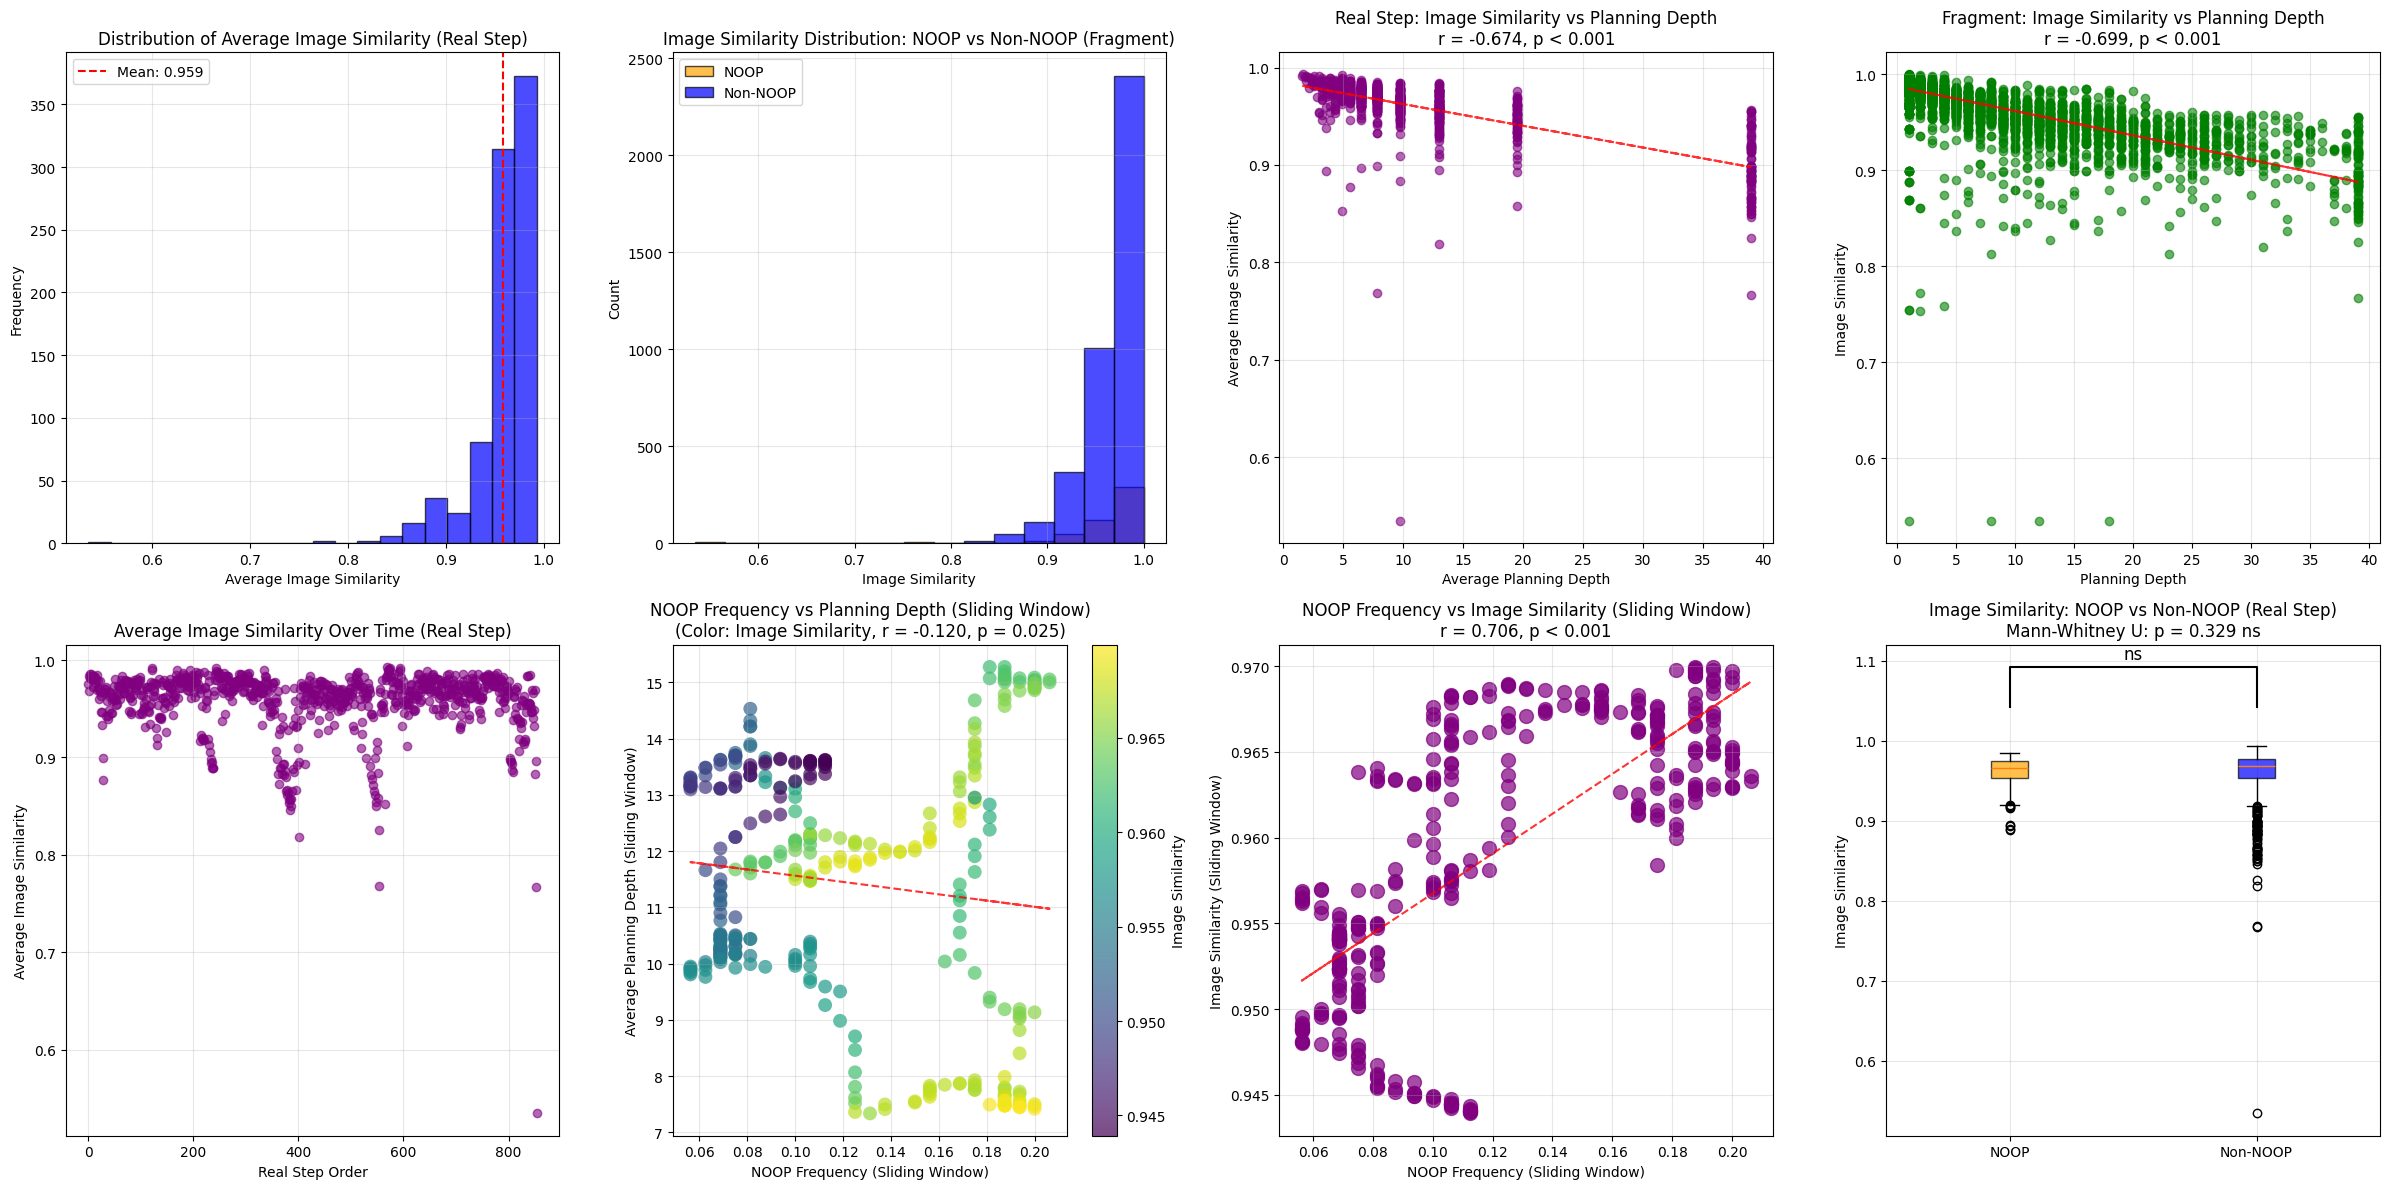

=== Imaginary Image Similarity Analysis ===
총 real step: 855
총 imagination fragment: 4443
유효한 fragment (유사도 계산 가능): 4443
평균 이미지 유사도 (Real step): 0.959 ± 0.033
평균 이미지 유사도 (Fragment): 0.968 ± 0.033
평균 fragment 길이: 7.51 ± 9.05

=== NOOP vs Non-NOOP Image Similarity (Fragment) ===
NOOP (n=477): 0.966 ± 0.053
Non-NOOP (n=3966): 0.969 ± 0.030
Mann-Whitney U: p = 0.329

=== Real Step: Image Similarity vs Planning Depth ===
Pearson correlation: r = -0.674, p < 0.001

=== Fragment: Image Similarity vs Planning Depth ===
Pearson correlation: r = -0.699, p < 0.001


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from skimage.metrics import structural_similarity as ssim
from scipy import stats  # 분산/상관 검정용 (상단으로 이동)

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# Utilities
# =========================

def format_p_value(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def compute_offsets(y_max, i, base_scale=0.08):
    base_offset = y_max * base_scale
    line_y = y_max + base_offset * (i + 1.5)
    text_y = line_y + base_offset * 0.6
    return line_y, text_y

def normalize_image_dimensions(img_data):
    """
    입력 이미지를 (H, W, C) uint8로 통일.
    (기존 함수와 동일 동작; 디버깅 프린트 유지)
    """
    img_array = np.array(img_data)
    print(f"Original shape: {img_array.shape}, dtype: {img_array.dtype}")

    # (C,H,W) -> (H,W,C)
    if img_array.ndim == 3:
        c, h, w = img_array.shape
        if c == 3 and h > 1 and w > 1:
            img_array = np.transpose(img_array, (1, 2, 0))
        elif h == 3 and w > 1:
            img_array = np.transpose(img_array, (0, 2, 1))

    # 4D -> squeeze
    if img_array.ndim == 4:
        if img_array.shape[0] == 1:
            img_array = img_array.squeeze(0)
        if img_array.ndim == 4 and img_array.shape[1] == 1:
            img_array = img_array.squeeze(1)

    # 3D 정상 케이스
    if img_array.ndim == 3:
        h, w, c = img_array.shape
        if h > 1 and w > 1 and c in [1, 3]:
            if img_array.dtype != np.uint8:
                if img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                else:
                    img_array = img_array.astype(np.uint8)
            if c == 1:
                img_array = np.repeat(img_array, 3, axis=-1)
            return img_array

    # 2D grayscale -> 3채널
    if img_array.ndim == 2:
        h, w = img_array.shape
        if h > 1 and w > 1:
            if img_array.dtype != np.uint8:
                if img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                else:
                    img_array = img_array.astype(np.uint8)
            return np.stack([img_array, img_array, img_array], axis=-1)

    raise ValueError(f"Cannot normalize image with shape {img_array.shape} and dtype {img_array.dtype}")

# =========================
# Similarity backends
# =========================

def _cosine_similarity_images(imaginary_imgs, real_imgs):
    """픽셀 평탄화 코사인(기존 기능 유지)."""
    if not imaginary_imgs or not real_imgs:
        return 0.0
    L = min(len(imaginary_imgs), len(real_imgs))
    sims = []
    for i in range(L):
        sim_matrix = cosine_similarity(
            [np.array(imaginary_imgs[i]).reshape(-1)],
            [np.array(real_imgs[i]).reshape(-1)]
        )
        sims.append(float(sim_matrix[0, 0]))
    return float(np.mean(sims)) if sims else 0.0

# =========================
# Extraction helpers
# =========================


SIM_BACKENDS = {
    "cosine": _cosine_similarity_images
}

def _get_real_indices(status):
    return [i for i, s in enumerate(status) if s == 0]

def _extract_imag_fragments_with_source(data, real_indices):
    """(fragment_imgs, source_real_idx) 리스트 반환."""
    status = data['status']
    im_imgs = data['im_vectors']
    out = []
    for pos, r_idx in enumerate(real_indices):
        start = r_idx + 1
        end = real_indices[pos + 1] if pos + 1 < len(real_indices) else len(status)
        cur = []
        for t in range(start, end):
            st = status[t]
            if st == 2 and t < len(im_imgs):
                cur.append(im_imgs[t])
            elif st in (1, 3):
                if cur:
                    out.append((cur, r_idx))
                    cur = []
        if cur:
            out.append((cur, r_idx))
    return out

def _extract_future_real_images(data, real_indices, start_real_order, max_length):
    """해당 real order 이후의 real 프레임들 max_length만큼 추출."""
    real_imgs = data['real_vectors']
    out = []
    for k in range(max_length):
        order = start_real_order + k
        if order < len(real_indices):
            r_idx = real_indices[order]
            if r_idx < len(real_imgs):
                out.append(real_imgs[r_idx])
    return out

def _get_next_real_action(data, real_indices, source_order):
    """다음 real step의 action index (없으면 -1)."""
    if source_order + 1 >= len(real_indices):
        return -1
    next_r = real_indices[source_order + 1]
    if next_r >= len(data['tree_reps']['cur_action']):
        return -1
    return int(np.argmax(data['tree_reps']['cur_action'][next_r]))

# =========================
# Main analysis
# =========================

def analyze_imaginary_image_similarity(data, similarity_mode="cosine"):
    """
    각 real step 근처 imagination fragment가 미래 real 이미지들과 얼마나 유사한지 계산.
    similarity_mode: {"cosine","ssim","clip"} (기본: 기존과 동일한 cosine)
    """
    status = data['status']
    real_indices = _get_real_indices(status)
    fragments_with_source = _extract_imag_fragments_with_source(data, real_indices)

    sim_fn = SIM_BACKENDS.get(similarity_mode, SIM_BACKENDS["cosine"])
    fragment_results = []

    # 미리 dict로 real_idx -> order 매핑(중복 탐색 제거)
    real_idx_to_order = {idx: o for o, idx in enumerate(real_indices)}

    for frag_imgs, src_ridx in fragments_with_source:
        if not frag_imgs:
            continue

        src_order = real_idx_to_order[src_ridx]
        label_action = _get_next_real_action(data, real_indices, src_order)

        # fragment 길이만큼 미래 real 이미지 수집
        real_images = _extract_future_real_images(
            data, real_indices, start_real_order=src_order + 1, max_length=len(frag_imgs)
        )

        if not real_images:
            fragment_results.append({
                'fragment_imgs': frag_imgs,
                'source_real_idx': src_ridx,
                'source_real_order': src_order,
                'label_action': label_action,
                'real_images': [],
                'predicted_real_steps': [],
                'similarity': np.nan,
                'fragment_length': len(frag_imgs),
                'real_length': 0
            })
            continue

        similarity = sim_fn(frag_imgs, real_images)

        # 예측 real step 인덱스 기록
        pred_steps = []
        for k in range(len(real_images)):
            if src_order + 1 + k < len(real_indices):
                pred_steps.append(real_indices[src_order + 1 + k])

        fragment_results.append({
            'fragment_imgs': frag_imgs,
            'source_real_idx': src_ridx,
            'source_real_order': src_order,
            'label_action': label_action,
            'real_images': real_images,
            'predicted_real_steps': pred_steps,
            'similarity': similarity,
            'fragment_length': len(frag_imgs),
            'real_length': len(real_images)
        })

    return fragment_results

# =========================
# Visualization
# =========================

def visualize_imaginary_image_similarity_analysis(fragment_results):
    if not fragment_results:
        print("분석할 데이터가 없습니다.")
        return

    # ---------- 배열/집계 사전 계산 ----------
    frag_sims = np.array([r['similarity'] for r in fragment_results], dtype=float)
    frag_actions = np.array([r.get('label_action', -1) for r in fragment_results], dtype=int)
    frag_lengths = np.array([r['fragment_length'] for r in fragment_results], dtype=int)
    src_orders = np.array([r['source_real_order'] for r in fragment_results], dtype=int)
    src_real_indices = np.array([r['source_real_idx'] for r in fragment_results], dtype=int)

    valid_mask = np.isfinite(frag_sims) & (frag_actions >= 0)
    valid_sims = frag_sims[valid_mask]
    valid_actions = frag_actions[valid_mask]
    valid_lengths = frag_lengths[valid_mask]
    valid_src_orders = src_orders[valid_mask]
    valid_src_real_indices = src_real_indices[valid_mask]

    # real step 기준 평균(sim, depth=fragment len)
    real_step_results = defaultdict(list)
    real_step_depths = defaultdict(list)
    for sim, flen, ridx in zip(valid_sims, valid_lengths, valid_src_real_indices):
        real_step_results[ridx].append(sim)
        real_step_depths[ridx].append(flen)

    ordered_keys = list(real_step_results.keys())
    avg_similarities = [np.mean(real_step_results[k]) for k in ordered_keys]
    avg_planning_depths = [np.mean(real_step_depths[k]) for k in ordered_keys]
    real_step_orders = list(range(len(ordered_keys)))

    # NOOP vs Non-NOOP
    noop_mask = valid_actions == 0
    nonnoop_mask = ~noop_mask
    noop_sims = valid_sims[noop_mask]
    nonnoop_sims = valid_sims[nonnoop_mask]

    # ---------- Plot ----------
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))

    # 1) 평균 유사도 분포(Real step)
    if len(avg_similarities):
        axes[0, 0].hist(avg_similarities, bins=20, alpha=0.7, color='blue', edgecolor='black')
        axes[0, 0].set_xlabel('Average Image Similarity')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Average Image Similarity (Real Step)')
        axes[0, 0].axvline(np.mean(avg_similarities), color='red', linestyle='--',
                           label=f'Mean: {np.mean(avg_similarities):.3f}')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    else:
        axes[0, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].set_title('Distribution of Average Image Similarity (Real Step)')

    # 2) NOOP vs Non-NOOP 분포
    if len(noop_sims) > 0 and len(nonnop_sims := nonnoop_sims) > 0:
        all_data = np.concatenate([noop_sims, nonnop_sims])
        bins = np.linspace(all_data.min(), all_data.max(), 16)
        axes[0, 1].hist(noop_sims, bins=bins, alpha=0.7, label='NOOP', color='orange', edgecolor='black')
        axes[0, 1].hist(nonnop_sims, bins=bins, alpha=0.7, label='Non-NOOP', color='blue', edgecolor='black')
        axes[0, 1].set_xlabel('Image Similarity')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Image Similarity Distribution: NOOP vs Non-NOOP (Fragment)')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'No NOOP data available', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Image Similarity Distribution: NOOP vs Non-NOOP (Fragment)')

    # 3) Real step: avg depth vs avg sim (상관)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        r, p = stats.pearsonr(avg_planning_depths, avg_similarities)
        axes[0, 2].scatter(avg_planning_depths, avg_similarities, alpha=0.6, color='purple')
        axes[0, 2].set_xlabel('Average Planning Depth')
        axes[0, 2].set_ylabel('Average Image Similarity')
        axes[0, 2].set_title(f'Real Step: Image Similarity vs Planning Depth\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 2].grid(True, alpha=0.3)
        if len(avg_similarities) > 1:
            z = np.polyfit(avg_planning_depths, avg_similarities, 1)
            pfit = np.poly1d(z)
            axes[0, 2].plot(avg_planning_depths, pfit(avg_planning_depths), "r--", alpha=0.8)
    else:
        axes[0, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('Real Step: Image Similarity vs Planning Depth')

    # 4) Fragment: length vs sim (상관)
    if len(valid_lengths) and len(valid_lengths) == len(valid_sims):
        r, p = stats.pearsonr(valid_lengths, valid_sims)
        axes[0, 3].scatter(valid_lengths, valid_sims, alpha=0.6, color='green')
        axes[0, 3].set_xlabel('Planning Depth')
        axes[0, 3].set_ylabel('Image Similarity')
        axes[0, 3].set_title(f'Fragment: Image Similarity vs Planning Depth\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 3].grid(True, alpha=0.3)
        if len(valid_sims) > 1:
            z = np.polyfit(valid_lengths, valid_sims, 1)
            pfit = np.poly1d(z)
            axes[0, 3].plot(valid_lengths, pfit(valid_lengths), "r--", alpha=0.8)
    else:
        axes[0, 3].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 3].transAxes)
        axes[0, 3].set_title('Fragment: Image Similarity vs Planning Depth')

    # 5) 평균 유사도 vs 시간(Real step 순서)
    if len(avg_similarities) and len(real_step_orders):
        axes[1, 0].scatter(real_step_orders, avg_similarities, alpha=0.6, color='purple')
        axes[1, 0].set_xlabel('Real Step Order')
        axes[1, 0].set_ylabel('Average Image Similarity')
        axes[1, 0].set_title('Average Image Similarity Over Time (Real Step)')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Average Image Similarity Over Time (Real Step)')

    # 6) NOOP freq vs avg depth (슬라이딩 윈도우, 색=avg sim)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        window_size, stride = 160, 2

        real_step_actions = []
        for ridx in ordered_keys:
            # 해당 real step의 action 찾기
            if ridx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][ridx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
        # real_idx -> (sims, action) 테이블로 바꿔두면 아래 반복이 단순해짐
        # real_idx_to_sims = real_step_results
        # real_idx_to_actions = defaultdict(list)
        #for a, s, ridx in zip(valid_actions, valid_sims, valid_src_real_indices):
        #     real_idx_to_actions[ridx].append(a)

        keys_in_order = ordered_keys  # dict 순서 의존 대신 위에서 만든 순서 사용
        window_noop_freq = []
        window_avg_depth = []
        window_avg_sim = []

        for i in range(0, len(keys_in_order) - window_size + 1, stride):
            w_keys = keys_in_order[i:i+window_size]
            window_actions = [real_step_actions[j] for j in range(i, i+window_size)]
            noop_count = np.sum(np.array(window_actions) == 0)
            noop_frequency = noop_count / window_size
            # fragment 기반 NOOP 비율(기존 로직 유지)
            # tot = 0
            # noop_cnt = 0
            # for k in w_keys:
            #     actions = real_idx_to_actions.get(k, [])
            #     sims_here = real_idx_to_sims.get(k, [])
            #     for a, s in zip(actions, sims_here):
            #         tot += 1  # 모든 fragment 포함
            #         if a == 0:
            #             noop_cnt += 1
            # if tot == 0:
            #     continue
            # window_noop_freq.append(noop_cnt / tot)
            window_noop_freq.append(noop_frequency)
            depth_vals = [np.mean(real_step_depths[k]) for k in w_keys if len(real_step_depths[k])]
            sim_vals = [np.mean(real_step_results[k]) for k in w_keys if len(real_step_results[k])]
            window_avg_depth.append(np.mean(depth_vals) if depth_vals else np.nan)
            window_avg_sim.append(np.mean(sim_vals) if sim_vals else np.nan)

        if window_noop_freq:
            # Real step 단위로 correlation 계산
            r, p = stats.pearsonr(window_noop_freq, window_avg_depth)
            scatter = axes[1, 1].scatter(window_noop_freq, window_avg_depth,
                                        c=window_avg_sim, cmap='viridis',
                                        s=100, alpha=0.7, edgecolors='none')
            axes[1, 1].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 1].set_ylabel('Average Planning Depth (Sliding Window)')
            axes[1, 1].set_title(f'NOOP Frequency vs Planning Depth (Sliding Window)\n'
                                f'(Color: Image Similarity, r = {r:.3f}, {format_p_value(p)})')
            axes[1, 1].grid(True, alpha=0.3)
            cbar = plt.colorbar(scatter, ax=axes[1, 1]); cbar.set_label('Image Similarity')

            if len(window_noop_freq) > 1:
                z = np.polyfit(window_noop_freq, window_avg_depth, 1)
                pfit = np.poly1d(z)
                axes[1, 1].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('NOOP Frequency vs Planning Depth (Sliding Window)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('NOOP Frequency vs Planning Depth (Sliding Window)')

    # 7) NOOP freq vs avg sim (슬라이딩 윈도우)
    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_sim2 = []
        
        # real step별 action 정보 준비 (6번 그래프에서 이미 준비했다면 재사용)
        real_step_actions = []
        for ridx in ordered_keys:
            if ridx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][ridx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
        
        for i in range(0, len(keys_in_order) - window_size + 1, stride):
            w_keys = keys_in_order[i:i+window_size]
            
            # real step 기반 NOOP 빈도 계산
            window_actions = [real_step_actions[j] for j in range(i, i+window_size)]
            noop_count = np.sum(np.array(window_actions) == 0)
            noop_frequency = noop_count / window_size
            
            # real step 단위 평균 similarity 계산
            sim_vals = [avg_similarities[j] for j in range(i, i+window_size)]
            window_avg_sim = np.mean(sim_vals)
            
            window_noop_freq.append(noop_frequency)
            window_avg_sim2.append(window_avg_sim)

        if window_noop_freq:
            # Real step 단위로 correlation 계산
            r, p = stats.pearsonr(window_noop_freq, window_avg_sim2)
            axes[1, 2].scatter(window_noop_freq, window_avg_sim2, alpha=0.7, color='purple', s=100)
            axes[1, 2].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 2].set_ylabel('Image Similarity (Sliding Window)')
            axes[1, 2].set_title(f'NOOP Frequency vs Image Similarity (Sliding Window)\n'
                                f'r = {r:.3f}, {format_p_value(p)}')
            axes[1, 2].grid(True, alpha=0.3)
            if len(window_noop_freq) > 1:
                z = np.polyfit(window_noop_freq, window_avg_sim2, 1)
                pfit = np.poly1d(z)
                axes[1, 2].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('NOOP Frequency vs Image Similarity (Sliding Window)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('NOOP Frequency vs Image Similarity (Sliding Window)')

    # 8) NOOP vs Non-NOOP Box-plot (Real step 단위로 수정)
    if len(avg_similarities) > 0:
        # real step별 action 정보 준비
        real_step_actions = []
        for ridx in ordered_keys:
            if ridx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][ridx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
        
        # real step 단위로 NOOP/Non-NOOP 분류
        noop_mask = np.array(real_step_actions) == 0
        nonnoop_mask = ~noop_mask
        
        noop_sims_real = [avg_similarities[i] for i in range(len(avg_similarities)) if noop_mask[i]]
        nonnoop_sims_real = [avg_similarities[i] for i in range(len(avg_similarities)) if nonnoop_mask[i]]
        
        if len(noop_sims_real) > 0 and len(nonnoop_sims_real) > 0:
            _, p_norm1 = stats.shapiro(noop_sims_real)
            _, p_norm2 = stats.shapiro(nonnoop_sims_real)
            _, p_lev = stats.levene(noop_sims_real, nonnoop_sims_real)
            if p_norm1 > 0.05 and p_norm2 > 0.05 and p_lev > 0.05:
                _, p_val = stats.ttest_ind(noop_sims_real, nonnoop_sims_real)
                test_name = "t-test"
            else:
                _, p_val = stats.mannwhitneyu(noop_sims_real, nonnoop_sims_real, alternative='two-sided')
                test_name = "Mann-Whitney U"

            signif = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            bp = axes[1, 3].boxplot([noop_sims_real, nonnoop_sims_real], labels=['NOOP', 'Non-NOOP'], patch_artist=True)
            for patch, col in zip(bp['boxes'], ['orange', 'blue']):
                patch.set_facecolor(col); patch.set_alpha(0.7)
            axes[1, 3].set_ylabel('Image Similarity')
            axes[1, 3].set_title(f'Image Similarity: NOOP vs Non-NOOP (Real Step)\n{test_name}: {format_p_value(p_val)} {signif}')
            axes[1, 3].grid(True, alpha=0.3)

            y_max = max(np.max(noop_sims_real), np.max(nonnoop_sims_real))
            y_off = y_max * 0.05
            line_y, text_y = y_max + y_off, y_max + y_off * 2.1
            axes[1, 3].plot([1, 1, 2, 2], [line_y, line_y + y_off, line_y + y_off, line_y], lw=1.5, c='black')
            axes[1, 3].text(1.5, text_y, signif, ha='center', va='bottom', fontsize=12)
        else:
            axes[1, 3].text(0.5, 0.5, 'No NOOP data available', ha='center', va='center', transform=axes[1, 3].transAxes)
            axes[1, 3].set_title('Image Similarity: NOOP vs Non-NOOP (Real Step)')
    else:
        axes[1, 3].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 3].transAxes)
        axes[1, 3].set_title('Image Similarity: NOOP vs Non-NOOP (Real Step)')

    plt.tight_layout()
    plt.show()

    # ---------- 텍스트 요약 ----------
    print("=== Imaginary Image Similarity Analysis ===")
    print(f"총 real step: {len(ordered_keys)}")
    print(f"총 imagination fragment: {len(fragment_results)}")
    print(f"유효한 fragment (유사도 계산 가능): {len(valid_sims)}")
    if len(avg_similarities):
        print(f"평균 이미지 유사도 (Real step): {np.mean(avg_similarities):.3f} ± {np.std(avg_similarities):.3f}")
    print(f"평균 이미지 유사도 (Fragment): {np.nanmean(frag_sims):.3f} ± {np.nanstd(frag_sims):.3f}")
    print(f"평균 fragment 길이: {np.mean(frag_lengths):.2f} ± {np.std(frag_lengths):.2f}")

    if len(noop_sims) > 0 and len(nonnop_sims) > 0:
        print("\n=== NOOP vs Non-NOOP Image Similarity (Fragment) ===")
        print(f"NOOP (n={len(noop_sims)}): {np.mean(noop_sims):.3f} ± {np.std(noop_sims):.3f}")
        print(f"Non-NOOP (n={len(nonnop_sims)}): {np.mean(nonnop_sims):.3f} ± {np.std(nonnop_sims):.3f}")
        print(f"{test_name}: {format_p_value(p_val)}")

    if len(avg_similarities) and len(avg_planning_depths) and len(avg_similarities) == len(avg_planning_depths):
        r, p = stats.pearsonr(avg_similarities, avg_planning_depths)
        print(f"\n=== Real Step: Image Similarity vs Planning Depth ===")
        print(f"Pearson correlation: r = {r:.3f}, {format_p_value(p)}")

    if len(valid_lengths) and len(valid_lengths) == len(valid_sims):
        r, p = stats.pearsonr(valid_lengths, valid_sims)
        print(f"\n=== Fragment: Image Similarity vs Planning Depth ===")
        print(f"Pearson correlation: r = {r:.3f}, {format_p_value(p)}")


# 사용 예시:
fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="cosine")
if fragment_results:
    visualize_imaginary_image_similarity_analysis(fragment_results)


calculate action diversity 

In [ ]:
# =========================
# Imagination Diversity Analysis
# =========================

def calculate_internal_diversity(action_sequence):
    """단일 fragment의 내부 diversity - Shannon Entropy"""
    if not action_sequence:
        return 0.0
    
    action_counts = np.bincount(action_sequence)
    action_probs = action_counts / len(action_sequence)
    entropy = -np.sum(action_probs * np.log2(action_probs + 1e-10))
    
    # 정규화: 최대 엔트로피로 나누기
    max_entropy = np.log2(len(set(action_sequence)))
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
    
    return normalized_entropy

def calculate_inter_fragment_diversity(fragment_actions_list):
    """여러 fragment 간의 diversity - Jaccard Distance 평균"""
    if len(fragment_actions_list) < 2:
        return 0.0
    
    action_sets = [set(actions) for actions in fragment_actions_list if actions]
    
    jaccard_distances = []
    for i in range(len(action_sets)):
        for j in range(i+1, len(action_sets)):
            intersection = len(action_sets[i] & action_sets[j])
            union = len(action_sets[i] | action_sets[j])
            jaccard_distance = 1 - (intersection / union) if union > 0 else 0
            jaccard_distances.append(jaccard_distance)
    
    return np.mean(jaccard_distances) if jaccard_distances else 0.0

def calculate_real_step_diversity(fragments):
    """하나의 real step에 대해 하나의 diversity 값 반환"""
    if not fragments:
        return 0.0
    
    if len(fragments) == 1:
        return calculate_internal_diversity(fragments[0])
    
    else:
        internal_diversities = [calculate_internal_diversity(f) for f in fragments]
        internal_avg = np.mean(internal_diversities)
        inter_diversity = calculate_inter_fragment_diversity(fragments)
        return (internal_avg + inter_diversity) / 2

def analyze_imagination_diversity_by_real_step(data):
    """각 real step별로 imagination diversity 계산"""
    status = data['status']
    real_indices = [i for i, s in enumerate(status) if s == 0]
    
    # Real step별 fragment action sequences 수집
    real_step_fragments = defaultdict(list)
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(data['tree_reps']['cur_action']):
                    action_onehot = data['tree_reps']['cur_action'][t]
                    action_idx = np.argmax(action_onehot)
                    current_fragment.append(action_idx)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # 각 real step별 diversity 계산
    diversity_by_real_step = {}
    for real_idx, fragments in real_step_fragments.items():
        diversity = calculate_real_step_diversity(fragments)
        diversity_by_real_step[real_idx] = diversity
    
    return diversity_by_real_step

def visualize_diversity_correlation_analysis(data):
    """Diversity와 다른 지표들 간의 상관관계 시각화"""
    
    # 1. Imagination diversity 계산
    diversity_results = analyze_imagination_diversity_by_real_step(data)
    
    # 2. 기존 분석 결과 가져오기
    fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="cosine")
    
    # 3. Real step별 데이터 준비
    status = data['status']
    real_indices = [i for i, s in enumerate(status) if s == 0]
    
    # Real step별 평균 similarity와 planning depth 계산
    real_step_similarities = defaultdict(list)
    real_step_depths = defaultdict(list)
    
    for result in fragment_results:
        real_idx = result['source_real_idx']
        if np.isfinite(result['similarity']):
            real_step_similarities[real_idx].append(result['similarity'])
        real_step_depths[real_idx].append(result['fragment_length'])
    
    # 평균값 계산
    avg_similarities = []
    avg_depths = []
    diversities = []
    real_step_actions = []
    
    for real_idx in real_indices:
        if real_idx in diversity_results:
            diversities.append(diversity_results[real_idx])
            
            # Similarity
            if real_idx in real_step_similarities:
                avg_similarities.append(np.mean(real_step_similarities[real_idx]))
            else:
                avg_similarities.append(np.nan)
            
            # Planning depth
            if real_idx in real_step_depths:
                avg_depths.append(np.mean(real_step_depths[real_idx]))
            else:
                avg_depths.append(np.nan)
            
            # Action
            if real_idx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][real_idx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
    
    # 유효한 데이터만 필터링
    valid_mask = np.isfinite(avg_similarities) & np.isfinite(avg_depths) & np.isfinite(diversities)
    valid_similarities = np.array(avg_similarities)[valid_mask]
    valid_depths = np.array(avg_depths)[valid_mask]
    valid_diversities = np.array(diversities)[valid_mask]
    valid_actions = np.array(real_step_actions)[valid_mask]
    
    # 4. Plot 생성
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # 1) Image Similarity vs Diversity
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        axes[0].scatter(valid_similarities, valid_diversities, alpha=0.6, color='blue')
        axes[0].set_xlabel('Image Similarity')
        axes[0].set_ylabel('Imagination Diversity')
        axes[0].set_title(f'Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0].grid(True, alpha=0.3)
        
        # 회귀선
        if len(valid_similarities) > 1:
            z = np.polyfit(valid_similarities, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0].plot(valid_similarities, pfit(valid_similarities), "r--", alpha=0.8)
    else:
        axes[0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Image Similarity vs Diversity')
    
    # 2) Planning Depth vs Diversity
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        axes[1].scatter(valid_depths, valid_diversities, alpha=0.6, color='green')
        axes[1].set_xlabel('Average Planning Depth')
        axes[1].set_ylabel('Imagination Diversity')
        axes[1].set_title(f'Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[1].grid(True, alpha=0.3)
        
        # 회귀선
        if len(valid_depths) > 1:
            z = np.polyfit(valid_depths, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[1].plot(valid_depths, pfit(valid_depths), "r--", alpha=0.8)
    else:
        axes[1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Planning Depth vs Diversity')
    
    # 3) Sliding Window: NOOP Frequency vs Diversity
    if len(valid_actions) > 0:
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_diversity = []
        
        for i in range(0, len(valid_actions) - window_size + 1, stride):
            window_actions = valid_actions[i:i+window_size]
            noop_count = np.sum(np.array(window_actions) == 0)
            noop_frequency = noop_count / window_size
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_noop_freq.append(noop_frequency)
            window_avg_diversity.append(avg_diversity)
        
        if len(window_noop_freq) > 1:
            r, p = stats.pearsonr(window_noop_freq, window_avg_diversity)
            axes[2].scatter(window_noop_freq, window_avg_diversity, alpha=0.7, color='orange', s=100)
            axes[2].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[2].set_ylabel('Average Diversity (Sliding Window)')
            axes[2].set_title(f'NOOP Frequency vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[2].grid(True, alpha=0.3)
            
            # 회귀선
            z = np.polyfit(window_noop_freq, window_avg_diversity, 1)
            pfit = np.poly1d(z)
            axes[2].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[2].transAxes)
            axes[2].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    else:
        axes[2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    
    # 4) Sliding Window: Planning Depth vs Diversity
    if len(valid_depths) > 0:
        window_size, stride = 160, 2
        window_avg_depth = []
        window_avg_diversity2 = []
        
        for i in range(0, len(valid_depths) - window_size + 1, stride):
            window_depths = valid_depths[i:i+window_size]
            avg_depth = np.mean(window_depths)
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_avg_depth.append(avg_depth)
            window_avg_diversity2.append(avg_diversity)
        
        if len(window_avg_depth) > 1:
            r, p = stats.pearsonr(window_avg_depth, window_avg_diversity2)
            axes[3].scatter(window_avg_depth, window_avg_diversity2, alpha=0.7, color='purple', s=100)
            axes[3].set_xlabel('Average Planning Depth (Sliding Window)')
            axes[3].set_ylabel('Average Diversity (Sliding Window)')
            axes[3].set_title(f'Planning Depth vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[3].grid(True, alpha=0.3)
            
            # 회귀선
            z = np.polyfit(window_avg_depth, window_avg_diversity2, 1)
            pfit = np.poly1d(z)
            axes[3].plot(window_avg_depth, pfit(window_avg_depth), "r--", alpha=0.8)
        else:
            axes[3].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[3].transAxes)
            axes[3].set_title('Planning Depth vs Diversity (Sliding Window)')
    else:
        axes[3].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[3].transAxes)
        axes[3].set_title('Planning Depth vs Diversity (Sliding Window)')
    
    plt.tight_layout()
    plt.show()
    
    # 텍스트 요약
    print("=== Imagination Diversity Correlation Analysis ===")
    print(f"총 real step: {len(real_indices)}")
    print(f"유효한 real step: {len(valid_diversities)}")
    print(f"평균 imagination diversity: {np.mean(valid_diversities):.3f} ± {np.std(valid_diversities):.3f}")
    
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        print(f"\nImage Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        print(f"Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")

# 사용 예시:
visualize_diversity_correlation_analysis(data)

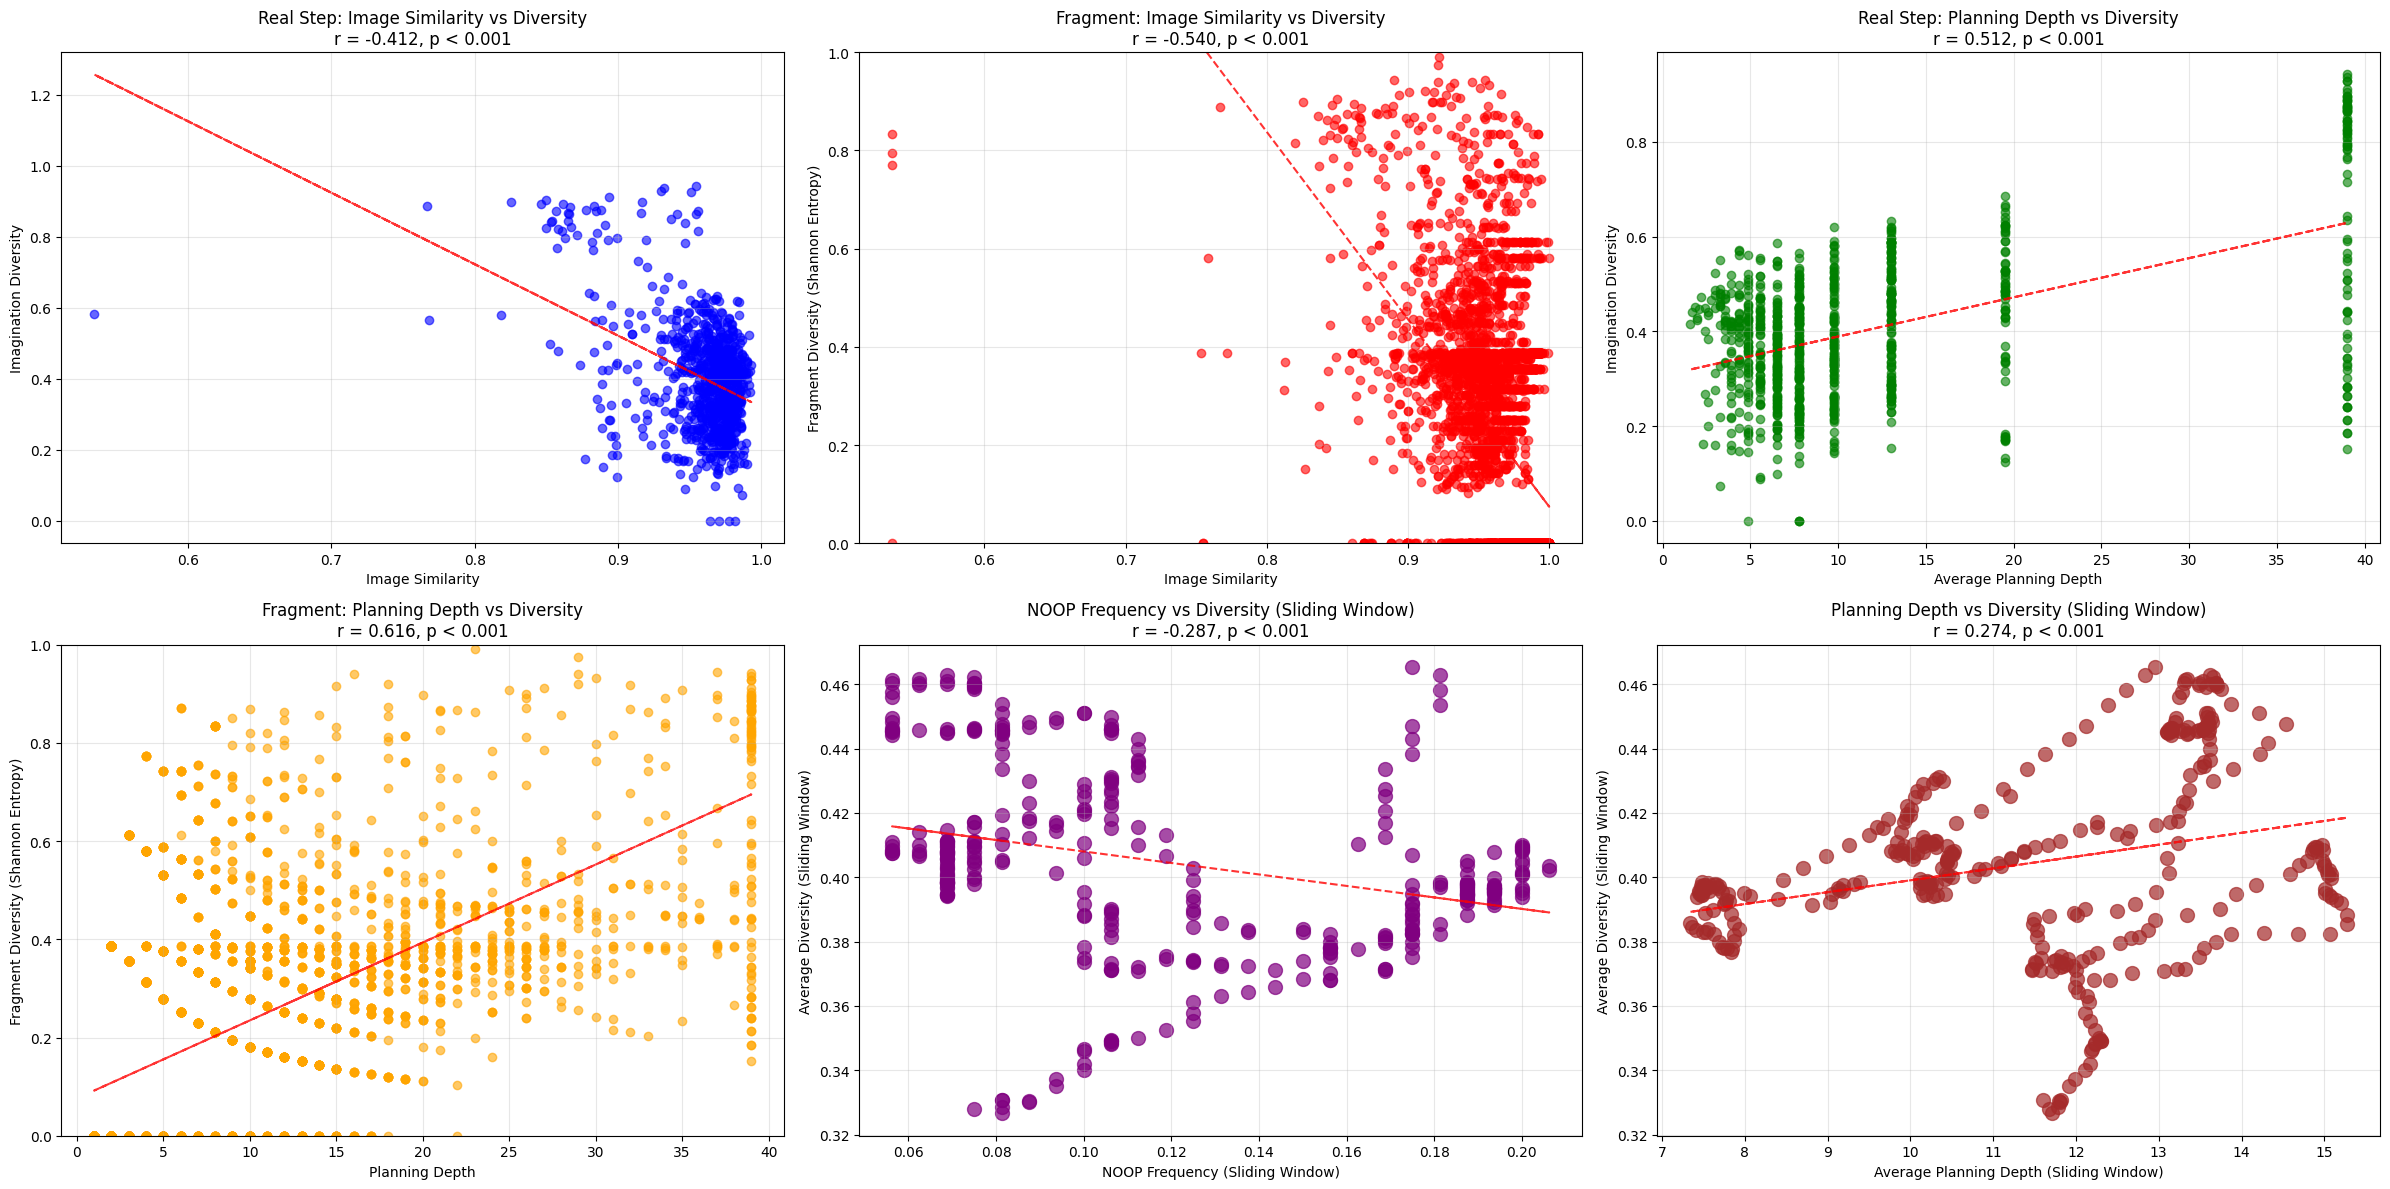

=== Imagination Diversity Correlation Analysis ===
Action 개수: 6
총 real step: 856
유효한 real step: 855
총 fragment: 4443
유효한 fragment: 4443
평균 real step diversity: 0.404 ± 0.160
평균 fragment diversity: 0.195 ± 0.233

Real Step - Image Similarity vs Diversity: r = -0.412, p < 0.001
Fragment - Image Similarity vs Diversity: r = -0.540, p < 0.001
Real Step - Planning Depth vs Diversity: r = 0.512, p < 0.001
Fragment - Planning Depth vs Diversity: r = 0.616, p < 0.001


In [20]:
def calculate_internal_diversity(action_sequence, num_actions=6):
    """단일 fragment의 내부 diversity - Shannon Entropy (최대 엔트로피로 정규화)"""
    if not action_sequence:
        return 0.0
    
    action_counts = np.bincount(action_sequence, minlength=num_actions)
    action_probs = action_counts / len(action_sequence)
    entropy = -np.sum(action_probs * np.log2(action_probs + 1e-10))
    
    # 정규화: 전체 가능한 action 개수 기준으로 최대 엔트로피로 나누기
    max_entropy = np.log2(num_actions)
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
    
    return normalized_entropy

def calculate_inter_fragment_diversity(fragment_actions_list):
    """여러 fragment 간의 diversity - Jaccard Distance 평균"""
    if len(fragment_actions_list) < 2:
        return 0.0
    
    action_sets = [set(actions) for actions in fragment_actions_list if actions]
    
    jaccard_distances = []
    for i in range(len(action_sets)):
        for j in range(i+1, len(action_sets)):
            intersection = len(action_sets[i] & action_sets[j])
            union = len(action_sets[i] | action_sets[j])
            jaccard_distance = 1 - (intersection / union) if union > 0 else 0
            jaccard_distances.append(jaccard_distance)
    
    return np.mean(jaccard_distances) if jaccard_distances else 0.0

def calculate_real_step_diversity(fragments, num_actions=6):
    """하나의 real step에 대해 하나의 diversity 값 반환"""
    if not fragments:
        return 0.0
    
    if len(fragments) == 1:
        return calculate_internal_diversity(fragments[0], num_actions)
    
    else:
        internal_diversities = [calculate_internal_diversity(f, num_actions) for f in fragments]
        internal_avg = np.mean(internal_diversities)
        inter_diversity = calculate_inter_fragment_diversity(fragments)
        return (internal_avg + inter_diversity) / 2

def analyze_imagination_diversity_by_real_step(data):
    """각 real step별로 imagination diversity 계산"""
    status = data['status']
    real_indices = [i for i, s in enumerate(status) if s == 0]
    
    # Action 개수 확인
    num_actions = 6  # 기본값
    if 'tree_reps' in data and 'cur_action' in data['tree_reps']:
        action_data = data['tree_reps']['cur_action']
        if len(action_data) > 0:
            num_actions = action_data[0].shape[0]
    
    # Real step별 fragment action sequences 수집
    real_step_fragments = defaultdict(list)
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(data['tree_reps']['cur_action']):
                    action_onehot = data['tree_reps']['cur_action'][t]
                    action_idx = np.argmax(action_onehot)
                    current_fragment.append(action_idx)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # 각 real step별 diversity 계산
    diversity_by_real_step = {}
    for real_idx, fragments in real_step_fragments.items():
        diversity = calculate_real_step_diversity(fragments, num_actions)
        diversity_by_real_step[real_idx] = diversity
    
    return diversity_by_real_step

def visualize_diversity_correlation_analysis(data):
    """Diversity와 다른 지표들 간의 상관관계 시각화 (6개 그래프)"""
    
    # Action 개수 확인
    num_actions = 6  # 기본값
    if 'tree_reps' in data and 'cur_action' in data['tree_reps']:
        action_data = data['tree_reps']['cur_action']
        if len(action_data) > 0:
            num_actions = action_data[0].shape[0]
    
    # 1. Imagination diversity 계산
    diversity_results = analyze_imagination_diversity_by_real_step(data)
    
    # 2. 기존 분석 결과 가져오기
    fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="cosine")
    
    # 3. Real step별 데이터 준비
    status = data['status']
    real_indices = [i for i, s in enumerate(status) if s == 0]
    
    # Real step별 평균 similarity와 planning depth 계산
    real_step_similarities = defaultdict(list)
    real_step_depths = defaultdict(list)
    
    for result in fragment_results:
        real_idx = result['source_real_idx']
        if np.isfinite(result['similarity']):
            real_step_similarities[real_idx].append(result['similarity'])
        real_step_depths[real_idx].append(result['fragment_length'])
    
    # 평균값 계산
    avg_similarities = []
    avg_depths = []
    diversities = []
    real_step_actions = []
    
    for real_idx in real_indices:
        if real_idx in diversity_results:
            diversities.append(diversity_results[real_idx])
            
            # Similarity
            if real_idx in real_step_similarities:
                avg_similarities.append(np.mean(real_step_similarities[real_idx]))
            else:
                avg_similarities.append(np.nan)
            
            # Planning depth
            if real_idx in real_step_depths:
                avg_depths.append(np.mean(real_step_depths[real_idx]))
            else:
                avg_depths.append(np.nan)
            
            # Action
            if real_idx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][real_idx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
    
    # 유효한 데이터만 필터링
    valid_mask = np.isfinite(avg_similarities) & np.isfinite(avg_depths) & np.isfinite(diversities)
    valid_similarities = np.array(avg_similarities)[valid_mask]
    valid_depths = np.array(avg_depths)[valid_mask]
    valid_diversities = np.array(diversities)[valid_mask]
    valid_actions = np.array(real_step_actions)[valid_mask]
    
    # 4. Fragment 단위 데이터 준비 (수정된 부분)
    fragment_similarities = []
    fragment_depths = []
    fragment_diversities = []
    
    # Real step별 fragment action sequences 수집 (기존 함수 재활용)
    real_step_fragments = defaultdict(list)
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(data['tree_reps']['cur_action']):
                    action_onehot = data['tree_reps']['cur_action'][t]
                    action_idx = np.argmax(action_onehot)
                    current_fragment.append(action_idx)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # Fragment 단위 데이터 추출
    for result in fragment_results:
        if np.isfinite(result['similarity']):
            fragment_similarities.append(result['similarity'])
            fragment_depths.append(result['fragment_length'])
            
            # 해당 fragment의 action sequence 찾기
            real_idx = result['source_real_idx']
            fragment_length = result['fragment_length']
            
            # 해당 real step의 fragment들 중에서 길이가 맞는 것 찾기
            fragment_actions = None
            if real_idx in real_step_fragments:
                for fragment in real_step_fragments[real_idx]:
                    if len(fragment) == fragment_length:
                        fragment_actions = fragment
                        break
            
            # Shannon Entropy 계산 (최대 엔트로피로 정규화)
            if fragment_actions:
                diversity = calculate_internal_diversity(fragment_actions, num_actions)
                fragment_diversities.append(diversity)
            else:
                fragment_diversities.append(0.0)
    
    # 5. Plot 생성 (6개 그래프)
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    
    # 1) Real Step: Image Similarity vs Diversity
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        axes[0, 0].scatter(valid_similarities, valid_diversities, alpha=0.6, color='blue')
        axes[0, 0].set_xlabel('Image Similarity')
        axes[0, 0].set_ylabel('Imagination Diversity')
        axes[0, 0].set_title(f'Real Step: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 0].grid(True, alpha=0.3)
        
        if len(valid_similarities) > 1:
            z = np.polyfit(valid_similarities, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 0].plot(valid_similarities, pfit(valid_similarities), "r--", alpha=0.8)
    else:
        axes[0, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].set_title('Real Step: Image Similarity vs Diversity')
    
    # 2) Fragment: Image Similarity vs Diversity (Shannon Entropy만)
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        axes[0, 1].scatter(fragment_similarities, fragment_diversities, alpha=0.6, color='red')
        axes[0, 1].set_xlabel('Image Similarity')
        axes[0, 1].set_ylabel('Fragment Diversity (Shannon Entropy)')
        axes[0, 1].set_title(f'Fragment: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 1].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[0, 1].grid(True, alpha=0.3)
        
        if len(fragment_similarities) > 1:
            z = np.polyfit(fragment_similarities, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 1].plot(fragment_similarities, pfit(fragment_similarities), "r--", alpha=0.8)
    else:
        axes[0, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Fragment: Image Similarity vs Diversity')
        axes[0, 1].set_ylim(0, 1.0)
    
    # 3) Real Step: Planning Depth vs Diversity
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        axes[0, 2].scatter(valid_depths, valid_diversities, alpha=0.6, color='green')
        axes[0, 2].set_xlabel('Average Planning Depth')
        axes[0, 2].set_ylabel('Imagination Diversity')
        axes[0, 2].set_title(f'Real Step: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 2].grid(True, alpha=0.3)
        
        if len(valid_depths) > 1:
            z = np.polyfit(valid_depths, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 2].plot(valid_depths, pfit(valid_depths), "r--", alpha=0.8)
    else:
        axes[0, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('Real Step: Planning Depth vs Diversity')
    
    # 4) Fragment: Planning Depth vs Diversity (Shannon Entropy만)
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        axes[1, 0].scatter(fragment_depths, fragment_diversities, alpha=0.6, color='orange')
        axes[1, 0].set_xlabel('Planning Depth')
        axes[1, 0].set_ylabel('Fragment Diversity (Shannon Entropy)')
        axes[1, 0].set_title(f'Fragment: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[1, 0].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[1, 0].grid(True, alpha=0.3)
        
        if len(fragment_depths) > 1:
            z = np.polyfit(fragment_depths, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[1, 0].plot(fragment_depths, pfit(fragment_depths), "r--", alpha=0.8)
    else:
        axes[1, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Fragment: Planning Depth vs Diversity')
        axes[1, 0].set_ylim(0, 1.0)
    
    # 5) Sliding Window: NOOP Frequency vs Diversity
    if len(valid_actions) > 0:
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_diversity = []
        
        for i in range(0, len(valid_actions) - window_size + 1, stride):
            window_actions = valid_actions[i:i+window_size]
            noop_count = np.sum(np.array(window_actions) == 0)
            noop_frequency = noop_count / window_size
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_noop_freq.append(noop_frequency)
            window_avg_diversity.append(avg_diversity)
        
        if len(window_noop_freq) > 1:
            r, p = stats.pearsonr(window_noop_freq, window_avg_diversity)
            axes[1, 1].scatter(window_noop_freq, window_avg_diversity, alpha=0.7, color='purple', s=100)
            axes[1, 1].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 1].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 1].set_title(f'NOOP Frequency vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 1].grid(True, alpha=0.3)
            
            z = np.polyfit(window_noop_freq, window_avg_diversity, 1)
            pfit = np.poly1d(z)
            axes[1, 1].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    
    # 6) Sliding Window: Planning Depth vs Diversity
    if len(valid_depths) > 0:
        window_size, stride = 160, 2
        window_avg_depth = []
        window_avg_diversity2 = []
        
        for i in range(0, len(valid_depths) - window_size + 1, stride):
            window_depths = valid_depths[i:i+window_size]
            avg_depth = np.mean(window_depths)
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_avg_depth.append(avg_depth)
            window_avg_diversity2.append(avg_diversity)
        
        if len(window_avg_depth) > 1:
            r, p = stats.pearsonr(window_avg_depth, window_avg_diversity2)
            axes[1, 2].scatter(window_avg_depth, window_avg_diversity2, alpha=0.7, color='brown', s=100)
            axes[1, 2].set_xlabel('Average Planning Depth (Sliding Window)')
            axes[1, 2].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 2].set_title(f'Planning Depth vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 2].grid(True, alpha=0.3)
            
            z = np.polyfit(window_avg_depth, window_avg_diversity2, 1)
            pfit = np.poly1d(z)
            axes[1, 2].plot(window_avg_depth, pfit(window_avg_depth), "r--", alpha=0.8)
        else:
            axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    
    plt.tight_layout()
    plt.show()
    
    # 텍스트 요약
    print("=== Imagination Diversity Correlation Analysis ===")
    print(f"Action 개수: {num_actions}")
    print(f"총 real step: {len(real_indices)}")
    print(f"유효한 real step: {len(valid_diversities)}")
    print(f"총 fragment: {len(fragment_results)}")
    print(f"유효한 fragment: {len(fragment_diversities)}")
    print(f"평균 real step diversity: {np.mean(valid_diversities):.3f} ± {np.std(valid_diversities):.3f}")
    print(f"평균 fragment diversity: {np.mean(fragment_diversities):.3f} ± {np.std(fragment_diversities):.3f}")
    
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        print(f"\nReal Step - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        print(f"Fragment - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        print(f"Real Step - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        print(f"Fragment - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")

# 사용 예시:
visualize_diversity_correlation_analysis(data)

compare imagination diversity

In [ ]:
def calculate_internal_vector_diversity(srn_vectors):
    """단일 fragment의 내부 diversity - Vector Variance (0-1 정규화)"""
    if len(srn_vectors) < 2:
        return 0.0
    
    # 벡터들을 numpy array로 변환
    vectors = np.array(srn_vectors)
    
    # 각 벡터를 L2 정규화 (0으로 나누기 방지)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    # norm이 0인 경우 1로 설정하여 나누기 방지
    norms = np.where(norms < 1e-10, 1.0, norms)
    normalized_vectors = vectors / norms
    
    # 벡터 간 cosine distance의 분산 계산
    cosine_distances = []
    for i in range(len(normalized_vectors)):
        for j in range(i+1, len(normalized_vectors)):
            cosine_sim = np.dot(normalized_vectors[i], normalized_vectors[j])
            cosine_distance = 1 - cosine_sim
            cosine_distances.append(cosine_distance)
    
    # 분산을 0-1 범위로 정규화 (cosine distance는 0-2 범위)
    variance = np.var(cosine_distances) if cosine_distances else 0.0
    normalized_variance = variance / 4.0  # 최대 분산으로 정규화
    
    return min(normalized_variance, 1.0)  # 1을 넘지 않도록 제한

def calculate_inter_fragment_vector_diversity(fragment_vectors_list):
    """여러 fragment 간의 diversity - Silhouette Score (0-1 정규화)"""
    if len(fragment_vectors_list) < 2:
        return 0.0
    
    # 모든 벡터를 하나의 배열로 합치고 fragment별 라벨 생성
    all_vectors = []
    fragment_labels = []
    
    for i, vectors in enumerate(fragment_vectors_list):
        if vectors:
            all_vectors.extend(vectors)
            fragment_labels.extend([i] * len(vectors))
    
    if len(all_vectors) < 3:
        return 0.0
    
    # numpy array로 변환
    all_vectors = np.array(all_vectors)
    fragment_labels = np.array(fragment_labels)
    
    # 각 벡터를 L2 정규화 (0으로 나누기 방지)
    norms = np.linalg.norm(all_vectors, axis=1, keepdims=True)
    # norm이 0인 경우 1로 설정하여 나누기 방지
    norms = np.where(norms < 1e-10, 1.0, norms)
    normalized_vectors = all_vectors / norms
    
    # Silhouette score 계산
    from sklearn.metrics import silhouette_score
    try:
        silhouette_avg = silhouette_score(normalized_vectors, fragment_labels, metric='cosine')
        # Silhouette score는 -1에서 1 범위이므로 0-1로 정규화
        normalized_silhouette = (silhouette_avg + 1) / 2
        return max(0.0, min(normalized_silhouette, 1.0))  # 0-1 범위로 제한
    except:
        return 0.0

def calculate_real_step_vector_diversity(fragments):
    """하나의 real step에 대해 하나의 diversity 값 반환"""
    if not fragments:
        return 0.0
    
    if len(fragments) == 1:
        return calculate_internal_vector_diversity(fragments[0])
    
    else:
        internal_diversities = [calculate_internal_vector_diversity(f) for f in fragments]
        internal_avg = np.mean(internal_diversities)
        inter_diversity = calculate_inter_fragment_vector_diversity(fragments)
        return (internal_avg + inter_diversity) / 2

def analyze_imagination_diversity_by_real_step(data):
    """각 real step별로 imagination diversity 계산 (SRN encoding vector 기반)"""
    status = data['status']
    real_indices = [i for i, s in enumerate(status) if s == 0]
    
    # Real step별 fragment SRN encoding vectors 수집
    real_step_fragments = defaultdict(list)
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(data['im_vectors']):
                    srn_vector = data['im_vectors'][t]
                    current_fragment.append(srn_vector)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # 각 real step별 diversity 계산
    diversity_by_real_step = {}
    for real_idx, fragments in real_step_fragments.items():
        diversity = calculate_real_step_vector_diversity(fragments)
        diversity_by_real_step[real_idx] = diversity
    
    return diversity_by_real_step

def visualize_diversity_correlation_analysis(data):
    """Diversity와 다른 지표들 간의 상관관계 시각화 (6개 그래프)"""
    
    # 1. Imagination diversity 계산 (SRN encoding vector 기반)
    diversity_results = analyze_imagination_diversity_by_real_step(data)
    
    # 2. 기존 분석 결과 가져오기
    fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="cosine")
    
    # 3. Real step별 데이터 준비
    status = data['status']
    real_indices = [i for i, s in enumerate(status) if s == 0]
    
    # Real step별 평균 similarity와 planning depth 계산
    real_step_similarities = defaultdict(list)
    real_step_depths = defaultdict(list)
    
    for result in fragment_results:
        real_idx = result['source_real_idx']
        if np.isfinite(result['similarity']):
            real_step_similarities[real_idx].append(result['similarity'])
        real_step_depths[real_idx].append(result['fragment_length'])
    
    # 평균값 계산
    avg_similarities = []
    avg_depths = []
    diversities = []
    real_step_actions = []
    
    for real_idx in real_indices:
        if real_idx in diversity_results:
            diversities.append(diversity_results[real_idx])
            
            # Similarity
            if real_idx in real_step_similarities:
                avg_similarities.append(np.mean(real_step_similarities[real_idx]))
            else:
                avg_similarities.append(np.nan)
            
            # Planning depth
            if real_idx in real_step_depths:
                avg_depths.append(np.mean(real_step_depths[real_idx]))
            else:
                avg_depths.append(np.nan)
            
            # Action
            if real_idx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][real_idx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
    
    # 유효한 데이터만 필터링
    valid_mask = np.isfinite(avg_similarities) & np.isfinite(avg_depths) & np.isfinite(diversities)
    valid_similarities = np.array(avg_similarities)[valid_mask]
    valid_depths = np.array(avg_depths)[valid_mask]
    valid_diversities = np.array(diversities)[valid_mask]
    valid_actions = np.array(real_step_actions)[valid_mask]
    
    # 4. Fragment 단위 데이터 준비
    fragment_similarities = []
    fragment_depths = []
    fragment_diversities = []
    
    # Real step별 fragment SRN encoding vectors 수집
    real_step_fragments = defaultdict(list)
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(data['im_vectors']):
                    srn_vector = data['im_vectors'][t]
                    current_fragment.append(srn_vector)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # Fragment 단위 데이터 추출
    for result in fragment_results:
        if np.isfinite(result['similarity']):
            fragment_similarities.append(result['similarity'])
            fragment_depths.append(result['fragment_length'])
            
            # 해당 fragment의 SRN encoding vectors 찾기
            real_idx = result['source_real_idx']
            fragment_length = result['fragment_length']
            
            # 해당 real step의 fragment들 중에서 길이가 맞는 것 찾기
            fragment_vectors = None
            if real_idx in real_step_fragments:
                for fragment in real_step_fragments[real_idx]:
                    if len(fragment) == fragment_length:
                        fragment_vectors = fragment
                        break
            
            # Vector variance 계산
            if fragment_vectors:
                diversity = calculate_internal_vector_diversity(fragment_vectors)
                fragment_diversities.append(diversity)
            else:
                fragment_diversities.append(0.0)
    
    # 5. Plot 생성 (6개 그래프)
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    
    # 1) Real Step: Image Similarity vs Diversity
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        axes[0, 0].scatter(valid_similarities, valid_diversities, alpha=0.6, color='blue')
        axes[0, 0].set_xlabel('Image Similarity')
        axes[0, 0].set_ylabel('Imagination Diversity (SRN Vector)')
        axes[0, 0].set_title(f'Real Step: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 0].grid(True, alpha=0.3)
        
        if len(valid_similarities) > 1:
            z = np.polyfit(valid_similarities, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 0].plot(valid_similarities, pfit(valid_similarities), "r--", alpha=0.8)
    else:
        axes[0, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].set_title('Real Step: Image Similarity vs Diversity')
    
    # 2) Fragment: Image Similarity vs Diversity (Vector Variance만)
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        axes[0, 1].scatter(fragment_similarities, fragment_diversities, alpha=0.6, color='red')
        axes[0, 1].set_xlabel('Image Similarity')
        axes[0, 1].set_ylabel('Fragment Diversity (Vector Variance)')
        axes[0, 1].set_title(f'Fragment: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 1].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[0, 1].grid(True, alpha=0.3)
        
        if len(fragment_similarities) > 1:
            z = np.polyfit(fragment_similarities, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 1].plot(fragment_similarities, pfit(fragment_similarities), "r--", alpha=0.8)
    else:
        axes[0, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Fragment: Image Similarity vs Diversity')
        axes[0, 1].set_ylim(0, 1.0)
    
    # 3) Real Step: Planning Depth vs Diversity
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        axes[0, 2].scatter(valid_depths, valid_diversities, alpha=0.6, color='green')
        axes[0, 2].set_xlabel('Average Planning Depth')
        axes[0, 2].set_ylabel('Imagination Diversity (SRN Vector)')
        axes[0, 2].set_title(f'Real Step: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 2].grid(True, alpha=0.3)
        
        if len(valid_depths) > 1:
            z = np.polyfit(valid_depths, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 2].plot(valid_depths, pfit(valid_depths), "r--", alpha=0.8)
    else:
        axes[0, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('Real Step: Planning Depth vs Diversity')
    
    # 4) Fragment: Planning Depth vs Diversity (Vector Variance만)
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        axes[1, 0].scatter(fragment_depths, fragment_diversities, alpha=0.6, color='orange')
        axes[1, 0].set_xlabel('Planning Depth')
        axes[1, 0].set_ylabel('Fragment Diversity (Vector Variance)')
        axes[1, 0].set_title(f'Fragment: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[1, 0].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[1, 0].grid(True, alpha=0.3)
        
        if len(fragment_depths) > 1:
            z = np.polyfit(fragment_depths, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[1, 0].plot(fragment_depths, pfit(fragment_depths), "r--", alpha=0.8)
    else:
        axes[1, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Fragment: Planning Depth vs Diversity')
        axes[1, 0].set_ylim(0, 1.0)
    
    # 5) Sliding Window: NOOP Frequency vs Diversity
    if len(valid_actions) > 0:
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_diversity = []
        
        for i in range(0, len(valid_actions) - window_size + 1, stride):
            window_actions = valid_actions[i:i+window_size]
            noop_count = np.sum(np.array(window_actions) == 0)
            noop_frequency = noop_count / window_size
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_noop_freq.append(noop_frequency)
            window_avg_diversity.append(avg_diversity)
        
        if len(window_noop_freq) > 1:
            r, p = stats.pearsonr(window_noop_freq, window_avg_diversity)
            axes[1, 1].scatter(window_noop_freq, window_avg_diversity, alpha=0.7, color='purple', s=100)
            axes[1, 1].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 1].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 1].set_title(f'NOOP Frequency vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 1].grid(True, alpha=0.3)
            
            z = np.polyfit(window_noop_freq, window_avg_diversity, 1)
            pfit = np.poly1d(z)
            axes[1, 1].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    
    # 6) Sliding Window: Planning Depth vs Diversity
    if len(valid_depths) > 0:
        window_size, stride = 160, 2
        window_avg_depth = []
        window_avg_diversity2 = []
        
        for i in range(0, len(valid_depths) - window_size + 1, stride):
            window_depths = valid_depths[i:i+window_size]
            avg_depth = np.mean(window_depths)
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_avg_depth.append(avg_depth)
            window_avg_diversity2.append(avg_diversity)
        
        if len(window_avg_depth) > 1:
            r, p = stats.pearsonr(window_avg_depth, window_avg_diversity2)
            axes[1, 2].scatter(window_avg_depth, window_avg_diversity2, alpha=0.7, color='brown', s=100)
            axes[1, 2].set_xlabel('Average Planning Depth (Sliding Window)')
            axes[1, 2].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 2].set_title(f'Planning Depth vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 2].grid(True, alpha=0.3)
            
            z = np.polyfit(window_avg_depth, window_avg_diversity2, 1)
            pfit = np.poly1d(z)
            axes[1, 2].plot(window_avg_depth, pfit(window_avg_depth), "r--", alpha=0.8)
        else:
            axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    
    plt.tight_layout()
    plt.show()
    
    # 텍스트 요약
    print("=== Imagination Diversity Correlation Analysis (SRN Vector) ===")
    print(f"총 real step: {len(real_indices)}")
    print(f"유효한 real step: {len(valid_diversities)}")
    print(f"총 fragment: {len(fragment_results)}")
    print(f"유효한 fragment: {len(fragment_diversities)}")
    print(f"평균 real step diversity: {np.mean(valid_diversities):.3f} ± {np.std(valid_diversities):.3f}")
    print(f"평균 fragment diversity: {np.mean(fragment_diversities):.3f} ± {np.std(fragment_diversities):.3f}")
    
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        print(f"\nReal Step - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        print(f"Fragment - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        print(f"Real Step - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        print(f"Fragment - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")

# 사용 예시:
visualize_diversity_correlation_analysis(data)

최적화된 diversity 계산 함수 로드 완료!
✅ 기존과 동일한 결과 보장
⚡ 큰 데이터에서 성능 향상


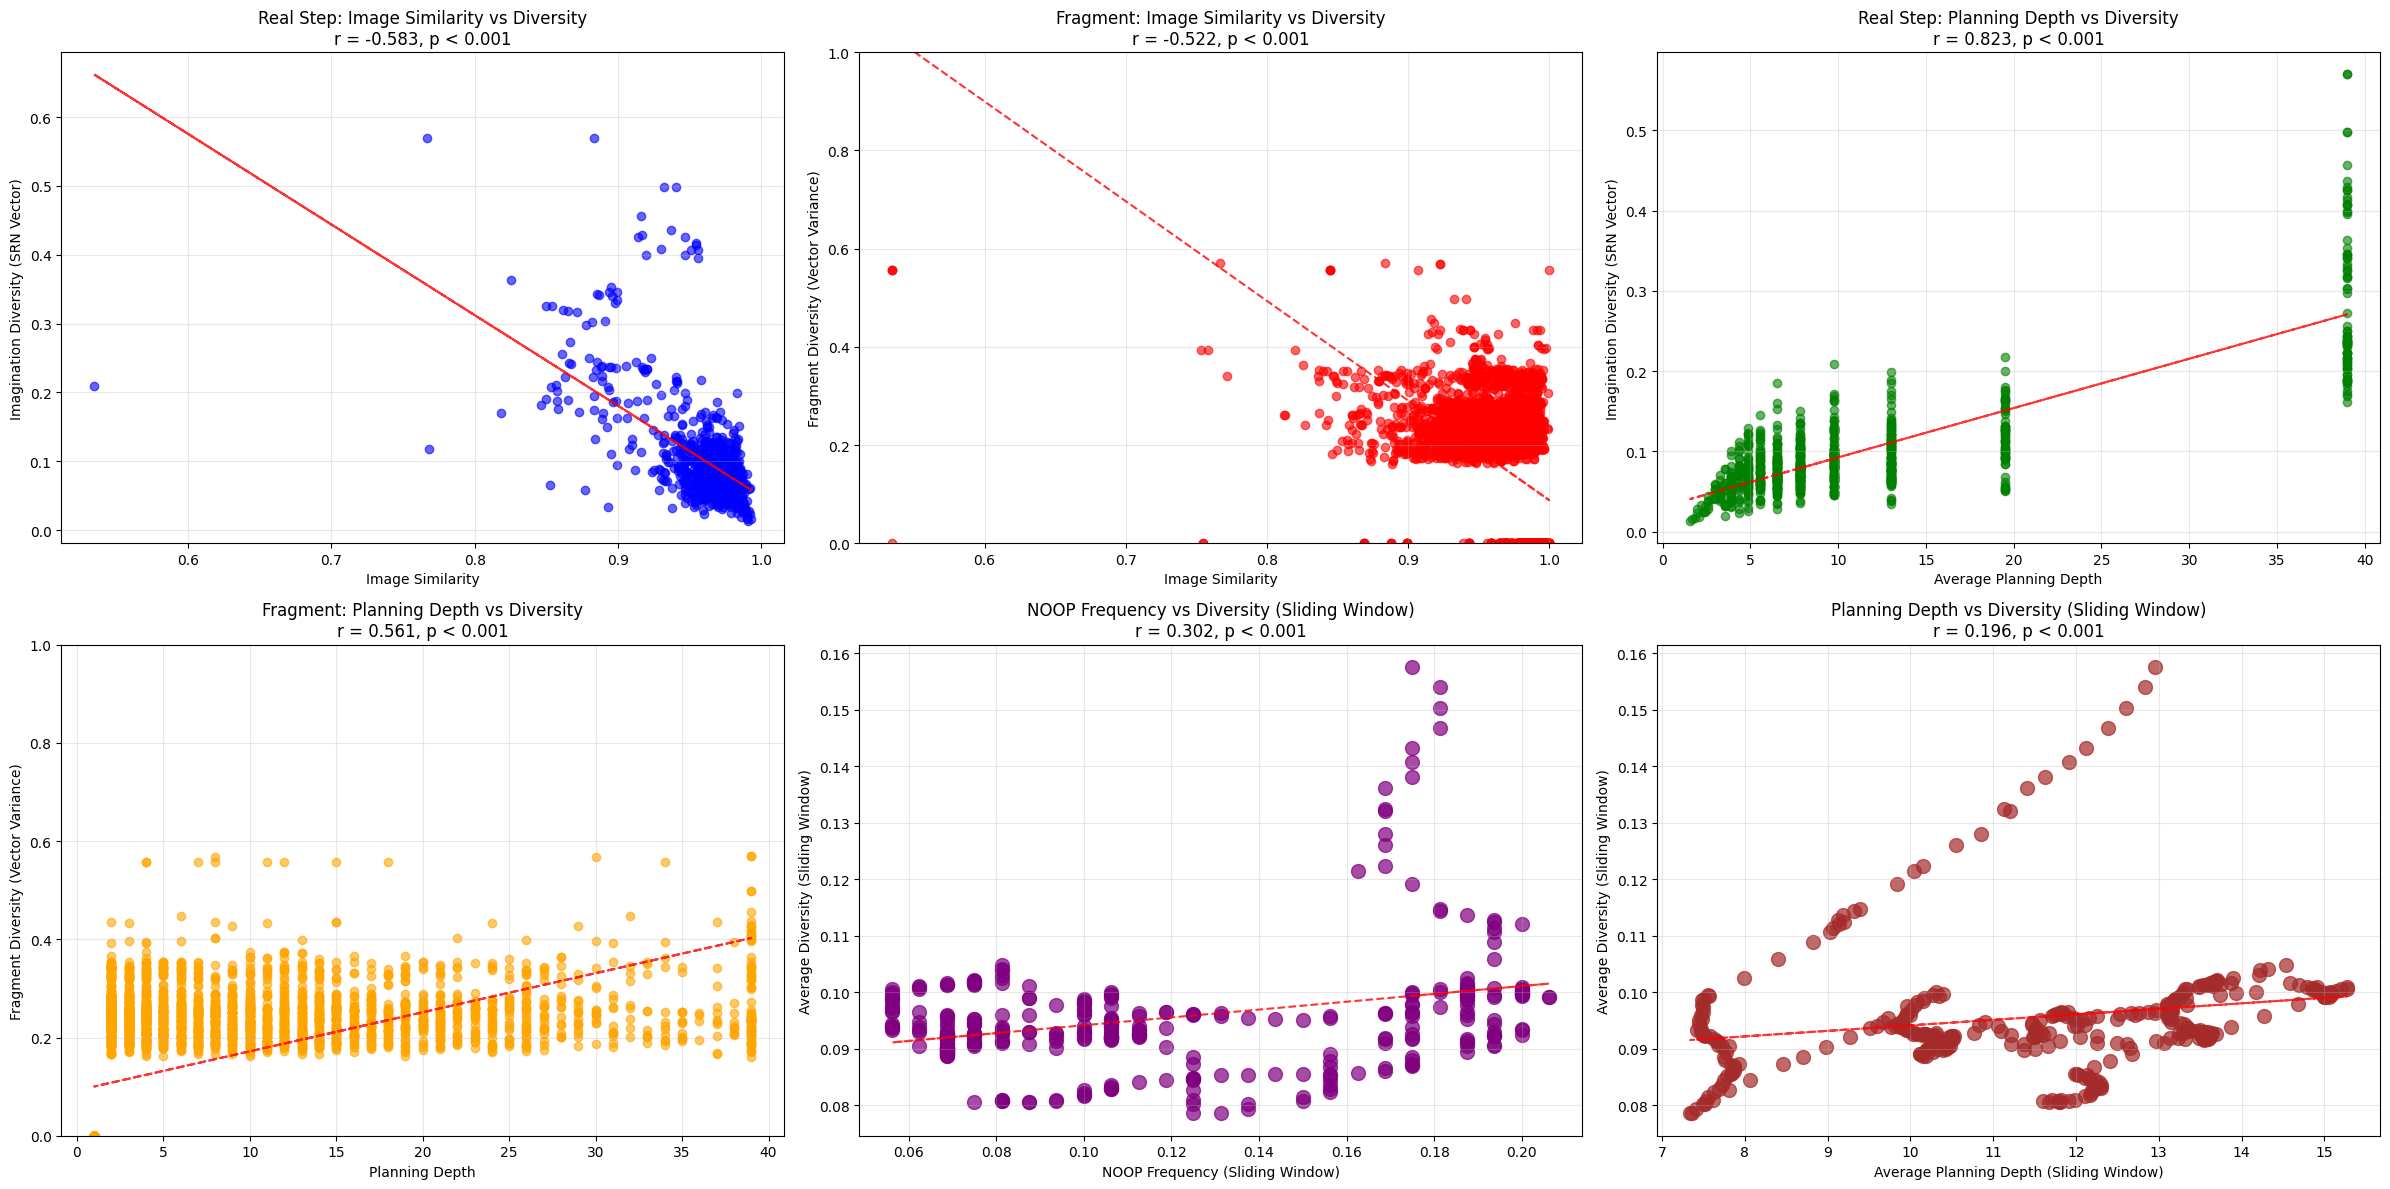

=== Imagination Diversity Correlation Analysis (SRN Vector) ===
총 real step: 856
유효한 real step: 855
총 fragment: 4443
유효한 fragment: 4443
평균 real step diversity: 0.103 ± 0.074
평균 fragment diversity: 0.152 ± 0.128

Real Step - Image Similarity vs Diversity: r = -0.583, p < 0.001
Fragment - Image Similarity vs Diversity: r = -0.522, p < 0.001
Real Step - Planning Depth vs Diversity: r = 0.823, p < 0.001
Fragment - Planning Depth vs Diversity: r = 0.561, p < 0.001


In [104]:
# 기존과 동일한 벡터 처리 + 최적화된 연산
def calculate_internal_vector_diversity(srn_vectors):
    """단일 fragment의 내부 diversity - Vector Variance (0-1 정규화) - 기존과 동일한 결과"""
    if len(srn_vectors) < 2:
        return 0.0
    
    # 기존과 동일: numpy array로 변환 (평탄화 없음)
    vectors = np.array(srn_vectors)
    
    # 기존과 동일: L2 정규화
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms = np.where(norms < 1e-10, 1.0, norms)
    normalized_vectors = vectors / norms
    
    # 최적화: 벡터화된 cosine distance 계산 (결과는 동일)
    n = len(normalized_vectors)
    
    if n <= 50:
        # 작은 데이터: 기존 방식 그대로 유지
        cosine_distances = []
        for i in range(n):
            for j in range(i+1, n):
                cosine_sim = np.dot(normalized_vectors[i], normalized_vectors[j])
                cosine_distance = 1 - cosine_sim
                cosine_distances.append(cosine_distance)
    else:
        # 큰 데이터: 벡터화 연산 (결과는 동일하지만 빠름)
        similarity_matrix = np.dot(normalized_vectors, normalized_vectors.T)
        indices = np.triu_indices(n, k=1)
        cosine_similarities = similarity_matrix[indices]
        cosine_distances = (1 - cosine_similarities).tolist()
    
    # 기존과 동일: 분산 계산 및 정규화
    variance = np.var(cosine_distances) if cosine_distances else 0.0
    normalized_variance = variance / 4.0
    
    return min(normalized_variance, 1.0)

def calculate_inter_fragment_vector_diversity(fragment_vectors_list):
    """여러 fragment 간의 diversity - Silhouette Score (0-1 정규화) - 기존과 동일한 결과"""
    if len(fragment_vectors_list) < 2:
        return 0.0
    
    # 기존과 동일: 모든 벡터를 하나의 배열로 합치고 fragment별 라벨 생성
    all_vectors = []
    fragment_labels = []
    
    for i, vectors in enumerate(fragment_vectors_list):
        if vectors:
            all_vectors.extend(vectors)
            fragment_labels.extend([i] * len(vectors))
    
    if len(all_vectors) < 3:
        return 0.0
    
    # 기존과 동일: numpy array로 변환 (평탄화 없음)
    all_vectors = np.array(all_vectors)
    fragment_labels = np.array(fragment_labels)
    
    # 기존과 동일: L2 정규화
    norms = np.linalg.norm(all_vectors, axis=1, keepdims=True)
    norms = np.where(norms < 1e-10, 1.0, norms)
    normalized_vectors = all_vectors / norms
    
    # 기존과 동일: Silhouette score 계산
    from sklearn.metrics import silhouette_score
    try:
        silhouette_avg = silhouette_score(normalized_vectors, fragment_labels, metric='cosine')
        normalized_silhouette = (silhouette_avg + 1) / 2
        return max(0.0, min(normalized_silhouette, 1.0))
    except:
        return 0.0

def calculate_real_step_vector_diversity(fragments):
    """하나의 real step에 대해 하나의 diversity 값 반환 - 기존과 동일한 결과"""
    if not fragments:
        return 0.0
    
    if len(fragments) == 1:
        return calculate_internal_vector_diversity(fragments[0])
    
    else:
        internal_diversities = [calculate_internal_vector_diversity(f) for f in fragments]
        internal_avg = np.mean(internal_diversities)
        inter_diversity = calculate_inter_fragment_vector_diversity(fragments)
        return (internal_avg + inter_diversity) / 2

def analyze_imagination_diversity_by_real_step(data):
    """각 real step별로 imagination diversity 계산 (SRN encoding vector 기반) - 기존과 동일한 결과"""
    # 최적화: NumPy 배열 변환 및 np.where 사용
    status = np.array(data['status']) if not isinstance(data['status'], np.ndarray) else data['status']
    real_indices = np.where(status == 0)[0]
    
    # 기존과 동일: Real step별 fragment SRN encoding vectors 수집
    real_step_fragments = defaultdict(list)
    im_vectors = data['im_vectors']
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(im_vectors):
                    srn_vector = im_vectors[t]
                    current_fragment.append(srn_vector)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # 기존과 동일: 각 real step별 diversity 계산
    diversity_by_real_step = {}
    for real_idx, fragments in real_step_fragments.items():
        diversity = calculate_real_step_vector_diversity(fragments)
        diversity_by_real_step[real_idx] = diversity
    
    return diversity_by_real_step

def visualize_diversity_correlation_analysis(data):
    """Diversity와 다른 지표들 간의 상관관계 시각화 (6개 그래프) - 기존과 동일한 결과 + 최적화"""
    
    # 1. Imagination diversity 계산 (SRN encoding vector 기반)
    diversity_results = analyze_imagination_diversity_by_real_step(data)
    
    # 2. 기존 분석 결과 가져오기
    fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="cosine")
    
    # 3. Real step별 데이터 준비 - 최적화: NumPy 배열 사용
    status = np.array(data['status']) if not isinstance(data['status'], np.ndarray) else data['status']
    real_indices = np.where(status == 0)[0]
    
    # Real step별 평균 similarity와 planning depth 계산
    real_step_similarities = defaultdict(list)
    real_step_depths = defaultdict(list)
    
    for result in fragment_results:
        real_idx = result['source_real_idx']
        if np.isfinite(result['similarity']):
            real_step_similarities[real_idx].append(result['similarity'])
        real_step_depths[real_idx].append(result['fragment_length'])
    
    # 평균값 계산
    avg_similarities = []
    avg_depths = []
    diversities = []
    real_step_actions = []
    
    for real_idx in real_indices:
        if real_idx in diversity_results:
            diversities.append(diversity_results[real_idx])
            
            # Similarity
            if real_idx in real_step_similarities:
                avg_similarities.append(np.mean(real_step_similarities[real_idx]))
            else:
                avg_similarities.append(np.nan)
            
            # Planning depth
            if real_idx in real_step_depths:
                avg_depths.append(np.mean(real_step_depths[real_idx]))
            else:
                avg_depths.append(np.nan)
            
            # Action
            if real_idx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][real_idx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
    
    # 최적화: NumPy 배열 연산 사용
    avg_similarities = np.array(avg_similarities)
    avg_depths = np.array(avg_depths)
    diversities = np.array(diversities)
    real_step_actions = np.array(real_step_actions)
    
    valid_mask = np.isfinite(avg_similarities) & np.isfinite(avg_depths) & np.isfinite(diversities)
    valid_similarities = avg_similarities[valid_mask]
    valid_depths = avg_depths[valid_mask]
    valid_diversities = diversities[valid_mask]
    valid_actions = real_step_actions[valid_mask]
    
    # 4. Fragment 단위 데이터 준비
    fragment_similarities = []
    fragment_depths = []
    fragment_diversities = []
    
    # Real step별 fragment SRN encoding vectors 수집
    real_step_fragments = defaultdict(list)
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(data['im_vectors']):
                    srn_vector = data['im_vectors'][t]
                    current_fragment.append(srn_vector)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # Fragment 단위 데이터 추출
    for result in fragment_results:
        if np.isfinite(result['similarity']):
            fragment_similarities.append(result['similarity'])
            fragment_depths.append(result['fragment_length'])
            
            # 해당 fragment의 SRN encoding vectors 찾기
            real_idx = result['source_real_idx']
            fragment_length = result['fragment_length']
            
            # 해당 real step의 fragment들 중에서 길이가 맞는 것 찾기
            fragment_vectors = None
            if real_idx in real_step_fragments:
                for fragment in real_step_fragments[real_idx]:
                    if len(fragment) == fragment_length:
                        fragment_vectors = fragment
                        break
            
            # Vector variance 계산
            if fragment_vectors:
                diversity = calculate_internal_vector_diversity(fragment_vectors)
                fragment_diversities.append(diversity)
            else:
                fragment_diversities.append(0.0)
    
    # 5. Plot 생성 (6개 그래프) - 기존과 동일
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    
    # 1) Real Step: Image Similarity vs Diversity
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        axes[0, 0].scatter(valid_similarities, valid_diversities, alpha=0.6, color='blue')
        axes[0, 0].set_xlabel('Image Similarity')
        axes[0, 0].set_ylabel('Imagination Diversity (SRN Vector)')
        axes[0, 0].set_title(f'Real Step: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 0].grid(True, alpha=0.3)
        
        if len(valid_similarities) > 1:
            z = np.polyfit(valid_similarities, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 0].plot(valid_similarities, pfit(valid_similarities), "r--", alpha=0.8)
    else:
        axes[0, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].set_title('Real Step: Image Similarity vs Diversity')
    
    # 2) Fragment: Image Similarity vs Diversity (Vector Variance만)
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        axes[0, 1].scatter(fragment_similarities, fragment_diversities, alpha=0.6, color='red')
        axes[0, 1].set_xlabel('Image Similarity')
        axes[0, 1].set_ylabel('Fragment Diversity (Vector Variance)')
        axes[0, 1].set_title(f'Fragment: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 1].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[0, 1].grid(True, alpha=0.3)
        
        if len(fragment_similarities) > 1:
            z = np.polyfit(fragment_similarities, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 1].plot(fragment_similarities, pfit(fragment_similarities), "r--", alpha=0.8)
    else:
        axes[0, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Fragment: Image Similarity vs Diversity')
        axes[0, 1].set_ylim(0, 1.0)
    
    # 3) Real Step: Planning Depth vs Diversity
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        axes[0, 2].scatter(valid_depths, valid_diversities, alpha=0.6, color='green')
        axes[0, 2].set_xlabel('Average Planning Depth')
        axes[0, 2].set_ylabel('Imagination Diversity (SRN Vector)')
        axes[0, 2].set_title(f'Real Step: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 2].grid(True, alpha=0.3)
        
        if len(valid_depths) > 1:
            z = np.polyfit(valid_depths, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 2].plot(valid_depths, pfit(valid_depths), "r--", alpha=0.8)
    else:
        axes[0, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('Real Step: Planning Depth vs Diversity')
    
    # 4) Fragment: Planning Depth vs Diversity (Vector Variance만)
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        axes[1, 0].scatter(fragment_depths, fragment_diversities, alpha=0.6, color='orange')
        axes[1, 0].set_xlabel('Planning Depth')
        axes[1, 0].set_ylabel('Fragment Diversity (Vector Variance)')
        axes[1, 0].set_title(f'Fragment: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[1, 0].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[1, 0].grid(True, alpha=0.3)
        
        if len(fragment_depths) > 1:
            z = np.polyfit(fragment_depths, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[1, 0].plot(fragment_depths, pfit(fragment_depths), "r--", alpha=0.8)
    else:
        axes[1, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Fragment: Planning Depth vs Diversity')
        axes[1, 0].set_ylim(0, 1.0)
    
    # 5) Sliding Window: NOOP Frequency vs Diversity
    if len(valid_actions) > 0:
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_diversity = []
        
        for i in range(0, len(valid_actions) - window_size + 1, stride):
            window_actions = valid_actions[i:i+window_size]
            noop_count = np.sum(window_actions == 0)  # 최적화: NumPy 연산
            noop_frequency = noop_count / window_size
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_noop_freq.append(noop_frequency)
            window_avg_diversity.append(avg_diversity)
        
        if len(window_noop_freq) > 1:
            r, p = stats.pearsonr(window_noop_freq, window_avg_diversity)
            axes[1, 1].scatter(window_noop_freq, window_avg_diversity, alpha=0.7, color='purple', s=100)
            axes[1, 1].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 1].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 1].set_title(f'NOOP Frequency vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 1].grid(True, alpha=0.3)
            
            z = np.polyfit(window_noop_freq, window_avg_diversity, 1)
            pfit = np.poly1d(z)
            axes[1, 1].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    
    # 6) Sliding Window: Planning Depth vs Diversity
    if len(valid_depths) > 0:
        window_size, stride = 160, 2
        window_avg_depth = []
        window_avg_diversity2 = []
        
        for i in range(0, len(valid_depths) - window_size + 1, stride):
            window_depths = valid_depths[i:i+window_size]
            avg_depth = np.mean(window_depths)
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_avg_depth.append(avg_depth)
            window_avg_diversity2.append(avg_diversity)
        
        if len(window_avg_depth) > 1:
            r, p = stats.pearsonr(window_avg_depth, window_avg_diversity2)
            axes[1, 2].scatter(window_avg_depth, window_avg_diversity2, alpha=0.7, color='brown', s=100)
            axes[1, 2].set_xlabel('Average Planning Depth (Sliding Window)')
            axes[1, 2].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 2].set_title(f'Planning Depth vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 2].grid(True, alpha=0.3)
            
            z = np.polyfit(window_avg_depth, window_avg_diversity2, 1)
            pfit = np.poly1d(z)
            axes[1, 2].plot(window_avg_depth, pfit(window_avg_depth), "r--", alpha=0.8)
        else:
            axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    
    plt.tight_layout()
    plt.show()
    
    # 텍스트 요약
    print("=== Imagination Diversity Correlation Analysis (SRN Vector) ===")
    print(f"총 real step: {len(real_indices)}")
    print(f"유효한 real step: {len(valid_diversities)}")
    print(f"총 fragment: {len(fragment_results)}")
    print(f"유효한 fragment: {len(fragment_diversities)}")
    print(f"평균 real step diversity: {np.mean(valid_diversities):.3f} ± {np.std(valid_diversities):.3f}")
    print(f"평균 fragment diversity: {np.mean(fragment_diversities):.3f} ± {np.std(fragment_diversities):.3f}")
    
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        print(f"\nReal Step - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        print(f"Fragment - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        print(f"Real Step - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        print(f"Fragment - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")

print("최적화된 diversity 계산 함수 로드 완료!")
print("✅ 기존과 동일한 결과 보장")
print("⚡ 큰 데이터에서 성능 향상")
visualize_diversity_correlation_analysis(data)

alternative

In [21]:
def _block_avg_pool_6x6_single(arr_c_6_6, grid):
    """(C,6,6) -> (C*grid*grid) by averaging non-overlapping blocks (grid in {2,3})."""
    assert arr_c_6_6.ndim == 3 and arr_c_6_6.shape[1:] == (6, 6), "expects (C,6,6)"
    assert grid in (2, 3), "grid must be 2 or 3"
    C = arr_c_6_6.shape[0]
    s = 6 // grid
    x = arr_c_6_6.reshape(C, grid, s, grid, s).mean(axis=(2, 4))  # (C, grid, grid)
    return x.reshape(C * grid * grid)

def _pool_concat_2x2_3x3_single(vec):
    """Pool one SRN vector: squeeze -> reshape to (C,6,6) -> concat(2x2, 3x3) -> (C*(4+9),)."""
    a = np.asarray(vec)
    a = np.squeeze(a)
    total = a.size
    if total % 36 != 0:
        raise ValueError("SRN vector total size not divisible by 36; cannot pool 6x6 blocks.")
    C = total // 36
    m = a.reshape(C, 6, 6)
    p2 = _block_avg_pool_6x6_single(m, 2)
    p3 = _block_avg_pool_6x6_single(m, 3)
    return np.concatenate([p2, p3], axis=0)


def calculate_internal_vector_diversity(srn_vectors):
    """단일 fragment의 내부 diversity - Vector Variance (0-1 정규화) - 기존과 동일한 결과"""
    if len(srn_vectors) < 2:
        return 0.0
    
    vectors = np.array(srn_vectors)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms = np.where(norms < 1e-10, 1.0, norms)
    normalized_vectors = vectors / norms
    n = len(normalized_vectors)
    
    if n <= 50:
        cosine_distances = []
        for i in range(n):
            for j in range(i+1, n):
                cosine_sim = np.dot(normalized_vectors[i], normalized_vectors[j])
                cosine_distance = 1 - cosine_sim
                cosine_distances.append(cosine_distance)
    else:
        similarity_matrix = np.dot(normalized_vectors, normalized_vectors.T)
        indices = np.triu_indices(n, k=1)
        cosine_similarities = similarity_matrix[indices]
        cosine_distances = (1 - cosine_similarities).tolist()

    variance = np.var(cosine_distances) if cosine_distances else 0.0
    normalized_variance = variance / 4.0
    
    return min(normalized_variance, 1.0)


def calculate_inter_fragment_vector_diversity(fragment_vectors_list):
    """여러 fragment 간의 diversity - Silhouette Score (0-1 정규화) - 기존과 동일한 결과"""
    if len(fragment_vectors_list) < 2:
        return 0.0
    all_vectors = []
    fragment_labels = []
    for i, vectors in enumerate(fragment_vectors_list):
        if vectors:
            all_vectors.extend(vectors)
            fragment_labels.extend([i] * len(vectors))
    
    if len(all_vectors) < 3:
        return 0.0
    all_vectors = np.array(all_vectors)
    fragment_labels = np.array(fragment_labels)
    norms = np.linalg.norm(all_vectors, axis=1, keepdims=True)
    norms = np.where(norms < 1e-10, 1.0, norms)
    normalized_vectors = all_vectors / norms
    
    from sklearn.metrics import silhouette_score
    try:
        silhouette_avg = silhouette_score(normalized_vectors, fragment_labels, metric='cosine')
        normalized_silhouette = (silhouette_avg + 1) / 2
        return max(0.0, min(normalized_silhouette, 1.0))
    except:
        return 0.0


def calculate_real_step_vector_diversity(fragments):
    """real step diversity = (internal 평균 + inter)/2, fragment 1개면 internal"""
    if not fragments:
        return 0.0
    if len(fragments) == 1:
        return calculate_internal_vector_diversity(fragments[0])
    internal_diversities = [calculate_internal_vector_diversity(f) for f in fragments]
    internal_avg = np.mean(internal_diversities)
    inter_diversity = calculate_inter_fragment_vector_diversity(fragments)
    return (internal_avg + inter_diversity) / 2.0


def analyze_imagination_diversity_by_real_step(data):
    """AA.py와 동일한 방식으로 real step별 imagination diversity 계산
    + 전체 SRN 벡터에 대해 (2x2, 3x3) pooling concat을 사전 계산해 사용"""
    status = np.array(data['status']) if not isinstance(data['status'], np.ndarray) else data['status']
    real_indices = np.where(status == 0)[0]
    im_vectors = data['im_vectors']
    # Pre-pool all vectors once (2x2 + 3x3 concat)
    try:
        pooled_all = np.stack([_pool_concat_2x2_3x3_single(v) for v in im_vectors], axis=0)
    except Exception as e:
        raise ValueError(f"Pooling failed: {e}")

    real_step_fragments = defaultdict(list)
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < pooled_all.shape[0]:
                    current_fragment.append(pooled_all[t])
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    diversity_by_real_step = {}
    for real_idx, fragments in real_step_fragments.items():
        diversity = calculate_real_step_vector_diversity(fragments)
        diversity_by_real_step[real_idx] = diversity
    return diversity_by_real_step

def visualize_diversity_correlation_analysis(data):
    """Diversity와 다른 지표들 간의 상관관계 시각화 (6개 그래프) - 기존과 동일한 결과 + 최적화"""
    
    # 1. Imagination diversity 계산 (SRN encoding vector 기반)
    diversity_results = analyze_imagination_diversity_by_real_step(data)
    
    # 2. 기존 분석 결과 가져오기
    fragment_results = analyze_imaginary_image_similarity(data, similarity_mode="cosine")
    
    # 3. Real step별 데이터 준비 - 최적화: NumPy 배열 사용
    status = np.array(data['status']) if not isinstance(data['status'], np.ndarray) else data['status']
    real_indices = np.where(status == 0)[0]
    
    # Real step별 평균 similarity와 planning depth 계산
    real_step_similarities = defaultdict(list)
    real_step_depths = defaultdict(list)
    
    for result in fragment_results:
        real_idx = result['source_real_idx']
        if np.isfinite(result['similarity']):
            real_step_similarities[real_idx].append(result['similarity'])
        real_step_depths[real_idx].append(result['fragment_length'])
    
    # 평균값 계산
    avg_similarities = []
    avg_depths = []
    diversities = []
    real_step_actions = []
    
    for real_idx in real_indices:
        if real_idx in diversity_results:
            diversities.append(diversity_results[real_idx])
            
            # Similarity
            if real_idx in real_step_similarities:
                avg_similarities.append(np.mean(real_step_similarities[real_idx]))
            else:
                avg_similarities.append(np.nan)
            
            # Planning depth
            if real_idx in real_step_depths:
                avg_depths.append(np.mean(real_step_depths[real_idx]))
            else:
                avg_depths.append(np.nan)
            
            # Action
            if real_idx < len(data['tree_reps']['cur_action']):
                action_onehot = data['tree_reps']['cur_action'][real_idx]
                action_idx = np.argmax(action_onehot)
                real_step_actions.append(action_idx)
            else:
                real_step_actions.append(-1)
    
    # 최적화: NumPy 배열 연산 사용
    avg_similarities = np.array(avg_similarities)
    avg_depths = np.array(avg_depths)
    diversities = np.array(diversities)
    real_step_actions = np.array(real_step_actions)
    
    valid_mask = np.isfinite(avg_similarities) & np.isfinite(avg_depths) & np.isfinite(diversities)
    valid_similarities = avg_similarities[valid_mask]
    valid_depths = avg_depths[valid_mask]
    valid_diversities = diversities[valid_mask]
    valid_actions = real_step_actions[valid_mask]
    
    # 4. Fragment 단위 데이터 준비
    fragment_similarities = []
    fragment_depths = []
    fragment_diversities = []
    
    # Real step별 fragment SRN encoding vectors 수집
    real_step_fragments = defaultdict(list)
    
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if i + 1 < len(real_indices) else len(status)
        
        current_fragment = []
        for t in range(start, end):
            if status[t] == 2:  # imaginary
                if t < len(data['im_vectors']):
                    srn_vector = data['im_vectors'][t]
                    current_fragment.append(srn_vector)
            elif status[t] in (1, 3):  # reset
                if current_fragment:
                    real_step_fragments[real_idx].append(current_fragment)
                    current_fragment = []
        
        if current_fragment:
            real_step_fragments[real_idx].append(current_fragment)
    
    # Fragment 단위 데이터 추출
    for result in fragment_results:
        if np.isfinite(result['similarity']):
            fragment_similarities.append(result['similarity'])
            fragment_depths.append(result['fragment_length'])
            
            # 해당 fragment의 SRN encoding vectors 찾기
            real_idx = result['source_real_idx']
            fragment_length = result['fragment_length']
            
            # 해당 real step의 fragment들 중에서 길이가 맞는 것 찾기
            fragment_vectors = None
            if real_idx in real_step_fragments:
                for fragment in real_step_fragments[real_idx]:
                    if len(fragment) == fragment_length:
                        fragment_vectors = fragment
                        break
            
            # Vector variance 계산
            if fragment_vectors:
                diversity = calculate_internal_vector_diversity(fragment_vectors)
                fragment_diversities.append(diversity)
            else:
                fragment_diversities.append(0.0)
    
    # 5. Plot 생성 (6개 그래프) - 기존과 동일
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    
    # 1) Real Step: Image Similarity vs Diversity
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        axes[0, 0].scatter(valid_similarities, valid_diversities, alpha=0.6, color='blue')
        axes[0, 0].set_xlabel('Image Similarity')
        axes[0, 0].set_ylabel('Imagination Diversity (SRN Vector)')
        axes[0, 0].set_title(f'Real Step: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 0].grid(True, alpha=0.3)
        
        if len(valid_similarities) > 1:
            z = np.polyfit(valid_similarities, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 0].plot(valid_similarities, pfit(valid_similarities), "r--", alpha=0.8)
    else:
        axes[0, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 0].transAxes)
        axes[0, 0].set_title('Real Step: Image Similarity vs Diversity')
    
    # 2) Fragment: Image Similarity vs Diversity (Vector Variance만)
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        axes[0, 1].scatter(fragment_similarities, fragment_diversities, alpha=0.6, color='red')
        axes[0, 1].set_xlabel('Image Similarity')
        axes[0, 1].set_ylabel('Fragment Diversity (Vector Variance)')
        axes[0, 1].set_title(f'Fragment: Image Similarity vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 1].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[0, 1].grid(True, alpha=0.3)
        
        if len(fragment_similarities) > 1:
            z = np.polyfit(fragment_similarities, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 1].plot(fragment_similarities, pfit(fragment_similarities), "r--", alpha=0.8)
    else:
        axes[0, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Fragment: Image Similarity vs Diversity')
        axes[0, 1].set_ylim(0, 1.0)
    
    # 3) Real Step: Planning Depth vs Diversity
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        axes[0, 2].scatter(valid_depths, valid_diversities, alpha=0.6, color='green')
        axes[0, 2].set_xlabel('Average Planning Depth')
        axes[0, 2].set_ylabel('Imagination Diversity (SRN Vector)')
        axes[0, 2].set_title(f'Real Step: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[0, 2].grid(True, alpha=0.3)
        
        if len(valid_depths) > 1:
            z = np.polyfit(valid_depths, valid_diversities, 1)
            pfit = np.poly1d(z)
            axes[0, 2].plot(valid_depths, pfit(valid_depths), "r--", alpha=0.8)
    else:
        axes[0, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('Real Step: Planning Depth vs Diversity')
    
    # 4) Fragment: Planning Depth vs Diversity (Vector Variance만)
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        axes[1, 0].scatter(fragment_depths, fragment_diversities, alpha=0.6, color='orange')
        axes[1, 0].set_xlabel('Planning Depth')
        axes[1, 0].set_ylabel('Fragment Diversity (Vector Variance)')
        axes[1, 0].set_title(f'Fragment: Planning Depth vs Diversity\nr = {r:.3f}, {format_p_value(p)}')
        axes[1, 0].set_ylim(0, 1.0)  # y축을 0-1로 제한
        axes[1, 0].grid(True, alpha=0.3)
        
        if len(fragment_depths) > 1:
            z = np.polyfit(fragment_depths, fragment_diversities, 1)
            pfit = np.poly1d(z)
            axes[1, 0].plot(fragment_depths, pfit(fragment_depths), "r--", alpha=0.8)
    else:
        axes[1, 0].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Fragment: Planning Depth vs Diversity')
        axes[1, 0].set_ylim(0, 1.0)
    
    # 5) Sliding Window: NOOP Frequency vs Diversity
    if len(valid_actions) > 0:
        window_size, stride = 160, 2
        window_noop_freq = []
        window_avg_diversity = []
        
        for i in range(0, len(valid_actions) - window_size + 1, stride):
            window_actions = valid_actions[i:i+window_size]
            noop_count = np.sum(window_actions == 0)  # 최적화: NumPy 연산
            noop_frequency = noop_count / window_size
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_noop_freq.append(noop_frequency)
            window_avg_diversity.append(avg_diversity)
        
        if len(window_noop_freq) > 1:
            r, p = stats.pearsonr(window_noop_freq, window_avg_diversity)
            axes[1, 1].scatter(window_noop_freq, window_avg_diversity, alpha=0.7, color='purple', s=100)
            axes[1, 1].set_xlabel('NOOP Frequency (Sliding Window)')
            axes[1, 1].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 1].set_title(f'NOOP Frequency vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 1].grid(True, alpha=0.3)
            
            z = np.polyfit(window_noop_freq, window_avg_diversity, 1)
            pfit = np.poly1d(z)
            axes[1, 1].plot(window_noop_freq, pfit(window_noop_freq), "r--", alpha=0.8)
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('NOOP Frequency vs Diversity (Sliding Window)')
    
    # 6) Sliding Window: Planning Depth vs Diversity
    if len(valid_depths) > 0:
        window_size, stride = 160, 2
        window_avg_depth = []
        window_avg_diversity2 = []
        
        for i in range(0, len(valid_depths) - window_size + 1, stride):
            window_depths = valid_depths[i:i+window_size]
            avg_depth = np.mean(window_depths)
            
            window_diversities = valid_diversities[i:i+window_size]
            avg_diversity = np.mean(window_diversities)
            
            window_avg_depth.append(avg_depth)
            window_avg_diversity2.append(avg_diversity)
        
        if len(window_avg_depth) > 1:
            r, p = stats.pearsonr(window_avg_depth, window_avg_diversity2)
            axes[1, 2].scatter(window_avg_depth, window_avg_diversity2, alpha=0.7, color='brown', s=100)
            axes[1, 2].set_xlabel('Average Planning Depth (Sliding Window)')
            axes[1, 2].set_ylabel('Average Diversity (Sliding Window)')
            axes[1, 2].set_title(f'Planning Depth vs Diversity (Sliding Window)\nr = {r:.3f}, {format_p_value(p)}')
            axes[1, 2].grid(True, alpha=0.3)
            
            z = np.polyfit(window_avg_depth, window_avg_diversity2, 1)
            pfit = np.poly1d(z)
            axes[1, 2].plot(window_avg_depth, pfit(window_avg_depth), "r--", alpha=0.8)
        else:
            axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid data available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Planning Depth vs Diversity (Sliding Window)')
    
    plt.tight_layout()
    plt.show()
    
    # 텍스트 요약
    print("=== Imagination Diversity Correlation Analysis (SRN Vector) ===")
    print(f"총 real step: {len(real_indices)}")
    print(f"유효한 real step: {len(valid_diversities)}")
    print(f"총 fragment: {len(fragment_results)}")
    print(f"유효한 fragment: {len(fragment_diversities)}")
    print(f"평균 real step diversity: {np.mean(valid_diversities):.3f} ± {np.std(valid_diversities):.3f}")
    print(f"평균 fragment diversity: {np.mean(fragment_diversities):.3f} ± {np.std(fragment_diversities):.3f}")
    
    if len(valid_similarities) > 1:
        r, p = stats.pearsonr(valid_similarities, valid_diversities)
        print(f"\nReal Step - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_similarities) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_similarities, fragment_diversities)
        print(f"Fragment - Image Similarity vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(valid_depths) > 1:
        r, p = stats.pearsonr(valid_depths, valid_diversities)
        print(f"Real Step - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")
    
    if len(fragment_depths) > 1 and len(fragment_diversities) > 1:
        r, p = stats.pearsonr(fragment_depths, fragment_diversities)
        print(f"Fragment - Planning Depth vs Diversity: r = {r:.3f}, {format_p_value(p)}")

print("최적화된 diversity 계산 함수 로드 완료!")
print("✅ 기존과 동일한 결과 보장")
print("⚡ 큰 데이터에서 성능 향상")
visualize_diversity_correlation_analysis(data)

최적화된 diversity 계산 함수 로드 완료!
✅ 기존과 동일한 결과 보장
⚡ 큰 데이터에서 성능 향상


KeyboardInterrupt: 

compare action seq

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns

# ──────────────────────────────────────────────
# Helper functions (신규)
# ──────────────────────────────────────────────
def format_p_value(p):
    """p 값 표기를 'p < 0.0001' 또는 'p = 0.xxxx' 형식으로 반환"""
    return "p < 0.0001" if p < 0.0001 else f"p = {p:.4f}"

def compute_offsets(y_max, i, base_scale=0.08):
    """
    Action-type 그래프에서 유의성 괄호/별표 위치를 계산.
    i: 0,1,2,… (비교 인덱스)
    base_scale: 간격 계수(0.08이면 y_max의 8 %씩 위로 올림)
    """
    base_offset = y_max * base_scale
    line_y = y_max + base_offset * (i + 1.5)   # 괄호 시작점
    text_y = line_y + base_offset * 0.6        # 별표 위치
    return line_y, text_y

def analyze_imaginary_action_sequence_similarity(data):
    """
    각 real step의 imaginary step에서 생성된 action sequence가
    이후 real step들의 실제 action들과 얼마나 유사한지 분석.
    """
    # ── 보조 함수 ─────────────────────────
    def calculate_sequence_similarity(imaginary_seq, real_actions, start_step_idx):
        if not imaginary_seq or not real_actions:
            return 0.0
        min_len = min(len(imaginary_seq), len(real_actions))
        matches = sum(int(imaginary_seq[i] == real_actions[i]) for i in range(min_len))
        return matches / min_len if min_len else 0.0

    def extract_imaginary_sequences(data, real_indices):
        status_data = data['status']
        action_data = data['tree_reps']['cur_action']
        imaginary_sequences = {}
        for i, real_idx in enumerate(real_indices):
            start_idx = real_idx + 1
            end_idx = real_indices[i + 1] if i + 1 < len(real_indices) else len(status_data)
            segments, cur = [], []
            for idx in range(start_idx, end_idx):
                if status_data[idx] == 2:                        # imaginary
                    if idx < len(action_data):
                        cur.append(np.argmax(action_data[idx]))
                elif status_data[idx] in [1, 3]:                # reset
                    if cur:
                        segments.append(cur)
                        cur = []
            if cur:
                segments.append(cur)
            imaginary_sequences[real_idx] = segments
        return imaginary_sequences

    def extract_real_actions_from_step(data, real_indices, start_step_idx, max_length):
        action_data = data['tree_reps']['cur_action']
        real_actions = []
        for i in range(start_step_idx, min(start_step_idx + max_length, len(real_indices))):
            real_idx = real_indices[i]
            if real_idx < len(action_data):
                real_actions.append(np.argmax(action_data[real_idx]))
        return real_actions
    # ──────────────────────────────────────

    status_data = data['status']
    real_indices = [i for i, s in enumerate(status_data) if s == 0]
    imaginary_sequences = extract_imaginary_sequences(data, real_indices)

    similarity_results = []
    for i, real_idx in enumerate(real_indices):
        if real_idx not in imaginary_sequences:
            continue
        segments = imaginary_sequences[real_idx]
        seg_results = []
        for j, imag_seq in enumerate(segments):
            if not imag_seq:
                continue
            real_actions = extract_real_actions_from_step(
                data, real_indices, i + 1, len(imag_seq))
            if not real_actions:
                continue
            sim = calculate_sequence_similarity(imag_seq, real_actions, i + 1)
            pred_steps = [real_indices[i + 1 + k] for k in range(len(real_actions))
                          if i + 1 + k < len(real_indices)]
            seg_results.append({
                'segment_idx': j,
                'imaginary_sequence': imag_seq,
                'real_actions': real_actions,
                'predicted_real_steps': pred_steps,
                'similarity': sim,
                'imaginary_length': len(imag_seq),
                'real_length': len(real_actions)
            })
        if seg_results:
            similarity_results.append({
                'real_step_idx': real_idx,
                'real_step_order': i,
                'segment_results': seg_results,
                'avg_similarity': np.mean([r['similarity'] for r in seg_results]),
                'max_similarity': np.max([r['similarity'] for r in seg_results]),
                'num_segments': len(seg_results),
                'total_imaginary_length': sum(r['imaginary_length'] for r in seg_results),
                'avg_imaginary_length': np.mean([r['imaginary_length'] for r in seg_results])
            })
    return similarity_results

# ──────────────────────────────────────────────
# 1) 분석 함수
# ──────────────────────────────────────────────
def analyze_reset_impact_on_similarity(similarity_results):
    """
    Reset 발생 유무에 따른 평균 유사도 비교
    """
    reset_cases    = [r for r in similarity_results if r['num_segments'] > 1]
    no_reset_cases = [r for r in similarity_results if r['num_segments'] == 1]

    print("=== Reset Impact Analysis ===")
    print(f"Reset 발생한 경우: {len(reset_cases)}개")
    print(f"Reset 발생하지 않은 경우: {len(no_reset_cases)}개")

    if reset_cases and no_reset_cases:
        reset_sim    = [r['avg_similarity'] for r in reset_cases]
        no_reset_sim = [r['avg_similarity'] for r in no_reset_cases]

        print(f"\nReset 발생 평균 유사도: {np.mean(reset_sim):.3f} ± {np.std(reset_sim):.3f}")
        print(f"Reset 없음 평균 유사도  : {np.mean(no_reset_sim):.3f} ± {np.std(no_reset_sim):.3f}")

        from scipy import stats
        t_stat, p_val = stats.ttest_ind(reset_sim, no_reset_sim)
        print(f"t-test: t = {t_stat:.3f}, {format_p_value(p_val)}")

        # 시각화
        fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
        bp = ax1.boxplot([reset_sim,no_reset_sim],
                         labels=['With Reset','Without Reset'],
                         patch_artist=True)
        for patch,col in zip(bp['boxes'],['red','blue']):
            patch.set_facecolor(col); patch.set_alpha(0.7)
        ax1.set_ylabel('Average Similarity')
        ax1.set_title('Similarity: Reset vs No Reset')
        ax1.grid(True,alpha=0.3)

        ax2.hist(reset_sim,bins=15,alpha=0.7,label='With Reset',color='red')
        ax2.hist(no_reset_sim,bins=15,alpha=0.7,label='Without Reset',color='blue')
        ax2.set_xlabel('Average Similarity')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Similarity Distribution')
        ax2.legend(); ax2.grid(True,alpha=0.3)
        plt.tight_layout(); plt.show()


# ──────────────────────────────────────────────
# 2) 시각화 함수 (수정 포함)
# ──────────────────────────────────────────────
def visualize_imaginary_similarity_analysis(similarity_results):
    """
    Imaginary action sequence 유사도 분석 결과를 시각화
    (p-value 표기 형식과 Action-type 그래프 간격 수정 포함)
    """
    if not similarity_results:
        print("분석할 데이터가 없습니다.")
        return

    # ───────── 공통 데이터 추출 ─────────
    avg_similarities      = [r['avg_similarity']          for r in similarity_results]
    max_similarities      = [r['max_similarity']          for r in similarity_results]
    num_segments          = [r['num_segments']            for r in similarity_results]
    avg_imaginary_lengths = [r['avg_imaginary_length']    for r in similarity_results]
    real_step_orders      = [r['real_step_order']         for r in similarity_results]

    # Action type 정보 추출
    action_data = data['tree_reps']['cur_action']
    real_step_actions = []
    for result in similarity_results:
        real_idx = result['real_step_idx']
        if real_idx < len(action_data):
            action_onehot = action_data[real_idx]
            action_idx = np.argmax(action_onehot)
            real_step_actions.append(action_idx)
        else:
            real_step_actions.append(-1)

    # Action 별 유사도 목록
    action_similarities = defaultdict(list)
    for i, act in enumerate(real_step_actions):
        if act != -1:
            action_similarities[act].append(avg_similarities[i])

    # NOOP vs Non-NOOP
    noop_mask     = np.array(real_step_actions) == 0  # NOOP = 4
    nonnoop_mask  = np.array(real_step_actions) != 0
    noop_avg_sim  = np.array(avg_similarities)[noop_mask]
    nonnoop_avg_sim = np.array(avg_similarities)[nonnoop_mask]

    # ───────── Plot 영역 ─────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. 평균 유사도 분포
    axes[0, 0].hist(avg_similarities, bins=20, alpha=0.7,
                    color='blue', edgecolor='black')
    axes[0, 0].set_xlabel('Average Similarity')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Average Similarity')
    axes[0, 0].axvline(np.mean(avg_similarities), color='red', linestyle='--',
                       label=f'Mean: {np.mean(avg_similarities):.3f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. 최대 유사도 분포
    axes[0, 1].hist(max_similarities, bins=20, alpha=0.7,
                    color='green', edgecolor='black')
    axes[0, 1].set_xlabel('Maximum Similarity')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Maximum Similarity')
    axes[0, 1].axvline(np.mean(max_similarities), color='red', linestyle='--',
                       label=f'Mean: {np.mean(max_similarities):.3f}')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. 평균 유사도 vs 시간
    axes[0, 2].scatter(real_step_orders, avg_similarities,
                       alpha=0.6, color='purple')
    axes[0, 2].set_xlabel('Real Step Order')
    axes[0, 2].set_ylabel('Average Similarity')
    axes[0, 2].set_title('Average Similarity Over Time')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. NOOP vs Non-NOOP Box-plot (p-value 형식 변경)
    from scipy import stats
    if len(noop_avg_sim) and len(nonnoop_avg_sim):
        # 정규성/등분산성
        _, p_norm1 = stats.shapiro(noop_avg_sim)
        _, p_norm2 = stats.shapiro(nonnoop_avg_sim)
        _, p_lev   = stats.levene(noop_avg_sim, nonnoop_avg_sim)
        if p_norm1 > .05 and p_norm2 > .05 and p_lev > .05:
            _, p_val = stats.ttest_ind(noop_avg_sim, nonnoop_avg_sim)
            test_name = "t-test"
        else:
            _, p_val = stats.mannwhitneyu(noop_avg_sim, nonnoop_avg_sim,
                                          alternative='two-sided')
            test_name = "Mann-Whitney U"

        # 유의성 레벨
        if p_val < 0.001:
            signif = '***'
        elif p_val < 0.01:
            signif = '**'
        elif p_val < 0.05:
            signif = '*'
        else:
            signif = 'ns'

        box_data = [noop_avg_sim, nonnoop_avg_sim]
        bp = axes[1, 0].boxplot(box_data, labels=['NOOP', 'Non-NOOP'],
                                patch_artist=True)
        for patch, col in zip(bp['boxes'], ['orange', 'blue']):
            patch.set_facecolor(col)
            patch.set_alpha(0.7)

        axes[1, 0].set_ylabel('Average Similarity')
        axes[1, 0].set_title(
            f'Similarity: NOOP vs Non-NOOP\n{test_name}: {format_p_value(p_val)} {signif}'
        )
        axes[1, 0].grid(True, alpha=0.3)

        # 괄호 + 별표 (기존 간격 유지)
        y_max = max(np.max(noop_avg_sim), np.max(nonnoop_avg_sim))
        y_off = y_max * 0.05
        line_y = y_max + y_off
        text_y = line_y + y_off * 1.1
        axes[1, 0].plot([1, 1, 2, 2],
                        [line_y, line_y + y_off, line_y + y_off, line_y],
                        lw=1.5, c='black')
        axes[1, 0].text(1.5, text_y, signif,
                        ha='center', va='bottom', fontsize=12)
    else:
        axes[1, 0].text(0.5, 0.5, 'No NOOP data available',
                        ha='center', va='center',
                        transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Similarity: NOOP vs Non-NOOP')

    # 5. NOOP vs Non-NOOP Histogram
    if len(noop_avg_sim) and len(nonnoop_avg_sim):
        axes[1, 1].hist(noop_avg_sim,     bins=15, alpha=0.7,
                        label='NOOP',     color='orange')
        axes[1, 1].hist(nonnoop_avg_sim,  bins=15, alpha=0.7,
                        label='Non-NOOP', color='blue')
        axes[1, 1].set_xlabel('Average Similarity')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Similarity Distribution: NOOP vs Non-NOOP')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'No NOOP data available',
                        ha='center', va='center',
                        transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Similarity Distribution: NOOP vs Non-NOOP')

    # 6. Action-type 별 Similarity (간격/표기 수정)
    if action_similarities and len(action_similarities) > 1:
        action_mapping = {0:'NOOP',1:'FIRE',2:'RIGHT',3:'LEFT',4:'RIGHTFIRE',5:'LEFTFIRE'}
        action_means   = {a:np.mean(v) for a,v in action_similarities.items()}
        action_counts  = {a:len(v)    for a,v in action_similarities.items()}
        actions = sorted(action_means)
        means   = [action_means[a]  for a in actions]
        labels  = [action_mapping.get(a,f'Action{a}') for a in actions]

        bars = axes[1, 2].bar(labels, means, alpha=0.7,
                              color='blue', edgecolor='black')
        axes[1, 2].set_xlabel('Action Type')
        axes[1, 2].set_ylabel('Average Similarity')
        axes[1, 2].set_title('Similarity by Action Type')
        axes[1, 2].grid(True, alpha=0.3)
        axes[1, 2].tick_params(axis='x', rotation=45)

        # ── pairwise: 최고 action vs 나머지 ──
        max_action = max(action_means, key=action_means.get)
        max_sims   = action_similarities[max_action]
        for idx, act in enumerate(actions):
            if act == max_action:
                continue
            cur_sims = action_similarities[act]

            # 통계 검정
            _, p_norm1 = stats.shapiro(cur_sims)
            _, p_norm2 = stats.shapiro(max_sims)
            _, p_lev   = stats.levene(cur_sims, max_sims)
            if p_norm1>.05 and p_norm2>.05 and p_lev>.05:
                _, p_val = stats.ttest_ind(cur_sims, max_sims)
                tname = "t-test"
            else:
                _, p_val = stats.mannwhitneyu(cur_sims, max_sims,
                                              alternative='two-sided')
                tname = "Mann-Whitney U"

            if   p_val < 0.001: signif='***'
            elif p_val < 0.01:  signif='**'
            elif p_val < 0.05:  signif='*'
            else:               signif='ns'

            # y-좌표 계산 (간격 ↑)
            x1 = actions.index(max_action)   # 기준 action 위치
            x2 = idx                         # 비교 action 위치
            x_min, x_max = sorted([x1, x2])
            y_max = max(means[x1], means[x2])
            y_offset = y_max * 0.05          # 괄호 높이
            line_y, text_y = compute_offsets(y_max, idx)  # 간격 확장

            axes[1, 2].plot([x_min, x_min, x_max, x_max],
                            [line_y, line_y + y_offset,
                             line_y + y_offset, line_y],
                            lw=1.5, c='black')
            axes[1, 2].text((x_min + x_max)/2, text_y,
                            signif, ha='center',
                            va='bottom', fontsize=12)

    else:
        axes[1, 2].text(0.5, 0.5, 'No action data available',
                        ha='center', va='center',
                        transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Similarity by Action Type')

    plt.tight_layout()
    plt.show()

    # ───────── 콘솔 통계 출력 (변동 없음) ─────────
    print("=== Imaginary Action Sequence Similarity Analysis ===")
    print(f"총 real step: {len(similarity_results)}")
    print(f"평균 유사도: {np.mean(avg_similarities):.3f} ± {np.std(avg_similarities):.3f}")
    print(f"최대 유사도 평균: {np.mean(max_similarities):.3f} ± {np.std(max_similarities):.3f}")
    print(f"평균 imaginary 세그먼트 수: {np.mean(num_segments):.2f} ± {np.std(num_segments):.2f}")
    print(f"평균 imaginary sequence 길이: {np.mean(avg_imaginary_lengths):.2f} ± {np.std(avg_imaginary_lengths):.2f}")

    corr = np.corrcoef(avg_imaginary_lengths, avg_similarities)[0, 1]
    print(f"Imaginary 길이-유사도 상관: {corr:.3f}")

    if action_similarities:
        print("\n=== Action Type별 Similarity ===")
        for a in sorted(action_similarities):
            sims = action_similarities[a]
            name = {0:'NOOP',1:'FIRE',2:'RIGHT',3:'LEFT',4:'RIGHTFIRE',5:'LEFTFIRE'}.get(a,f'A{a}')
            print(f"{name}: {np.mean(sims):.3f} ± {np.std(sims):.3f} (n={len(sims)})")

    if len(noop_avg_sim) and len(nonnoop_avg_sim):
        print("\n=== NOOP vs Non-NOOP ===")
        print(f"NOOP (n={len(noop_avg_sim)}): "
              f"{np.mean(noop_avg_sim):.3f} ± {np.std(noop_avg_sim):.3f}")
        print(f"Non-NOOP (n={len(nonnoop_avg_sim)}): "
              f"{np.mean(nonnoop_avg_sim):.3f} ± {np.std(nonnoop_avg_sim):.3f}")
        print(f"{test_name}: {format_p_value(p_val)}")

# ──────────────────────────────────────────────
# 3) Reset 영향 분석 함수 (기존과 동일)
# ──────────────────────────────────────────────
def analyze_reset_impact_on_similarity(similarity_results):
    """
    Reset 발생 유무에 따른 평균 유사도 비교
    """
    reset_cases    = [r for r in similarity_results if r['num_segments'] > 1]
    no_reset_cases = [r for r in similarity_results if r['num_segments'] == 1]

    print("=== Reset Impact Analysis ===")
    print(f"Reset 발생한 경우: {len(reset_cases)}개")
    print(f"Reset 발생하지 않은 경우: {len(no_reset_cases)}개")

    if reset_cases and no_reset_cases:
        reset_sim    = [r['avg_similarity'] for r in reset_cases]
        no_reset_sim = [r['avg_similarity'] for r in no_reset_cases]

        print(f"\nReset 발생 평균 유사도: {np.mean(reset_sim):.3f} ± {np.std(reset_sim):.3f}")
        print(f"Reset 없음 평균 유사도  : {np.mean(no_reset_sim):.3f} ± {np.std(no_reset_sim):.3f}")

        from scipy import stats
        t_stat, p_val = stats.ttest_ind(reset_sim, no_reset_sim)
        print(f"t-test: t = {t_stat:.3f}, {format_p_value(p_val)}")

        # 시각화
        fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
        bp = ax1.boxplot([reset_sim,no_reset_sim],
                         labels=['With Reset','Without Reset'],
                         patch_artist=True)
        for patch,col in zip(bp['boxes'],['red','blue']):
            patch.set_facecolor(col); patch.set_alpha(0.7)
        ax1.set_ylabel('Average Similarity')
        ax1.set_title('Similarity: Reset vs No Reset')
        ax1.grid(True,alpha=0.3)

        ax2.hist(reset_sim,bins=15,alpha=0.7,label='With Reset',color='red')
        ax2.hist(no_reset_sim,bins=15,alpha=0.7,label='Without Reset',color='blue')
        ax2.set_xlabel('Average Similarity')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Similarity Distribution')
        ax2.legend(); ax2.grid(True,alpha=0.3)
        plt.tight_layout(); plt.show()

# ──────────────────────────────────────────────
# 4) 실행 예
# ──────────────────────────────────────────────
print("Imaginary Action Sequence Similarity Analysis 시작…")
similarity_results = analyze_imaginary_action_sequence_similarity(data)

if similarity_results:
    visualize_imaginary_similarity_analysis(similarity_results)
